# **Cars 4 You: Expediting Car Evaluations with ML Group Project**

**Group Members**: Carolina Rosário (20250477), Diogo Reis (20231962), Elton Silva (20231976), Maria Vardzukashvili (20250502)

**Group Member Contribution**:
More or less every member of this group contributed to every step of the project. Below an estimation of where the members of the group spent more time.
- Carolina Rosário (25%) - EDA, Data Cleaning, Preprocessing, Feature Engineering
- Diogo Reis (25%) - Feature Selection, Modeling, Evaluation, Feature Engineering
- Elton Silva (25%) - Feature Selection, Modeling, Evaluation, Feature Engineering
- Maria Vardzukashvili (25%) - EDA, Data Cleaning, Preprocessing, Feature Engineering

**Repo: https://github.com/EltonSilva97/Car-4-You---Machine-Learning-Project**

**Abstract**:

This project builds a data-driven pricing model for used-car company. Online platforms receive thousands of listings where prices are set manually by sellers, often leading to inconsistent and sometimes unrealistic prices. Our goal was to develop an automated price recommender based on user input that is accurate, robust across vehicle segments, and interpretable enough to explain the main drivers of price.
Starting from a real-world dataset with many errors and missing information, we performed data exploration and cleaning, KNN imputation and feature engineering. We then applied a multi-step feature-selection scheme: low-variance and highly correlated predictors were removed, followed by filter methods (F-score and mutual information) and embedded methods (Lasso and tree-based importances). Wrapper methods (RFE with Random Forest and Gradient Boosting) were used to score features, and a simple voting rule produced our subset (minimum of 2 votes to be part of the selection).
On this subset of data we trained several regression models, including linear baselines, tree-based ensembles and Neural Networks. The best single models were a stacking regressor and the PyTorch NN. Our final solution is a stacked ensemble combining Random Forest, Multi-Layer Perceptron and Elastic Net with a linear meta-learner. On the hold-out validation set, the stacked model built on feature selection achieves an MAE of ~1380, outperforming all base models. In a follow-up ablation study where the stacked model is allowed to use all engineered features, the MAE decreased to ~1325. In that setting the ensemble beats the best single model on about 63% of the cars, cutting the absolute pricing error on those vehicles by an average of £423. These results show that stacking produces a pricing tool that is both accurate and business-relevant, while the leaner feature selected pipelines remain attractive when interpretability or lower computational cost is a priority.



**Identifying Business Needs**

**Overview and main goals of the project**

The business context is a used-car marketplace that wants more consistent and transparent listing prices. Today, sellers choose prices manually, which can lead to over- or under-pricing, slower sales and dissatisfied buyers. The main objective of the project is therefore to build a model that, given the characteristics of a car (brand, model,, mileage, engine, etc.), recommends a realistic market price. Concretely, we aimed to:

- minimise prediction error in Pound Sterling (MAE/RMSE) across the whole portfolio;

- understand which vehicle attributes drive price, to support explainability for users;

- compare simple models vs. more advanced approaches;

- assess whether feature selection can reduce model complexity without sacrificing accuracy.

**Overall process and model assessment approach**

The workflow follows a standard supervised-learning pipeline:

- Data preparation: cleaning data errors, handling missing values via KNN imputation, engineering additional features and encoding categorical variables.

- Feature selection: combining filter, embedded and wrapper methods to derive a selected subset while also retaining the full encoded dataset for ablation studies.

- Model development: training a range of regressors (linear, tree-based, neural networks and a stacked ensemble) on the training split.

- Model assessment: using a hold-out validation strategy. The original data was split into training, validation and final test sets. Hyperparameters were tuned using only the training set and evaluated on the validation set, avoiding nested cross-validation and data leakage. The test set is reserved for final reporting or deployment.

This setup matches the business need for a clear, reproducible evaluation procedure and a realistic estimate of how the model will perform on unseen listings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import copy
from torch.utils.data import Dataset, DataLoader
from math import ceil
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso, LinearRegression, Ridge, ElasticNet, HuberRegressor, BayesianRidge, RANSACRegressor, TheilSenRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.model_selection import ParameterGrid

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Import the dataset

In [3]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [4]:
train_df = train_data.copy()
test_df = test_data.copy()

In [5]:
train_df[train_df.duplicated()]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage


In [6]:
train_df.set_index('carID', inplace = True)
test_df.set_index('carID', inplace = True)

# Data Exploration

In [7]:
train_df.shape, test_df.shape

((75973, 13), (32567, 12))

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


In [9]:
train_df.isna().sum()

Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

In [10]:
train_df.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [11]:
train_df.describe(include=['O'])

,Brand,model,transmission,fuelType
count,74452,74456,74451,74462
unique,72,735,40,34
top,Ford,Focus,Manual,Petrol
freq,14808,6353,38050,37995


In [12]:
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

## Univariate Analysis

Altough there are a lot of errors in the data we can observe that are a few dominant values whitin the categorical features:
- Ford, Mercedes and VW are the most represented brands
- Focus, C Class and Fiesta are the most frequent models
- Most cars are Petrol or Diesel
- A large majority of the car have manual transmission

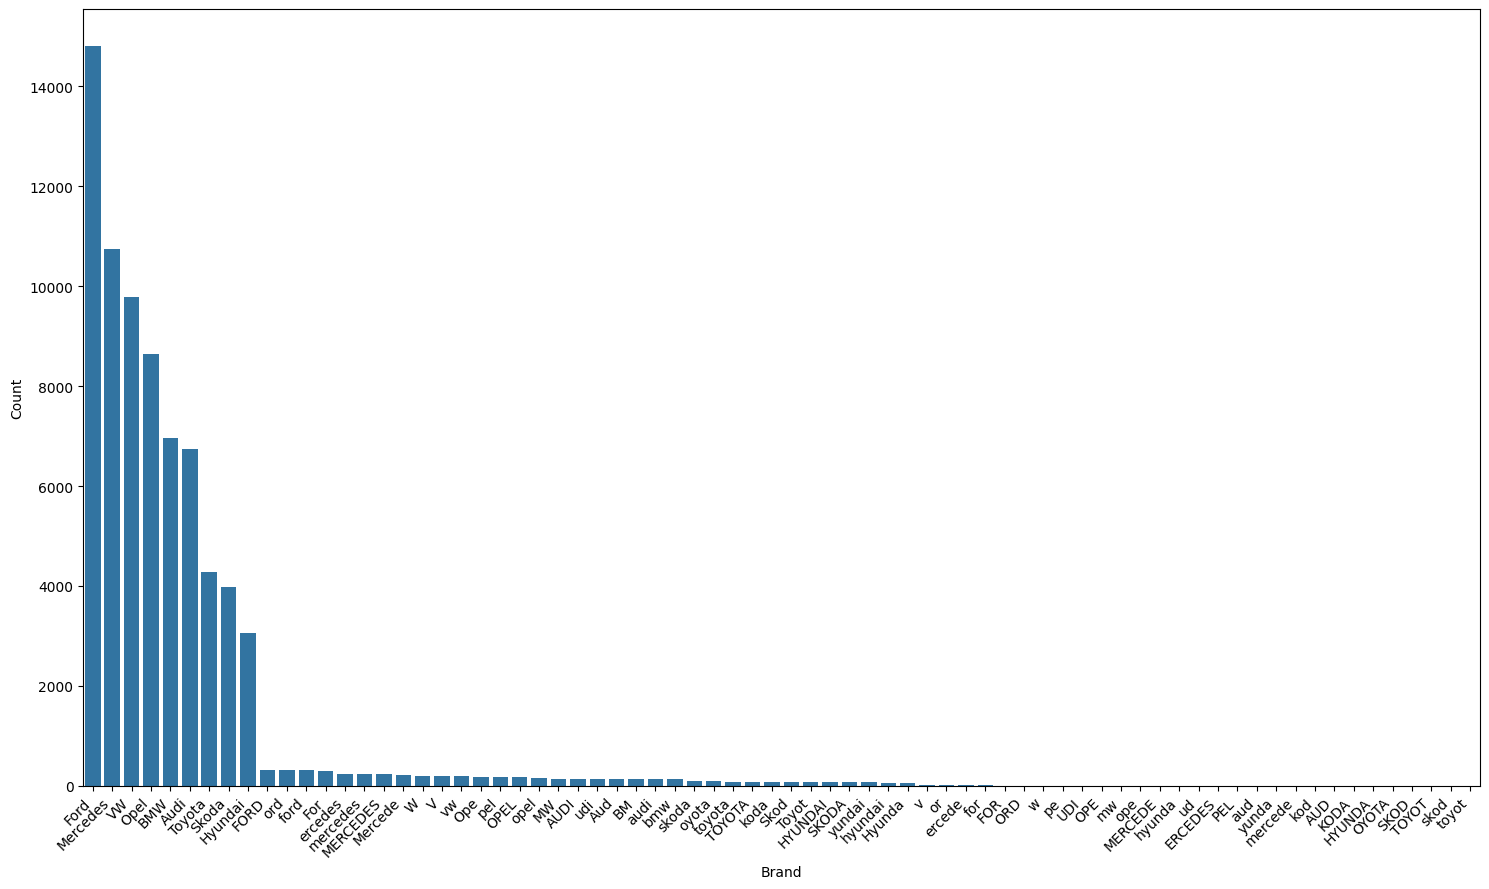

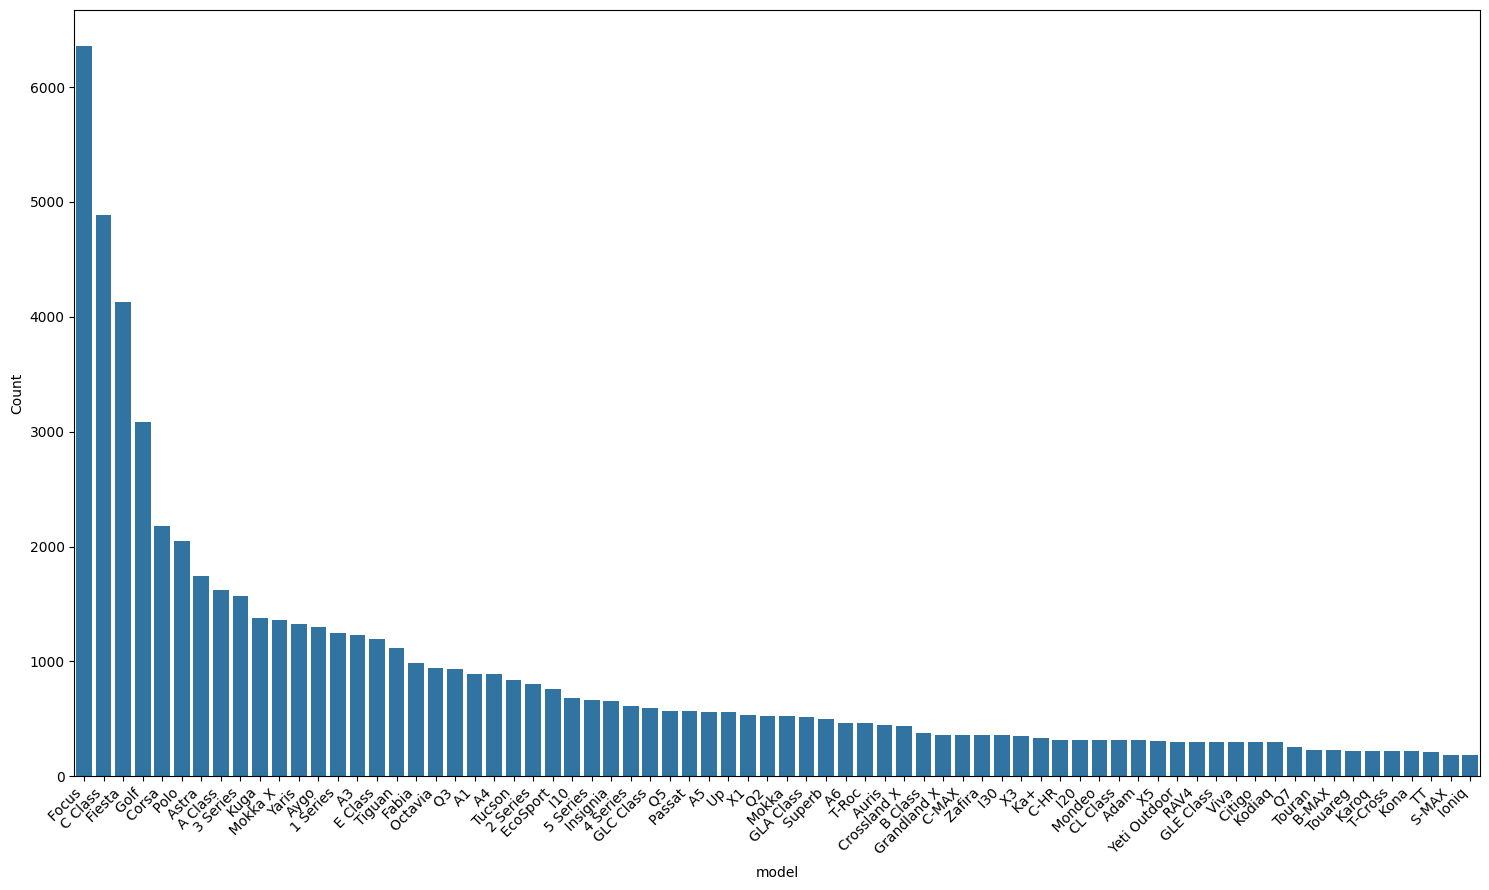

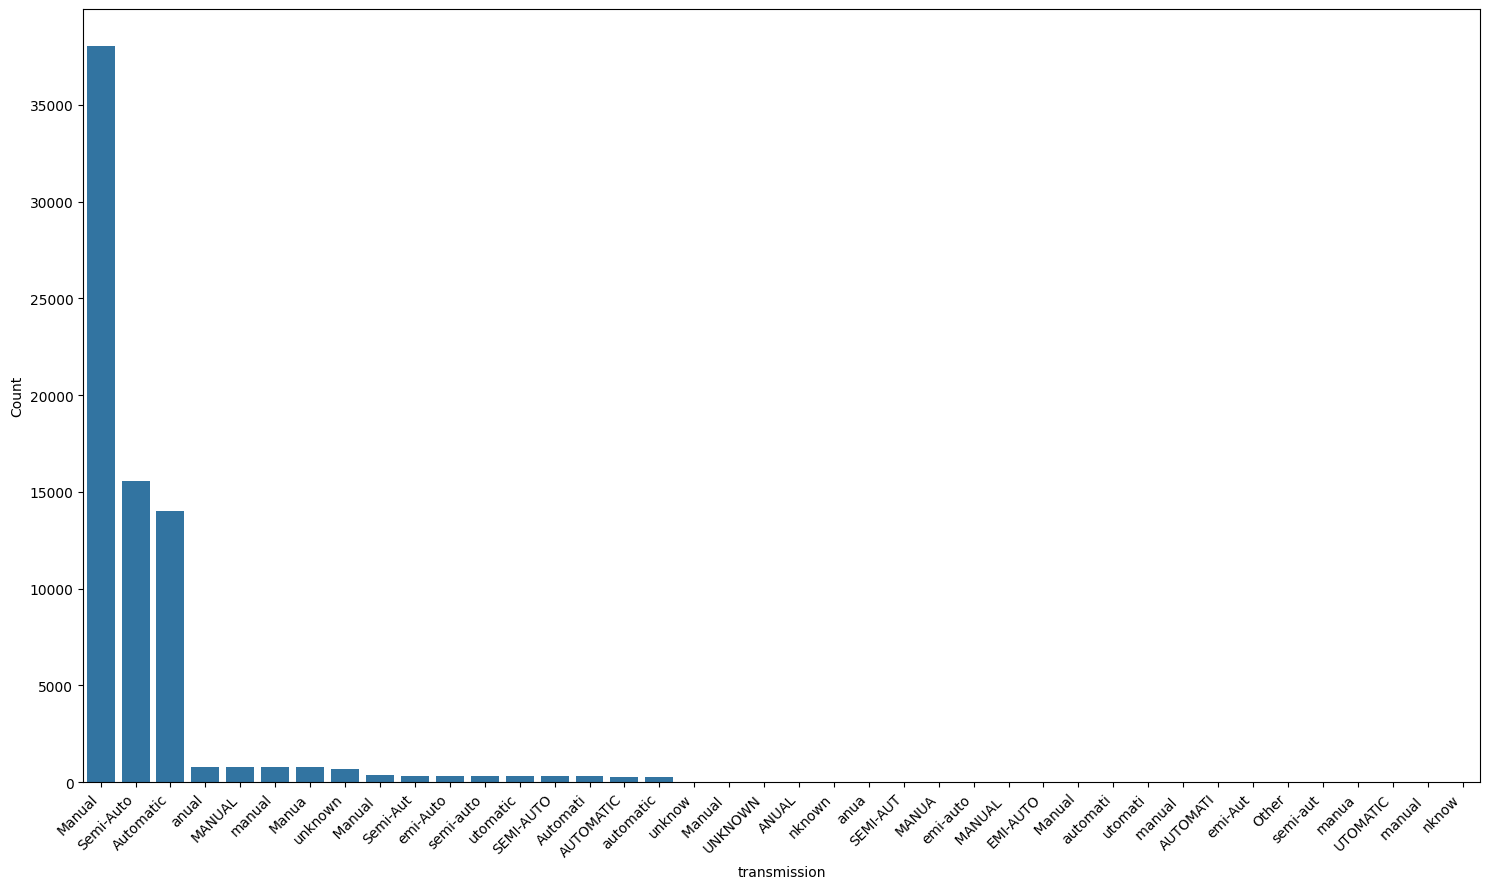

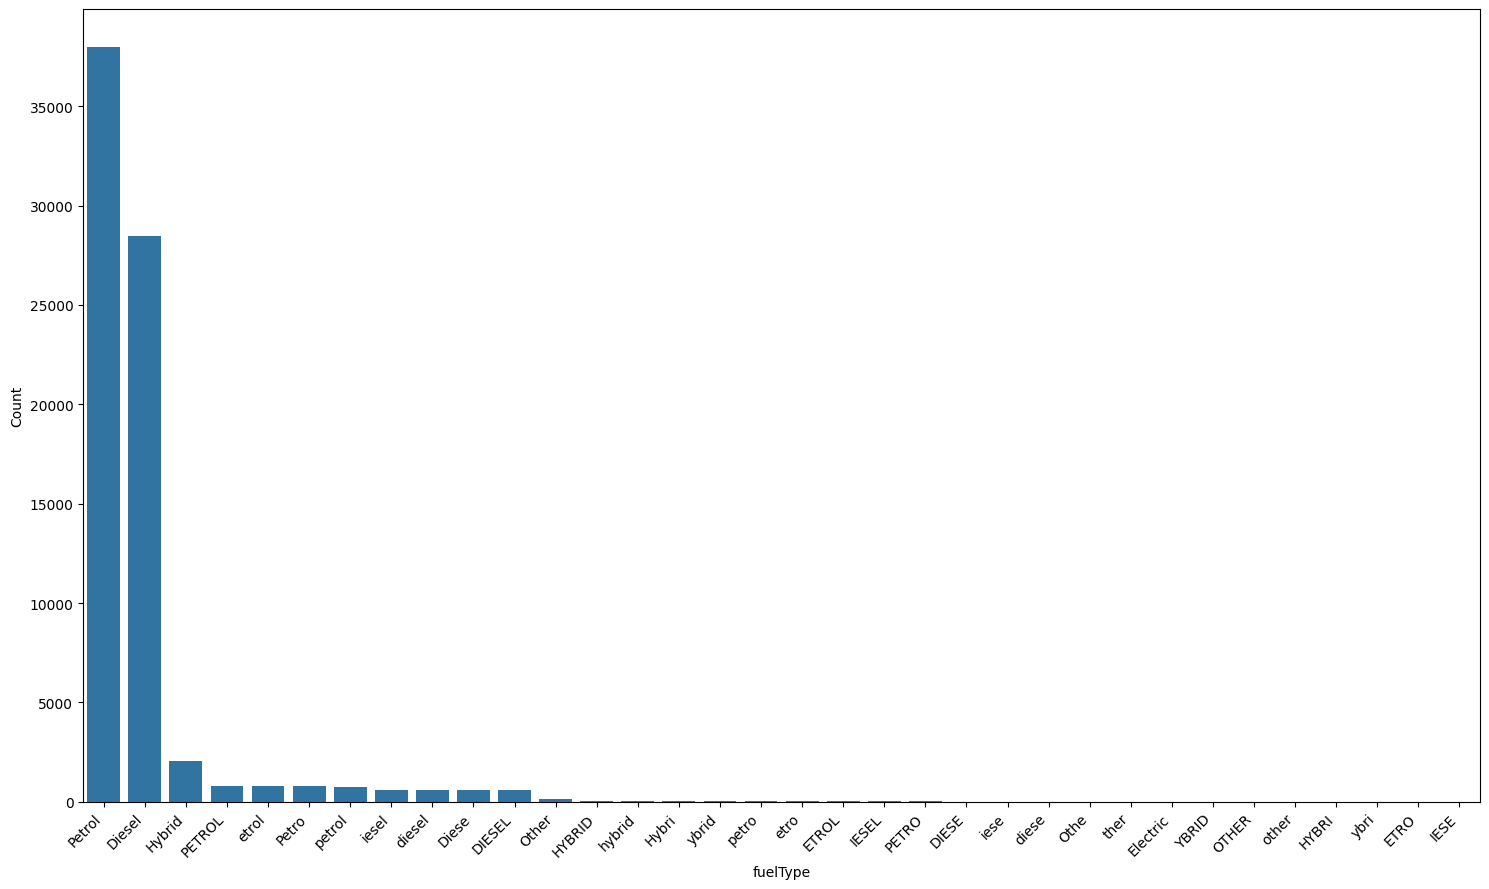

In [13]:
for col in categorical_features:
    top_n = 72
    model_counts = train_df[col].value_counts().nlargest(top_n)

    plt.figure(figsize=(15,9))
    sns.barplot(x=model_counts.index, y=model_counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(f"{col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In terms of distributions we have a lot of different situations. Before log transformation, price, mileage are considerably right-skewed (which highlights the presence of outliers), while mpg is also slighly right-skewed.Tax is left skewed. has_damage is constant with all observations at 0.

c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:3

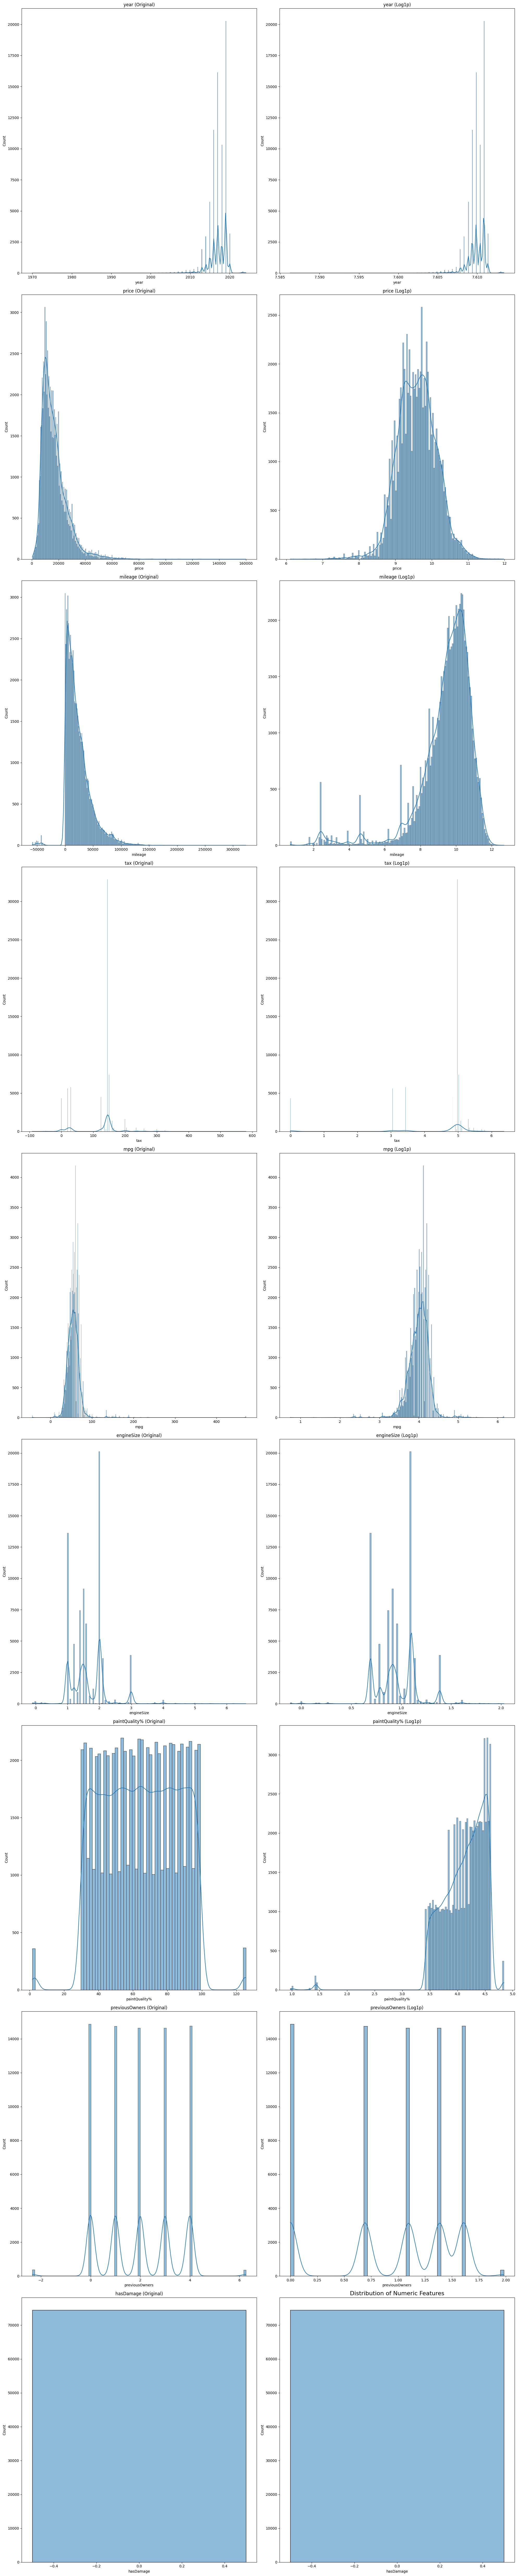

In [14]:
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(20, 11*len(numeric_features)))

for i, col in enumerate(numeric_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (Original)")
    sns.histplot(np.log1p(train_df[col].dropna()), kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} (Log1p)")

plt.title(f'Distribution of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()


### Boxplot

All columns except Paint Quality have outliers.
- Tax, mpg, mileage, previous owners have non-sensical values since some of the values are negative. Same with Engine Size with values equaling 0.
- Paint Quality has values above 100% which is also non-sensical
- Price, mileage, tax and mpg have a large number of outliers
- There are cars with year of Registration after 2020, which it couldn't have since the dataset refers to cars that were in the company's dataset in 2020


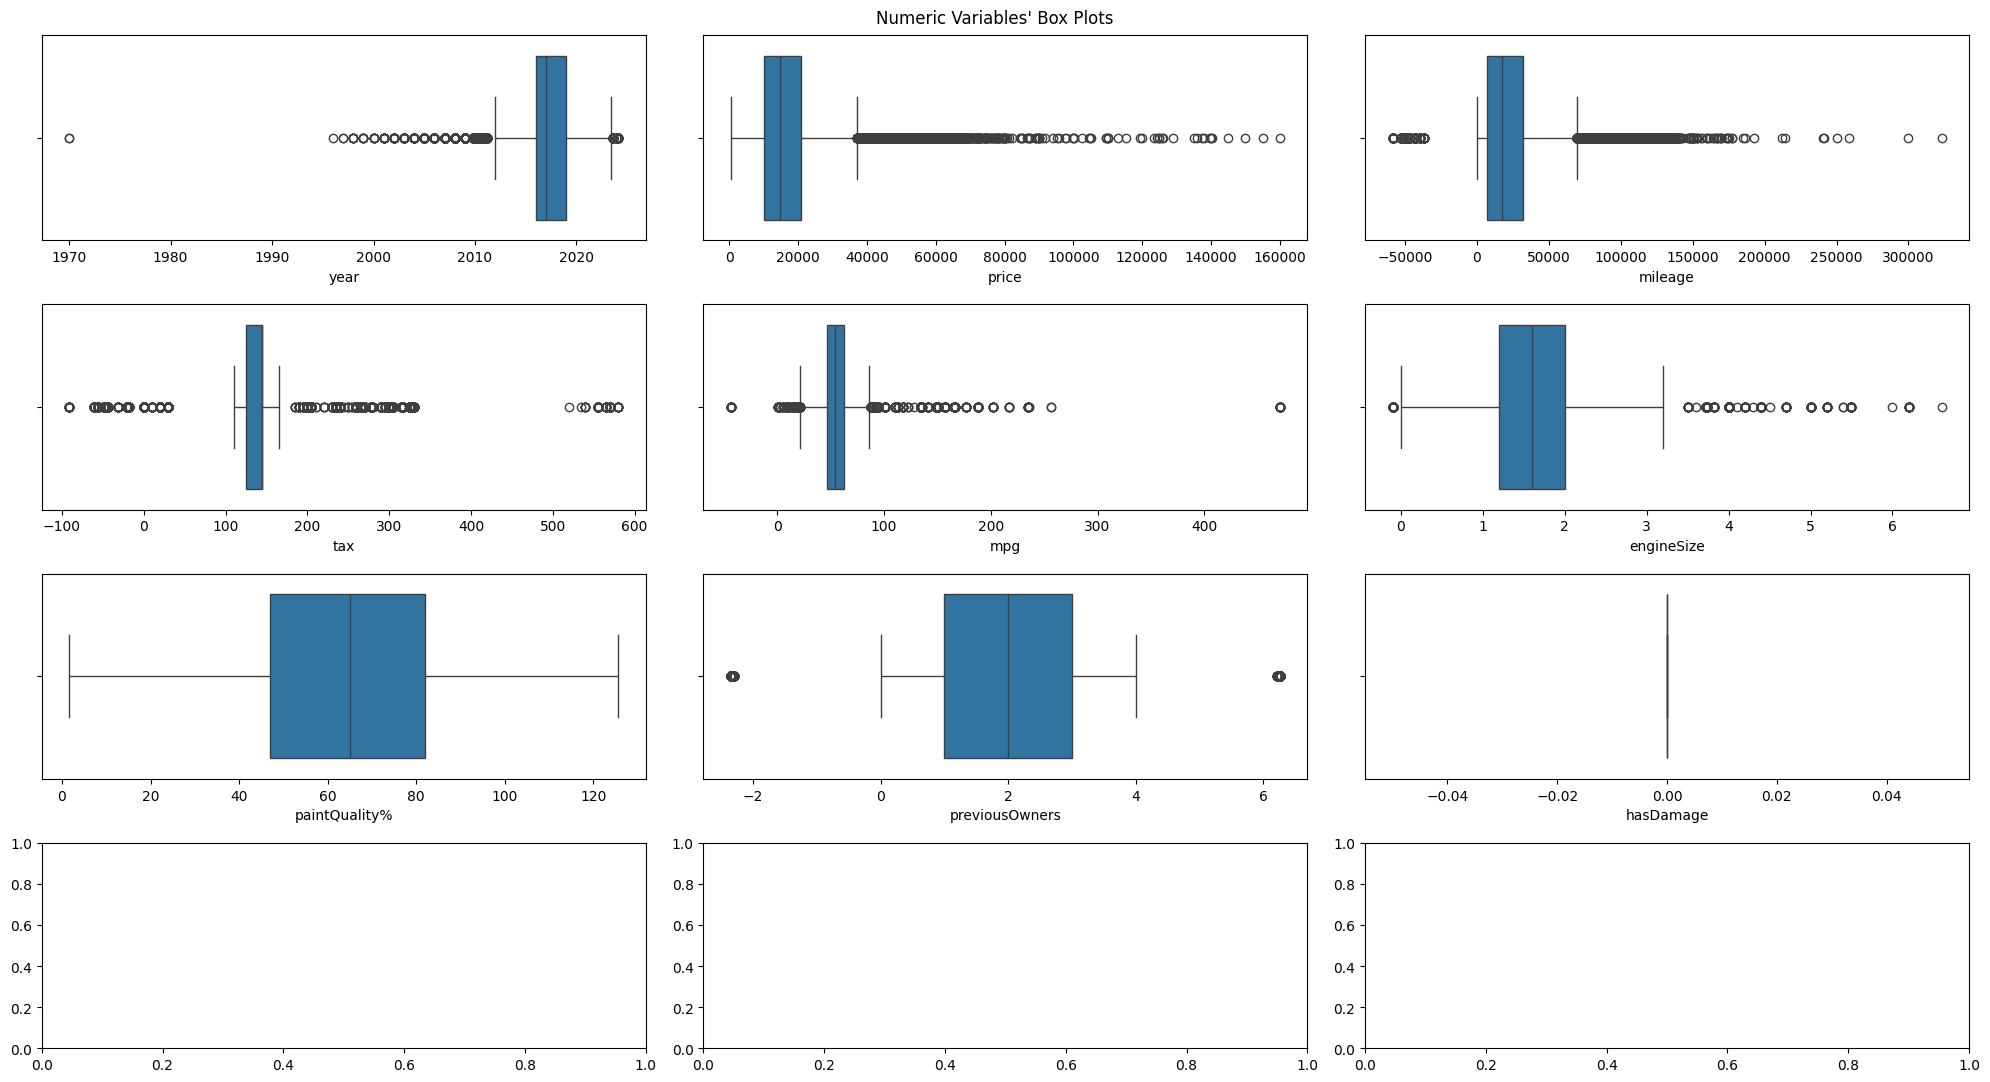

In [15]:
# Define number of subplot rows and columns
sp_rows = 4
sp_cols = ceil(len(numeric_features) / sp_rows)


# Create subplots
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11),
                         tight_layout=True
                        )

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features): # Notice the zip() function and flatten() method
    sns.boxplot(x=train_df[feat], ax=ax)
    
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title)

plt.show()

## Correlation Analysis

There are not any high correlation between features. Mileage and year with -0.67 and price and Engine size with 0.61 are the biggest correlations.

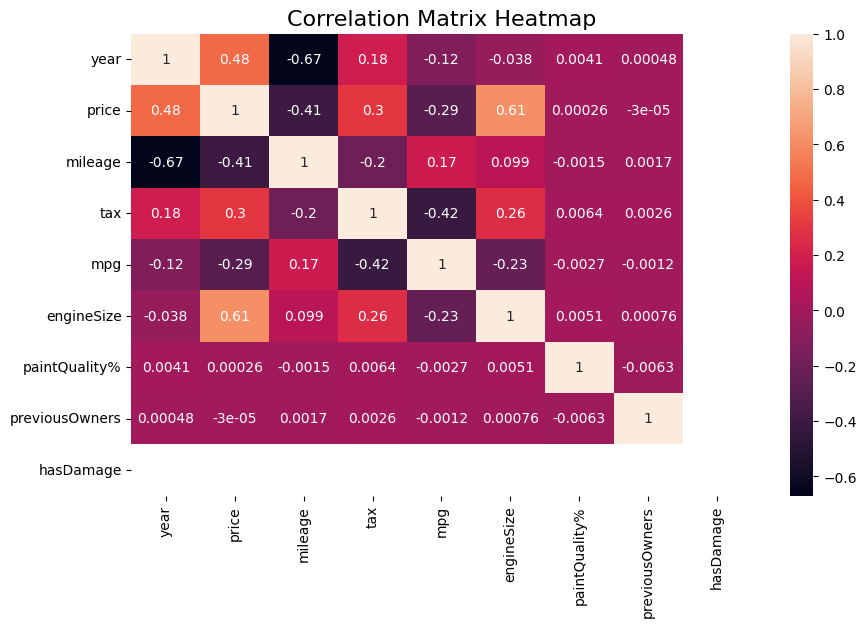

In [16]:
fig = plt.figure(figsize=(10, 6))

# Obtain correlation matrix. 
corr = train_df[numeric_features].corr(method="pearson")

# Plot heatmap of the correlation matrix
sns.heatmap(data=corr, annot=True, )
plt.title(f'Correlation Matrix Heatmap', fontsize=16)

plt.show()

## Multivariate Analysis

Given our categorical (we will exclude models as this features has too many values and too many errors) we will analyze the existence of outliers and the possibility of confirming there are certain characteristics associated with higher or lower prices.
- While considering price vs brand, mercedes and audi have both some of the biggest distributions and also the largest numbers of outliers. Brand like hyundai and skoda are more economical as they have small distributions and their outliers are in some cases cheaper that the higher end some other brands like bmw, audi or mercedes.
- For transmission, we can very that semi-auto and auto have a great number of outliers
- For fuelType, both petrol and diesel have a considerable number of outliers but petrol has a larger quantity and a much more spread set of outliers

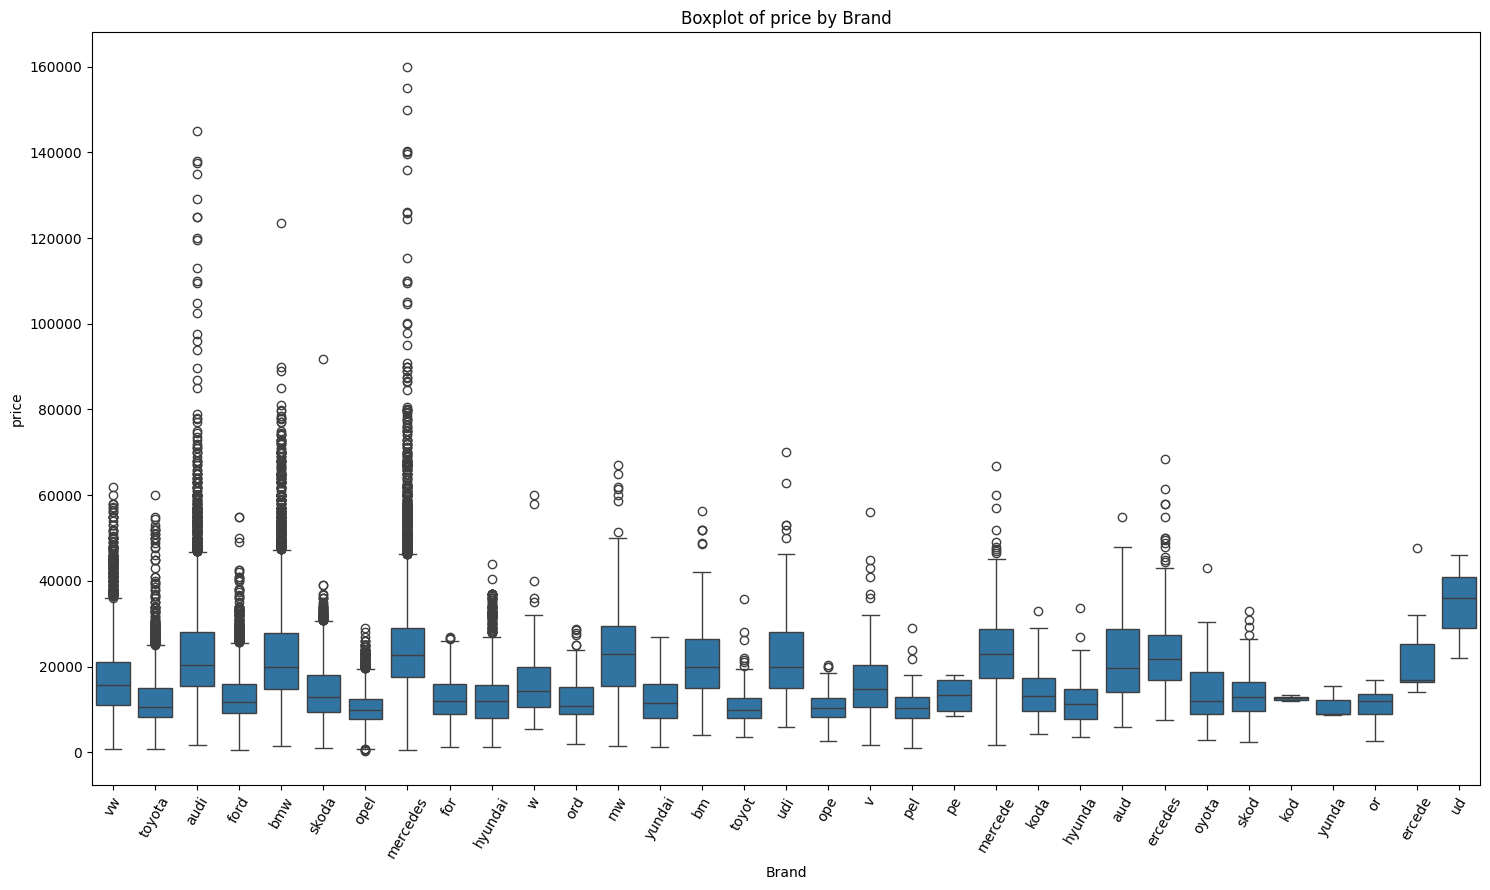

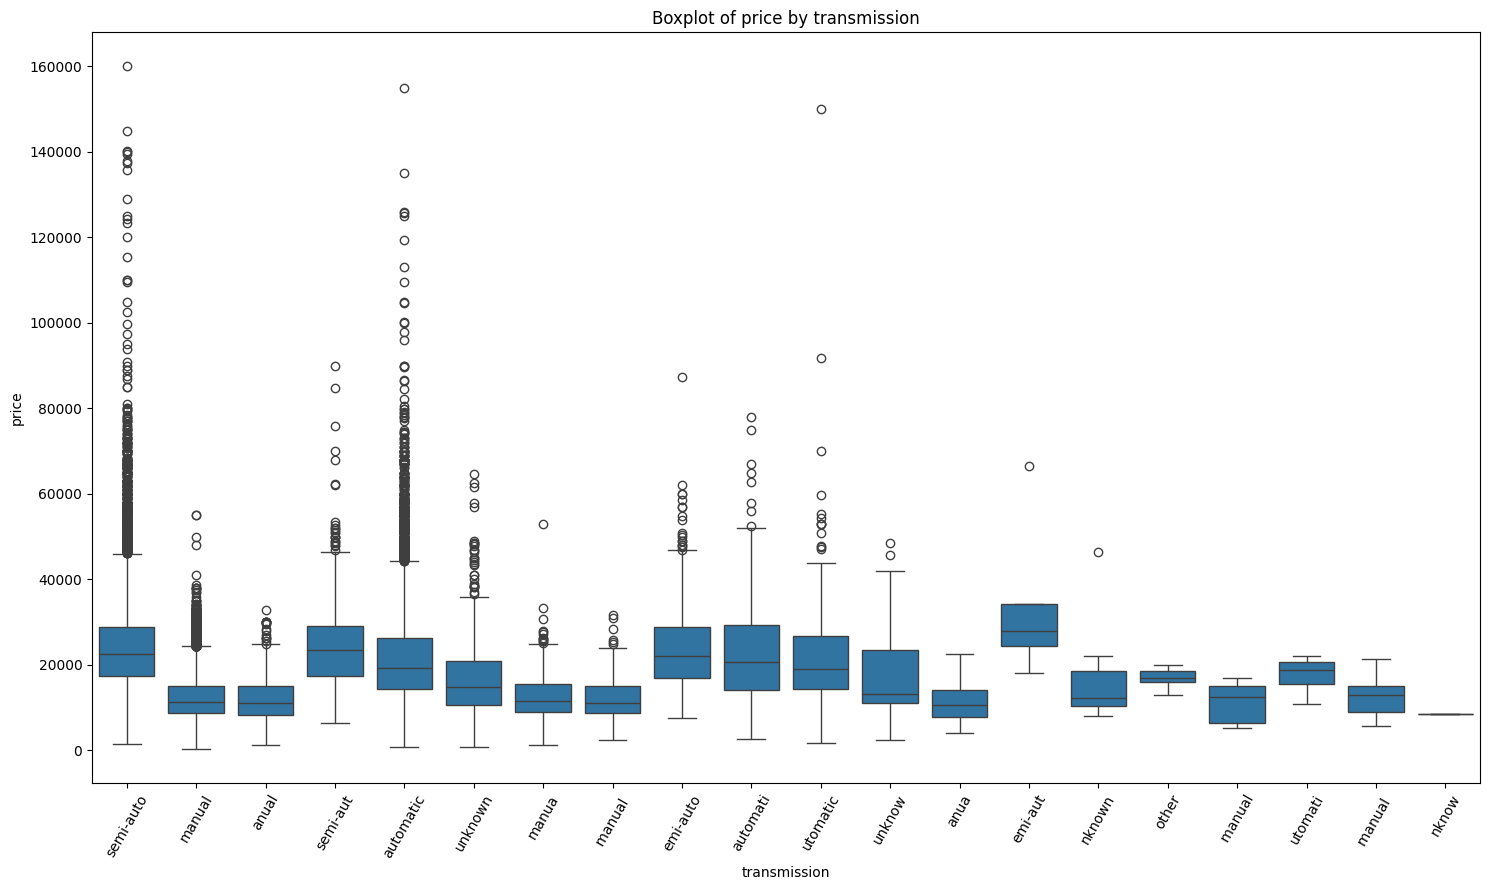

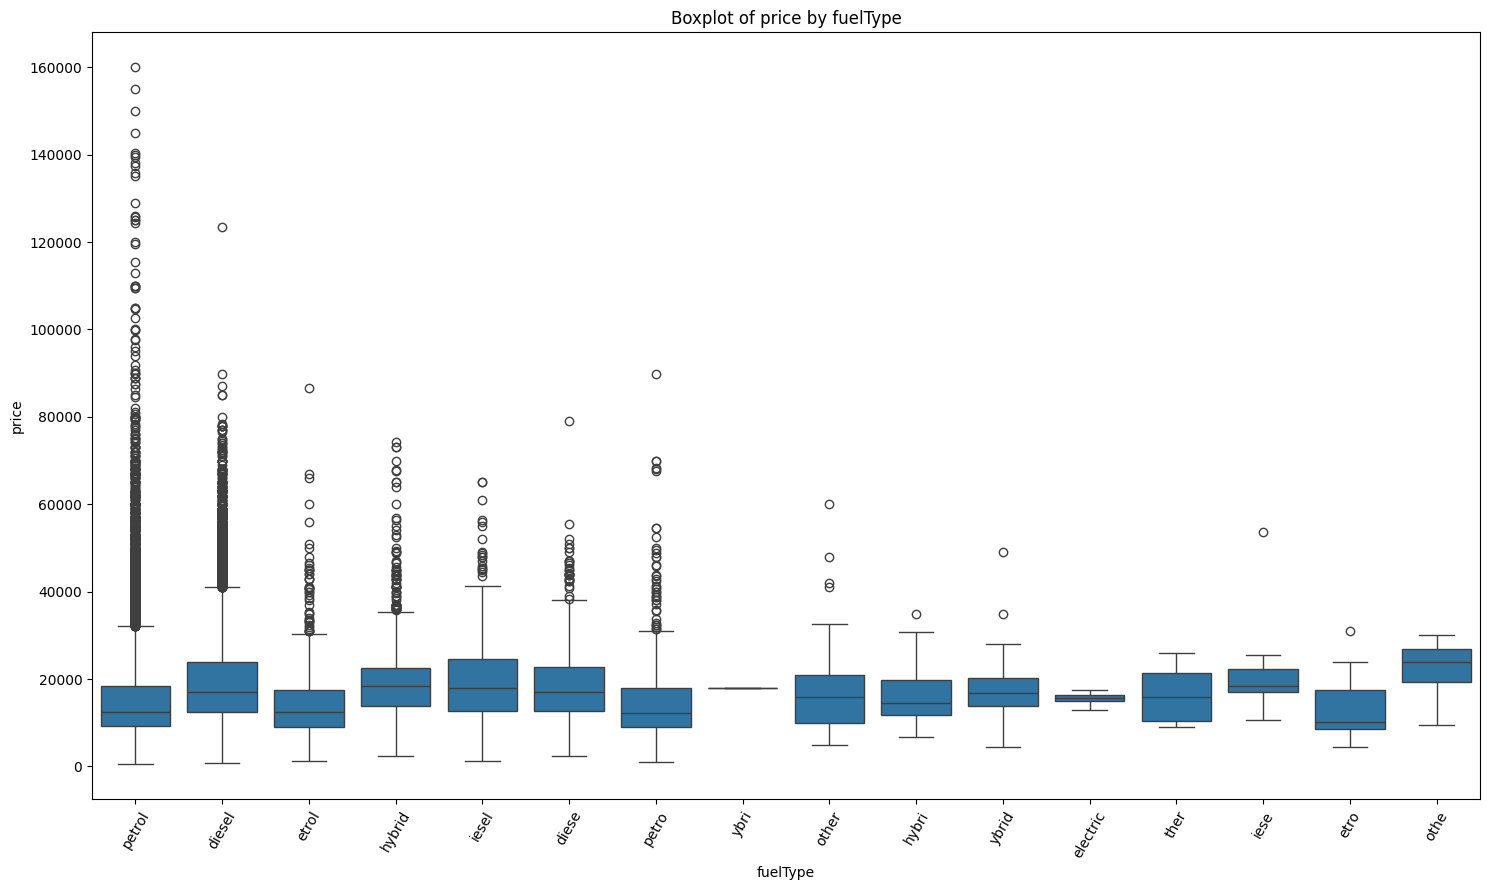

In [17]:
for col in ['Brand', 'transmission', 'fuelType']:
    plt.figure(figsize=(15,9))
    sns.boxplot(data=train_df, x=train_df[col].str.lower(), y='price')
    plt.title(f'Boxplot of price by {col}')
    plt.xticks(rotation=60)
    plt.tight_layout()

With this visualization we intend to verify how our numerical features compare to our target and if there are any visible tendencies when comparing features.
- There is a noticeable trend for models to be pricier if they are newer but these trend seems to only be valid until 2020
- Another trend is for mileage to have an inverse relation to price as a smaller mileage equates to a higher price
- There is a slight trend for bigger engines to be associated with more expensive cars
 

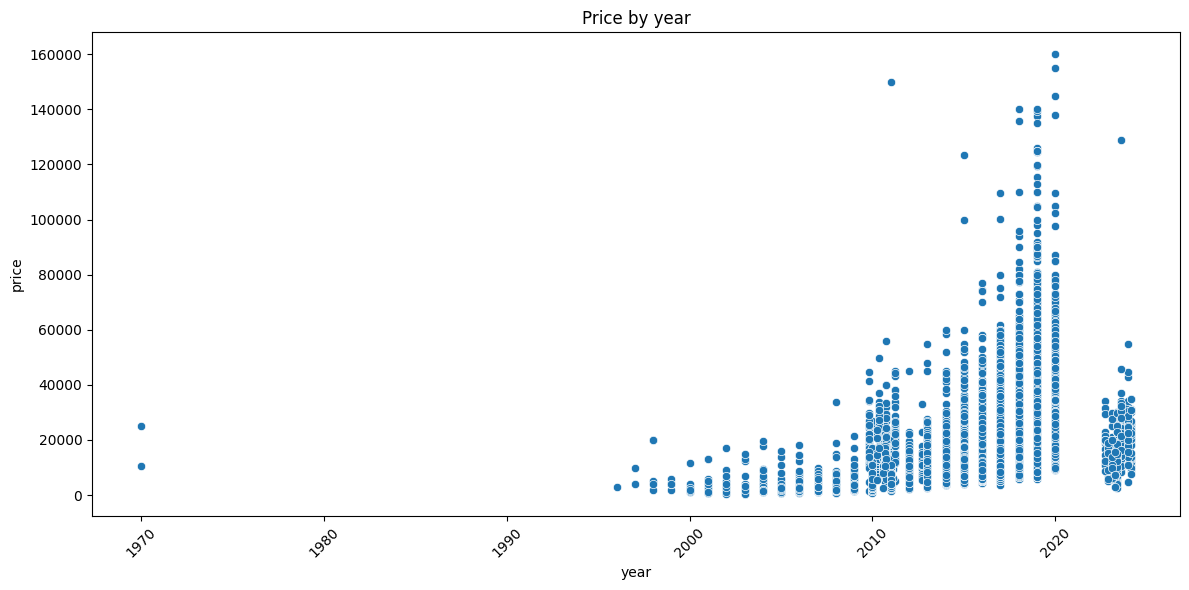

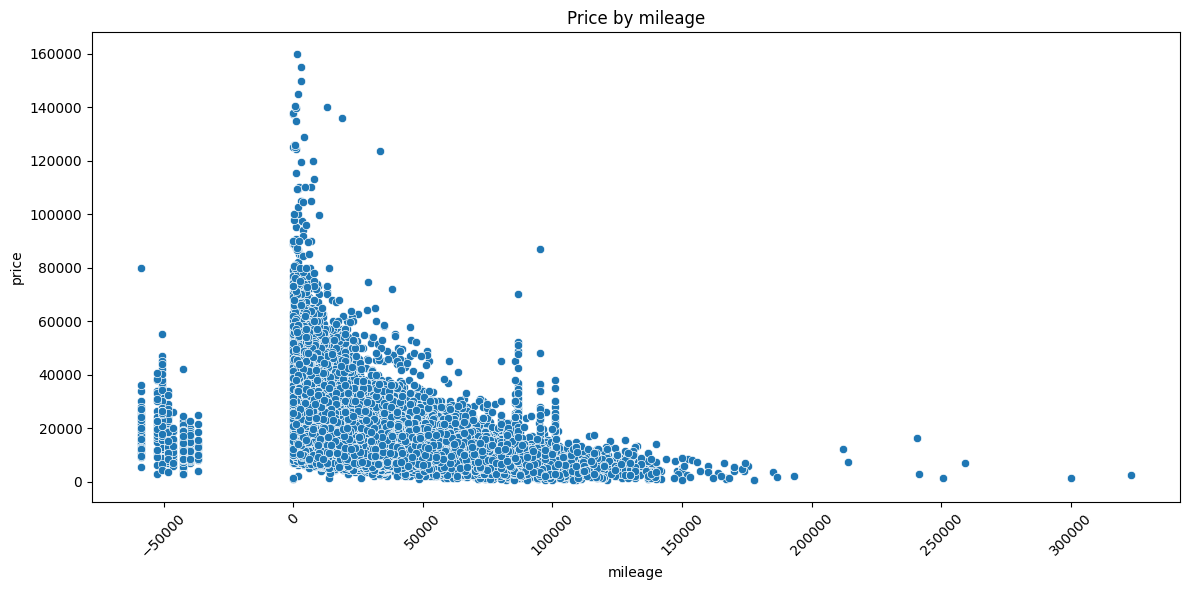

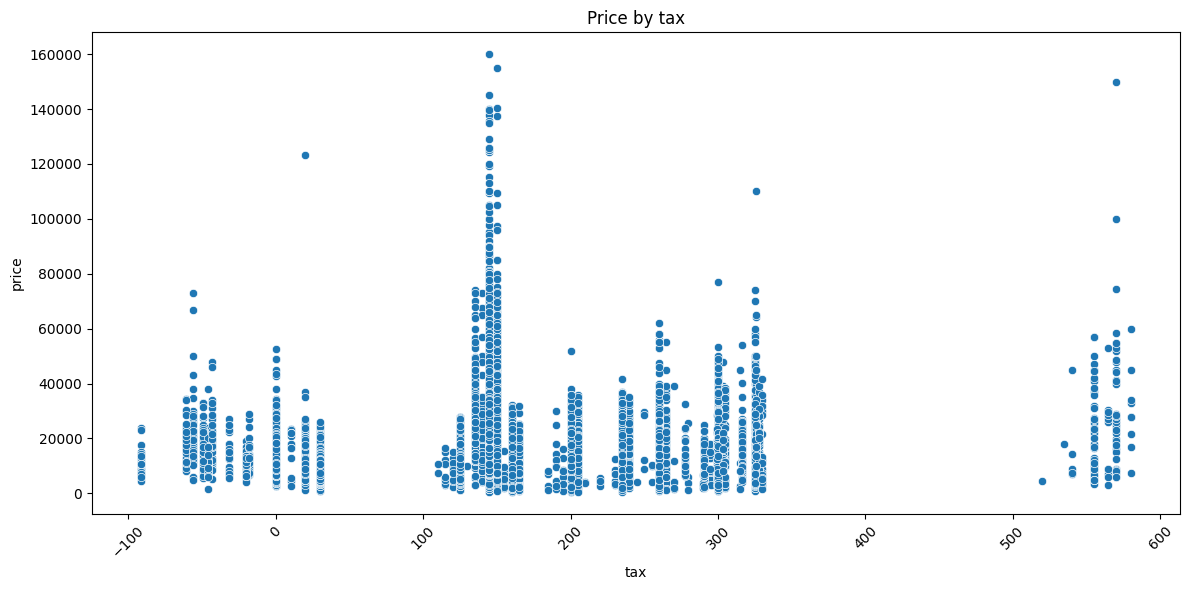

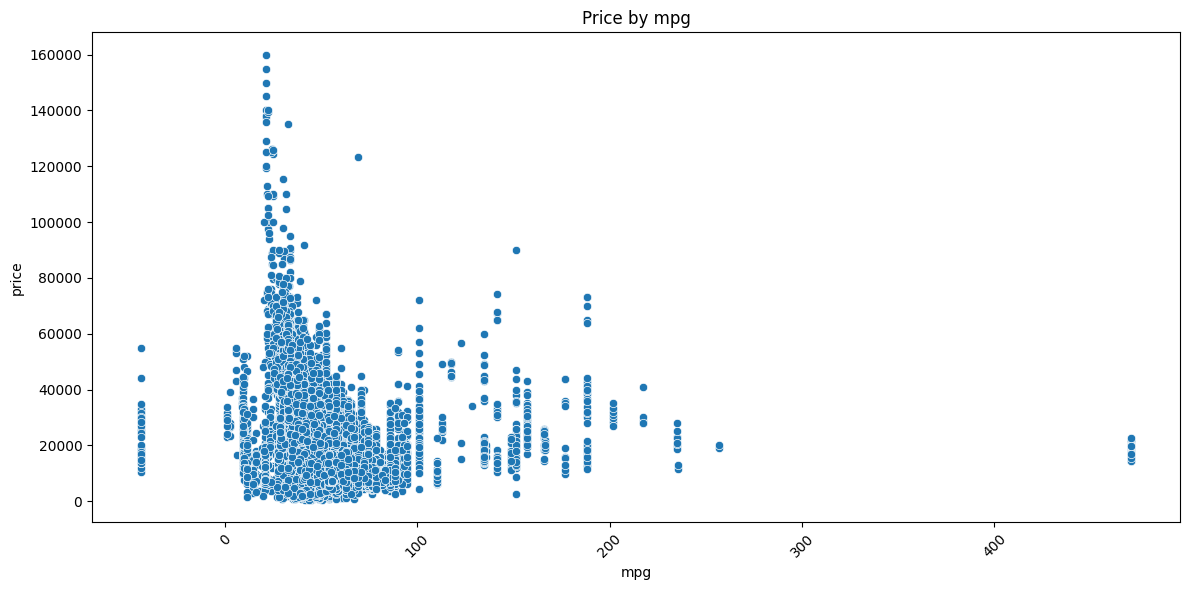

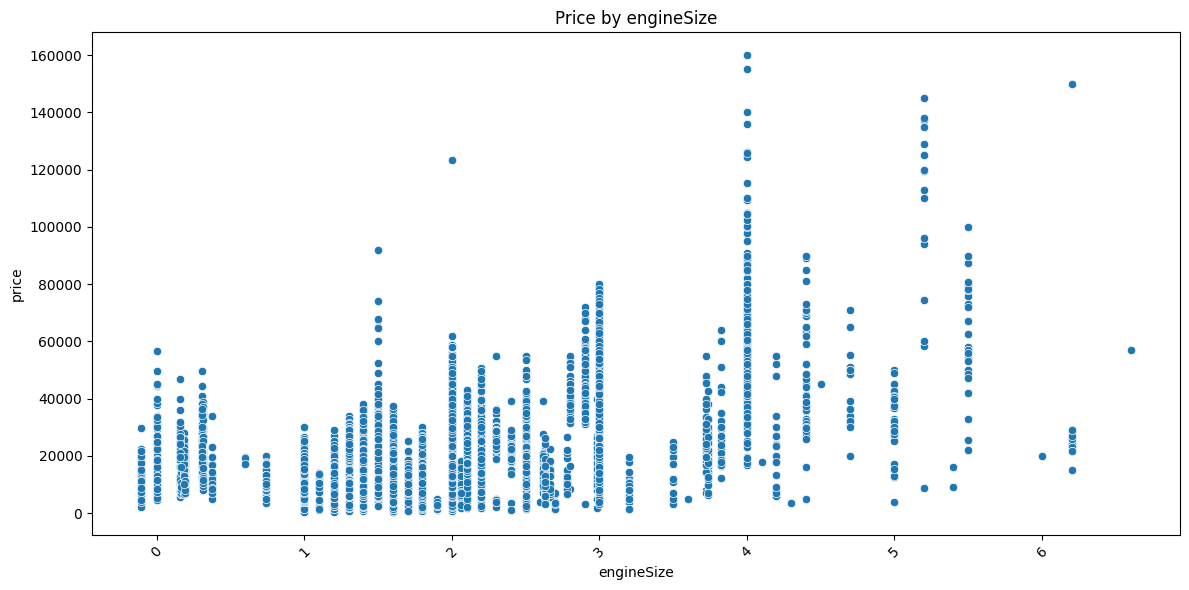

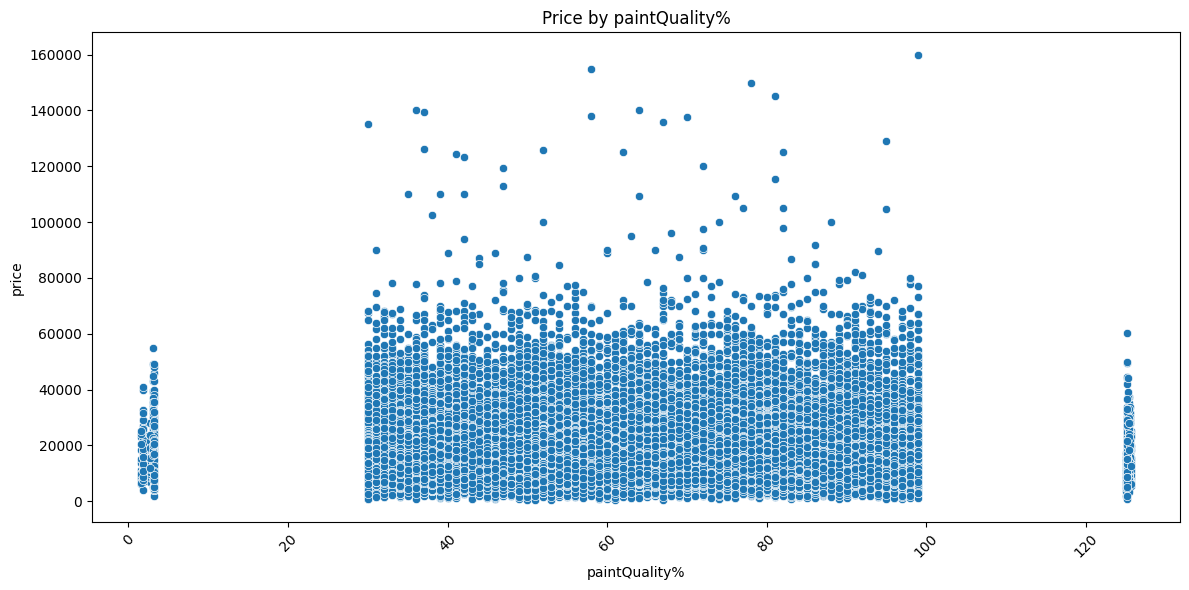

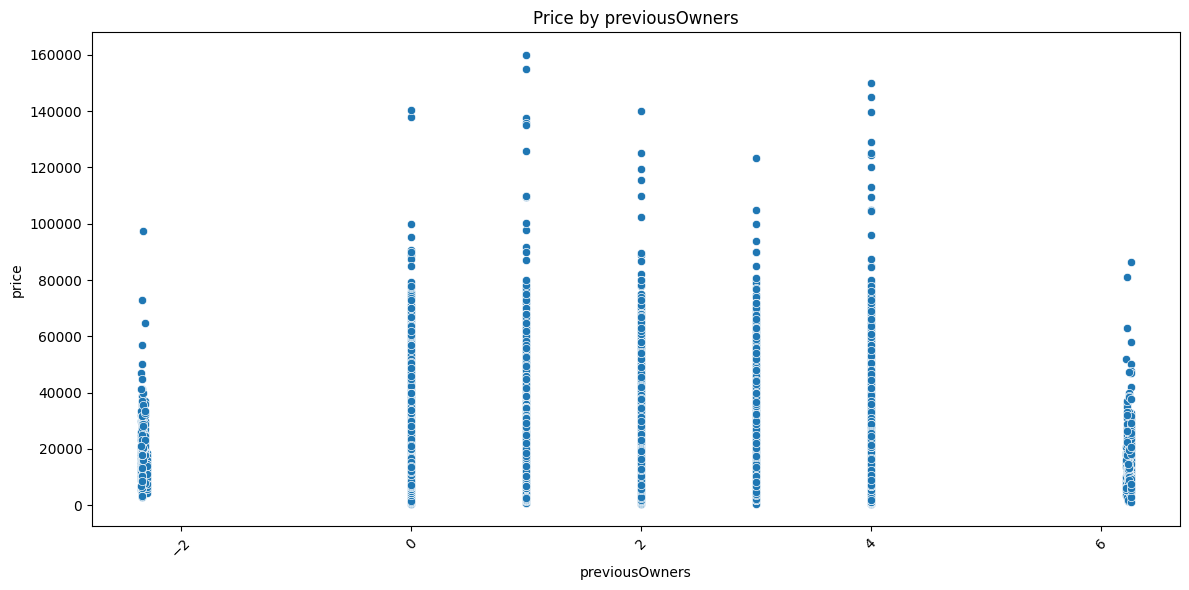

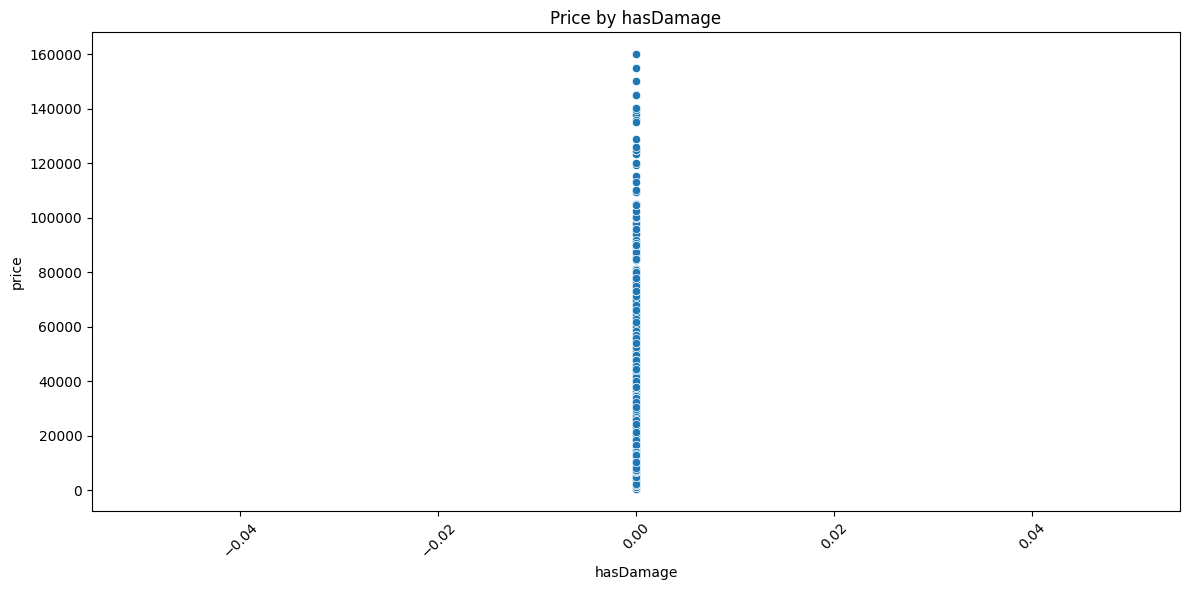

In [18]:
for col in [c for c in numeric_features if c != 'price']:
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=train_df, x=col, y='price')
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

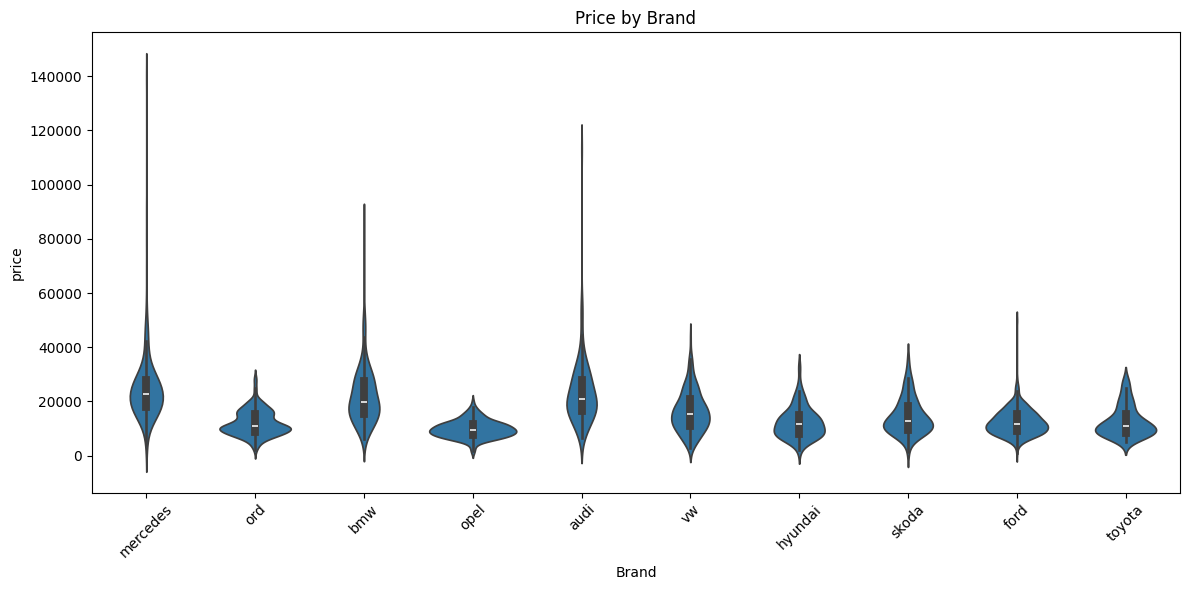

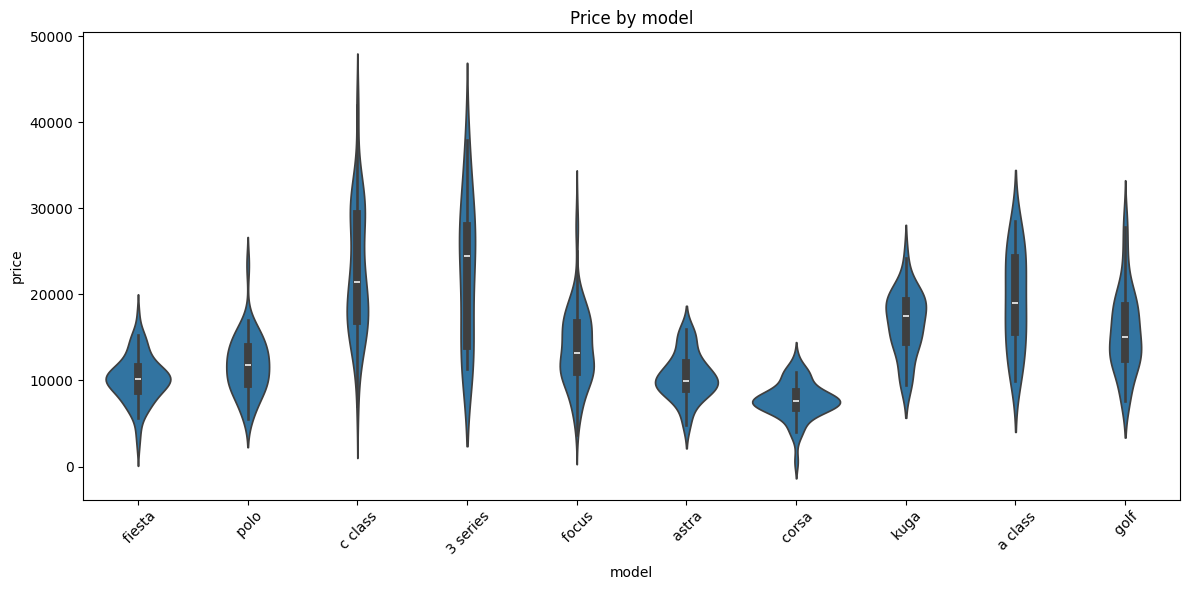

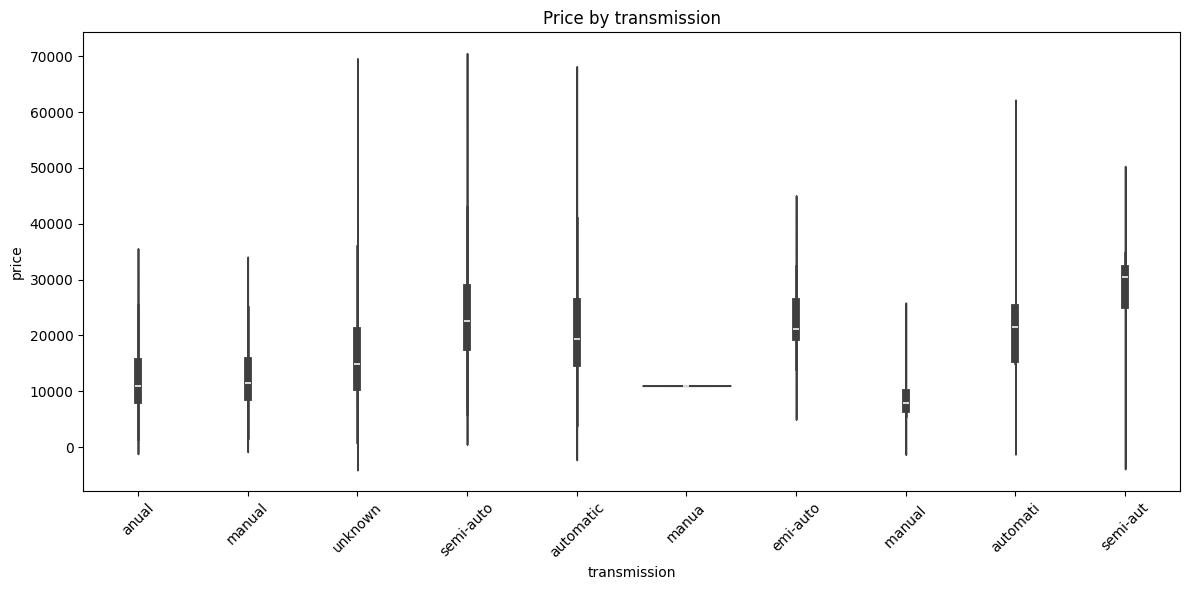

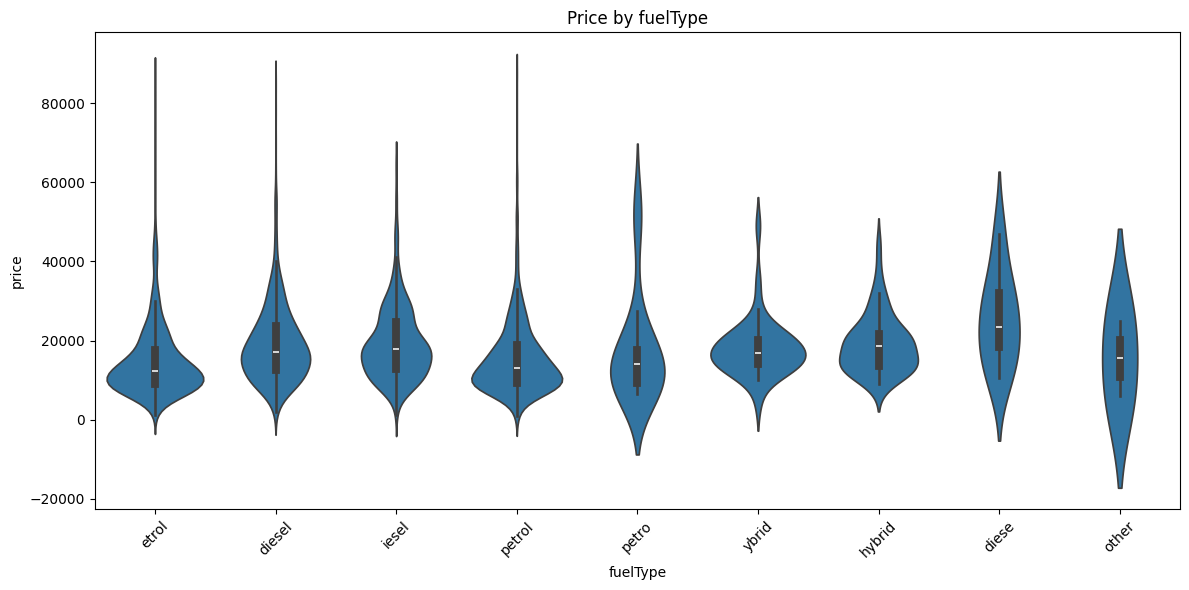

In [19]:
for col in categorical_features:
    top_values = train_df[train_df[col].isin(train_df[col].str.lower().value_counts().head(10).index)]
    plt.figure(figsize=(12,6))
    sns.violinplot(data=top_values, x=top_values[col].str.lower(), y='price')
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

When comparing fuel type to mpg, there is a clear difference as hybrid models have considerable more mpg. When comparing transmission to mpg, these are mostly balanced with semi-auto having slightly less mpg

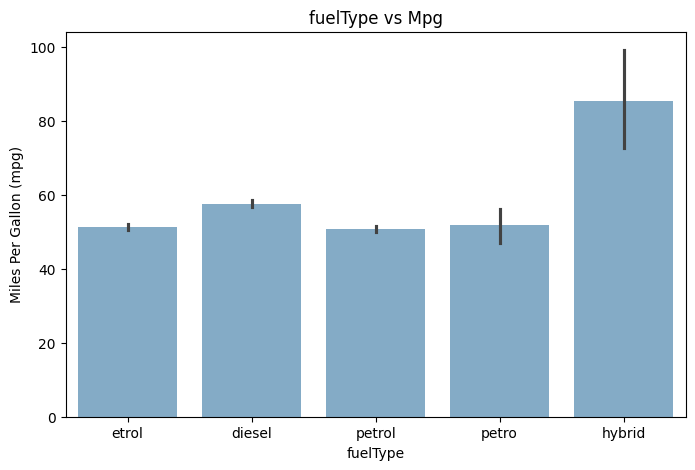

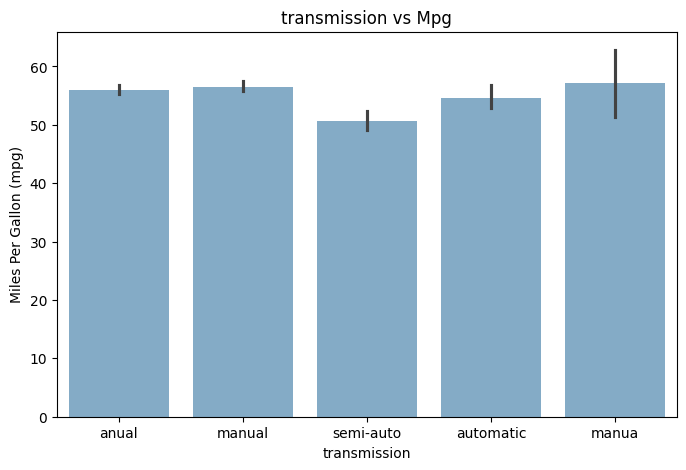

In [20]:
for col in ['fuelType', 'transmission']:
    top_values = train_df[train_df[col].isin(train_df[col].str.lower().value_counts().head(5).index)]

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=top_values, 
        x=col, 
        y='mpg',
        alpha=0.6
    )
    plt.title(f'{col} vs Mpg')
    plt.xlabel(f'{col}')
    plt.ylabel('Miles Per Gallon (mpg)')
    plt.show()

Engine Size vs Mpg: Most of the distribution points are between 0 and slightly above 100 mpg. The mpg output is higher for cars between 1 and 3 liters of Engine Size. There are a few very extreme outliers above 400 mpg.
Paint Quality vs Number of owners: There isn't a verifiable trend.

In [21]:
def scatter_pairs(df, pairs, alpha=0.6):
    """
    df    : DataFrame with your data (e.g. train_df)
    pairs : list of (x_col, y_col, title, x_label, y_label)
    """
    for x_col, y_col, title, xlab, ylab in pairs:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            alpha=alpha
        )
        plt.title(title)
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.show()


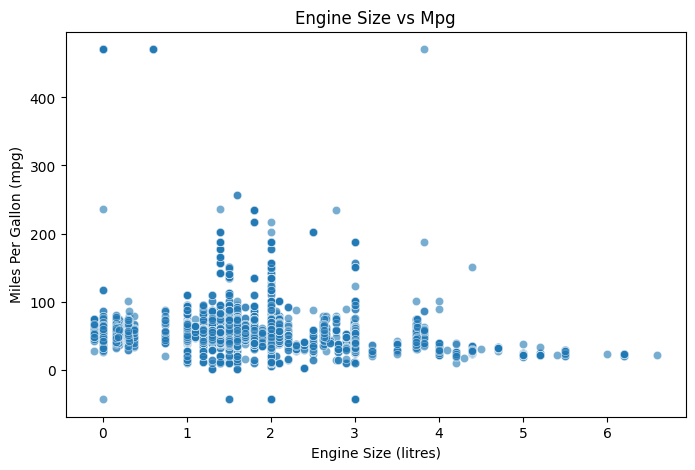

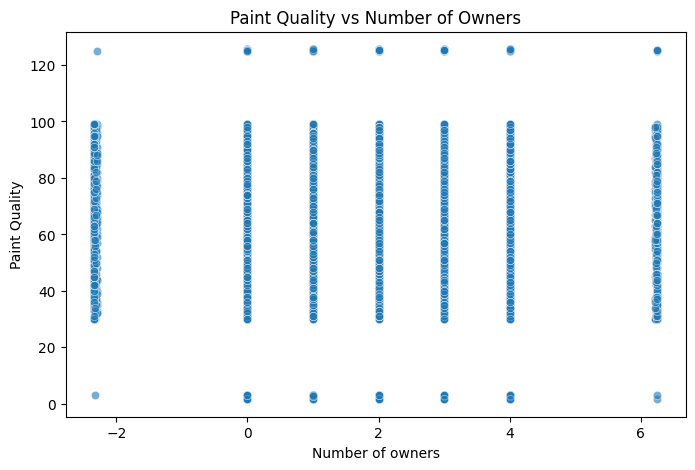

In [22]:
scatter_variables = [
    ("engineSize",     "mpg",
     "Engine Size vs Mpg", "Engine Size (litres)", "Miles Per Gallon (mpg)"),

    ("previousOwners", "paintQuality%",
     "Paint Quality vs Number of Owners", "Number of owners", "Paint Quality"),
]

scatter_pairs(train_df, scatter_variables)

In-depth exploration

In [23]:
train_df['Brand'].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [24]:
train_df['model'].value_counts()

model
 Focus        6353
 C Class      4886
 Fiesta       4130
 Golf         3081
 Corsa        2182
              ... 
M5               1
 gls class       1
Mokka            1
 6 Serie         1
 JETTA           1
Name: count, Length: 735, dtype: int64

In [25]:
train_df['engineSize'].value_counts()

engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 4.000000      295
 2.200000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.186425       52
 0.739534       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 3.739235       38
 5.000000       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 2.781776       19
 3.200000       19
 6.200000       19
 4.700000       18
 0.371127       18
 2.663113       17
 5.200000       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400000        2
 6.600000        1
 

In [26]:
train_df['transmission'].value_counts()

transmission
Manual       38050
Semi-Auto    15545
Automatic    14003
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Semi-Aut       332
emi-Auto       325
semi-auto      324
utomatic       313
SEMI-AUTO      309
Automati       304
AUTOMATIC      289
automatic      282
unknow          18
Manual          16
UNKNOWN         14
ANUAL           13
nknown          13
anua            12
SEMI-AUT        11
MANUA           11
emi-auto        10
 MANUAL          9
EMI-AUTO         7
 Manual          7
automati         6
utomati          6
 manual          6
AUTOMATI         6
emi-Aut          5
Other            5
semi-aut         4
manua            2
UTOMATIC         2
manual           1
nknow            1
Name: count, dtype: int64

In [27]:
train_df['fuelType'].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

In [28]:
train_df['previousOwners'].value_counts()

previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64

In [29]:
train_df.query('engineSize == 0.0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
21935,Ford,KA,2018.0,8444,Manual,17000.0,Petrol,145.0,57.7,0.0,51.0,0.0,0.0
9518,BMW,2 Series,2015.0,14700,Automatic,32882.0,Diesel,125.0,60.1,0.0,55.0,0.0,0.0
32528,Hyundai,Tucson,2016.0,13800,Manual,27311.0,Diesel,30.0,61.7,0.0,73.0,1.0,0.0
33804,Hyundai,Tucson,2019.0,15000,Manual,22397.0,Petrol,150.0,34.9,0.0,54.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26630,Ford,Fiesta,2018.0,11463,NaN,18000.0,Petro,145.0,65.7,0.0,82.0,0.0,0.0
20128,Ford,Focus,2018.0,18389,Manual,19000.0,Petrol,NaN,NaN,0.0,48.0,2.0,0.0
47605,Skoda,Fabia,2018.0,11500,Manual,10720.0,Petrol,150.0,64.2,0.0,84.0,4.0,0.0


In [30]:
train_df.query('engineSize == 0').groupby(['Brand', 'model'])['engineSize'].count()

Brand   model 
Audi    A1        1
        A3        3
        A4        1
        A5        1
        Q2        3
                 ..
VW      T-Roc     2
        Tiguan    2
bmw     i3        2
hyunda  I10       1
ord     Mondeo    1
Name: engineSize, Length: 62, dtype: int64

In [31]:
train_df.query('engineSize >= 6')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
38980,Mercedes,C Class,2013.0,23000,Semi-Auto,43442.000000,Petrol,NaN,NaN,6.2,76.0,0.0,0.0
46372,Mercedes,C Class,2013.0,22995,Semi-Auto,49964.000000,Petrol,NaN,23.0,6.2,78.0,3.0,0.0
9197,BMW,7 Series,2017.0,57000,Automatic,11297.000000,Petrol,145.000000,22.1,6.6,68.0,1.0,0.0
42286,Mercedes,C Class,2014.0,26998,Semi-Auto,24175.000000,Petrol,NaN,NaN,6.2,93.0,2.0,0.0
39900,Mercedes,C Class,2014.0,28990,Semi-Auto,19562.000000,Petrol,-56.193202,NaN,6.2,83.0,0.0,0.0
39852,ercedes,S Class,2010.0,26990,Automatic,38000.000000,Petrol,570.000000,19.5,6.2,76.0,4.0,0.0
35612,Mercedes,C Class,2013.0,23990,Automatic,NaN,Petrol,570.000000,23.5,6.2,44.0,2.0,0.0
36196,Mercedes,C Clas,2014.0,25885,Semi-Auto,86705.854885,Petrol,NaN,NaN,6.2,31.0,0.0,0.0
35538,NaN,C Class,NaN,22995,Semi-Auto,49964.000000,Petrol,326.028233,NaN,6.2,58.0,3.0,0.0


In [32]:
train_df.query('year < 2010')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35220,Mercedes,SLK,2003.000000,3650,Automatic,58500.0,Petrol,325.0,30.0,2.3,45.0,4.0,0.0
56599,Opel,Astra,2009.000000,1950,Automatic,112000.0,Petrol,305.0,36.2,1.8,71.0,2.0,0.0
34317,Hyundai,Getz,2007.000000,1995,unknown,57000.0,Petrol,125.0,51.4,1.1,45.0,4.0,NaN
44251,Mercedes,C Class,2005.000000,2495,Automatic,110461.0,Diesel,NaN,NaN,2.1,57.0,1.0,0.0
56163,Opel,Corsa,2004.000000,2444,Manual,NaN,Petrol,NaN,53.3,1.0,69.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12161,BMW,2 Series,2009.816757,13700,Automatic,52541.0,Diesel,125.0,57.6,2.0,46.0,0.0,0.0
1150,Audi,RS4,2006.000000,17999,anual,66000.0,Petrol,535.0,20.3,4.2,84.0,1.0,0.0
18141,Ford,C-MAX,2008.000000,1999,Manual,97000.0,Petrol,235.0,39.8,1.8,98.0,4.0,0.0


In [33]:
train_df.query('mileage <= 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,Tiguan,2020.0,25000,Manual,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,C Class,2019.0,25780,Semi-Auto,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,Golf,2018.0,14995,Manual,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3 Series,2019.0,23498,Semi-Auto,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,2017.0,8895,Manual,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,NaN,2018.0,8514,Manual,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLE Class,2020.0,54995,Automatic,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,2015.0,17900,Automati,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


In [34]:
train_df.query('mileage > 50000')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
14704,BMW,3 Series,2014.0,8199,anual,101153.348285,Diesel,30.0,65.7,2.0,74.0,0.0,0.0
50783,Skoda,Octavia,2017.0,7500,Manual,116750.000000,Diesel,145.0,68.9,1.6,59.0,4.0,0.0
34015,Hyundai,I30,2016.0,7500,manual,51236.000000,Diesel,20.0,72.4,1.6,94.0,4.0,0.0
68197,w,Golf,2013.0,12299,Automatic,64739.000000,Petrol,160.0,44.1,2.0,47.0,4.0,0.0
55065,Toyota,C-HR,2017.0,15490,Automatic,59000.000000,Hybrid,0.0,74.3,1.8,95.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45758,Mercedes,CL Class,2015.0,17491,Semi-Auto,54943.000000,Diesel,20.0,62.8,2.1,74.0,3.0,0.0
66803,VW,Polo,2017.0,9895,Manual,50899.000000,Petrol,150.0,60.1,1.2,65.0,3.0,0.0
35773,Mercedes,C Class,2015.0,13790,NaN,54000.000000,Petrol,125.0,52.3,2.0,48.0,1.0,0.0


In [35]:
train_df.query('tax == 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
55065,Toyota,C-HR,2017.0,15490,Automatic,59000.0,Hybrid,0.0,74.3,1.8,95.0,2.0,0.0
64396,Opel,Astra,2015.0,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
54783,Toyota,Yaris,2014.0,10490,Automatic,34528.0,Hybrid,0.0,80.7,1.5,79.0,1.0,0.0
47148,Skoda,Rapid,2016.0,7991,Manual,33395.0,iesel,0.0,67.3,1.6,NaN,3.0,0.0
19051,Ford,Fiesta,2013.0,6500,Manual,43181.0,Petrol,0.0,65.7,1.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,Aygo,2017.0,6620,Manual,10266.0,Petrol,0.0,69.0,1.0,51.0,0.0,0.0
52992,Toyota,Aygo,2016.0,8550,Manual,20680.0,Petrol,0.0,69.0,1.0,66.0,2.0,0.0
30535,For,Fiesta,2016.0,8990,Manual,46000.0,NaN,0.0,65.7,1.0,88.0,2.0,0.0


In [36]:
train_df.query('tax < 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,C Clas,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6000,59.0,NaN,0.0
46204,Mercedes,C Class,2019.0,66699,Semi-Auto,630.0,Petrol,-56.193202,28.5,4.0000,32.0,2.0,0.0
24750,Ford,Fiesta,2019.0,17000,Manual,796.0,Petrol,-45.780610,58.9,1.0000,80.0,4.0,0.0
20350,Ford,Focus,2015.0,7260,Manual,60661.0,Petrol,-45.780610,60.1,1.0000,NaN,2.0,0.0
64978,Opel,Astra,2016.0,9595,Automatic,30765.0,Petrol,-20.241079,50.4,1.4000,30.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11302,BMW,4 Series,2018.0,21470,Automatic,40553.0,Petrol,-43.242082,41.5,3.0000,44.0,3.0,0.0
44238,Mercedes,SLK,2001.0,4990,Automatic,64476.0,Petrol,-56.193202,27.2,3.2000,47.0,3.0,0.0
20309,Ford,Fiesta,2013.0,6000,Manual,48133.0,Petrol,-45.780610,54.3,2.6312,40.0,4.0,0.0


In [37]:
train_df.query('mpg < 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
13396,BMW,X1,2019.0,25480,Semi-Auto,5163.000000,Petrol,145.000000,-43.421768,2.0,86.0,1.0,0.0
14934,BMW,3 Series,2019.0,29500,Automatic,3185.000000,Petrol,145.000000,-43.421768,2.0,97.0,3.0,0.0
14127,BMW,2 Series,2020.0,32450,Semi-Auto,1118.000000,Diesel,145.000000,-43.421768,2.0,37.0,1.0,0.0
14420,BMW,2 Series,2015.0,17799,Automatic,38902.000000,Petrol,260.000000,-43.421768,3.0,33.0,4.0,0.0
12400,BMW,X5,2016.0,26995,Automatic,46126.000000,Diesel,200.000000,-43.421768,3.0,77.0,2.0,0.0
14603,BMW,2 Series,2015.0,17541,Semi-Auto,26035.000000,Petrol,165.000000,-43.421768,2.0,75.0,3.0,0.0
11181,BMW,1 Series,2019.0,19298,Semi-Auto,10040.000000,Diesel,145.000000,-43.421768,2.0,70.0,3.0,0.0
7781,BMW,3 Series,2017.0,14800,Manual,29968.000000,DIESEL,30.000000,-43.421768,2.0,52.0,1.0,0.0
9202,BMW,X1,2016.0,17000,Automatic,46968.000000,Diesel,125.000000,-43.421768,2.0,82.0,0.0,0.0


In [38]:
train_df.query('mpg <= 30').groupby(['fuelType'])['mpg'].count()

fuelType
DIESE       1
DIESEL      4
Diese       2
Diesel    214
HYBRID      1
Hybrid     27
IESEL       1
Other       1
PETROL     16
Petro      14
Petrol    724
diesel      4
etrol      16
hybrid      1
iesel       3
petro       1
petrol     16
Name: mpg, dtype: int64

In [39]:
train_df.query('mpg >= 200').groupby(['fuelType'])['mpg'].count()

fuelType
Electric     2
Hybri        1
Hybrid      39
Other        6
hybrid       1
ybrid        1
Name: mpg, dtype: int64

In [40]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('m')]


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
10436,BMW,M,2017.0,36595,Semi-Auto,10950.0,Petrol,145.0,34.0,3.0,57.0,4.0,0.0
9651,BMW,M,2019.0,58991,SEMI-AUTO,16529.0,Petrol,145.0,26.9,4.4,75.0,2.0,0.0
7816,BMW,M,2019.0,44898,Semi-Auto,8124.0,Petrol,145.0,34.0,3.0,34.0,3.0,0.0


In [41]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('x')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
8777,BMW,X,2019.0,23950,Manual,4242.0,Petrol,150.0,42.8,1.5,38.00000,2.0,0.0
10562,BMW,X,2018.0,36498,Semi-Auto,4015.0,Diesel,145.0,47.1,3.0,33.00000,3.0,0.0
13352,BMW,X,2015.0,20250,NaN,54116.0,Diesel,205.0,47.9,3.0,85.00000,0.0,0.0
15010,BMW,X,2019.0,25450,Semi-Auto,5652.0,Diesel,145.0,47.9,2.0,56.00000,3.0,0.0
14615,BMW,x,2016.0,19295,Semi-Auto,13049.0,Diesel,125.0,57.6,2.0,36.00000,4.0,0.0
11265,BMW,X,2019.0,54991,Automatic,15.0,Diesel,145.0,37.7,3.0,62.00000,2.0,0.0
12004,BMW,X,2016.0,21950,Semi-Auto,45142.0,Diesel,200.0,47.9,3.0,82.00000,3.0,0.0
10403,bmw,X,2017.0,20990,Semi-Auto,25013.0,Diesel,145.0,57.6,2.0,56.00000,2.0,0.0
14098,NaN,X,2014.0,11000,Automatic,37905.0,Diese,165.0,52.3,2.0,87.00000,0.0,0.0


In [42]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('i')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
14512,BMW,i,2017.0,19000,utomatic,23983.0,Hybrid,0.0,470.8,0.0,95.0,4.0,0.0


In [43]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('z')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
8851,BMW,Z,2016.0,17732,Semi-Auto,16761.0,Petrol,200.0,41.5,2.0,94.0,4.0,0.0
13403,BMW,Z,2014.0,13200,Manual,37957.0,Petrol,200.0,41.5,2.0,61.0,1.0,0.0


In [44]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('a')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
2592,AUDI,A,2013.0,11999,Semi-Auto,53364.0,Diesel,125.0,58.9,2.0,91.0,2.0,0.0
4810,Audi,A,2019.0,32750,Automatic,8305.0,Diesel,145.0,39.8,3.0,63.0,0.0,0.0
1424,Audi,A,2018.0,25990,Semi-Auto,29035.0,NaN,150.0,43.5,2.0,74.0,4.0,0.0
5537,Audi,A,2013.0,15900,Semi-Auto,29323.0,Petrol,160.0,39.2,2.0,42.0,2.0,0.0
1139,Audi,A,2019.0,32990,Automatic,5000.0,Diesel,145.0,47.1,2.0,31.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,Audi,A,2015.0,9999,Manual,72952.0,Diesel,20.0,68.9,2.0,89.0,4.0,0.0
5355,Audi,A,2019.0,20495,Semi-Auto,4781.0,Petrol,150.0,40.9,2.0,86.0,4.0,0.0
2023,Audi,A,2016.0,14850,Manual,49000.0,Diesel,30.0,64.2,2.0,54.0,2.0,0.0


In [45]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('q')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
701,Audi,Q,2019.000000,20999,Manual,5000.0,Petrol,145.0,47.1,1.0,36.0,1.000000,0.0
4859,Audi,Q,2020.000000,31990,Semi-Auto,2166.0,Diesel,145.0,47.1,2.0,93.0,1.000000,0.0
4812,Audi,Q,2017.000000,18771,Manual,15888.0,Petro,150.0,52.3,1.4,99.0,2.000000,0.0
4724,Audi,Q,2017.000000,16295,Automatic,85780.0,Diesel,200.0,47.9,2.0,72.0,3.000000,0.0
532,Audi,Q,2020.000000,40990,Semi-Auto,5000.0,Petrol,145.0,32.1,2.0,37.0,1.000000,0.0
1866,Audi,Q,2023.605276,10950,Manual,65542.0,Diesel,145.0,54.3,2.0,80.0,6.248251,0.0
926,Audi,Q,2019.000000,29665,Manual,5151.0,petrol,NaN,39.2,1.5,35.0,3.000000,NaN
1743,Audi,Q,2017.000000,19400,Semi-Auto,16235.0,Petrol,145.0,54.3,1.4,63.0,0.000000,0.0
2949,Audi,Q,2016.000000,17990,Manual,21421.0,Petrol,145.0,49.6,1.4,66.0,4.000000,0.0


In [46]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('rs')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
687,Audi,RS,2019.0,59995,Semi-Auto,5089.0,Petrol,145.0,30.1,2.9,87.0,1.0,0.0
4383,Audi,RS,2014.0,23491,Automatic,61892.0,Petrol,555.0,26.4,4.2,99.0,1.0,0.0


In [47]:
missing_brand = train_df[train_df['Brand'].isna() & train_df['model'].notna()]
missing_brand['model'].value_counts()

model
 Focus            139
 C Class           87
 Fiesta            69
 Golf              63
 Polo              42
                 ... 
 TOUAREG            1
 Zafira Tourer      1
 A8                 1
 Grand C-MA         1
Touareg             1
Name: count, Length: 206, dtype: int64

# Data Pre-processing

### Data Split

In [48]:
x = train_df.drop(columns=['price'])
y = train_df['price']

In [49]:
x_test = test_df.copy()

In [50]:
X_train, X_val, y_train, y_val = train_test_split(x,y, test_size = 0.2, 
                                                  random_state = 0, 
                                                  shuffle = True)

### Numerical Variables

In [51]:
numeric_features.remove('price')

Some column have negative values that couldn't be logically explained (ex: a car couldn't have negative mileage, the minimum posible would be a brand new car with 0 miles.) We decided to maintain the absolute value, treating the referred negative as a typo.

In [52]:
def negative_values(df, column):
   df[column] = np.where(df[column] < 0, -df[column], df[column])

In [53]:
negative_values(X_train, 'mileage')
negative_values(X_train, 'tax')
negative_values(X_train, 'mpg')
negative_values(X_train, 'engineSize')
negative_values(X_train, 'previousOwners')

In [54]:
negative_values(X_val, 'mileage')
negative_values(X_val, 'tax')
negative_values(X_val, 'mpg')
negative_values(X_val, 'engineSize')
negative_values(X_val, 'previousOwners')

In [55]:
negative_values(x_test, 'mileage')
negative_values(x_test, 'tax')
negative_values(x_test, 'mpg')
negative_values(x_test, 'engineSize')
negative_values(x_test, 'previousOwners')

Cap the percentages at 100% as having paint quality with values above 100% would be non-sensical because 100% means that the paint is in perfect conditions

In [56]:
def percentage_cap(df, column):
    df[column] = np.where(df[column] > 100, 100, df[column])

In [57]:
percentage_cap(X_train, 'paintQuality%')
percentage_cap(X_val, 'paintQuality%')
percentage_cap(x_test, 'paintQuality%')

Reduce the number of decimals to 2 in floats

In [58]:
float_cols = train_df.select_dtypes(include='float')
train_df[float_cols.columns] = float_cols.round(2)

Year and Previous Owners are categories that should be integers but are currently float. Giving that there's NA's to be treated later we will identify all valid cases and switch then to integer

In [59]:
def float_to_int(df, column):
    mask = df[column].notna()               # identify non-missing values
    df[column] = df[column].copy()       
    df.loc[mask, column] = np.floor(df.loc[mask, column]).astype(int)
    return df

In [60]:
float_to_int(X_train, 'year')
float_to_int(X_val, 'year')
float_to_int(x_test, 'year')

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I30,2022.0,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,VW,Tiguan,2017.0,Semi-Auto,48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,BMW,2 Series,2016.0,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,Opel,Grandland X,2019.0,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,BMW,1 Series,2019.0,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017.0,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,BMW,X2,2020.0,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,Audi,Q5,2019.0,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4.0,0.0


In [61]:
float_to_int(X_train, 'previousOwners')
float_to_int(X_val, 'previousOwners')
float_to_int(x_test, 'previousOwners')

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I30,2022.0,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,VW,Tiguan,2017.0,Semi-Auto,48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,BMW,2 Series,2016.0,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,Opel,Grandland X,2019.0,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,BMW,1 Series,2019.0,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017.0,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,BMW,X2,2020.0,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,Audi,Q5,2019.0,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4.0,0.0


Year

Given that the training set refers to cars that were in the Cars4You dataset in 2020, these cars couldn't be newer that 2020. We will set every car with year past 2020 to 2020.

In [62]:
for name, df in [("train", X_train), ("val", X_val), ("test", x_test)]:
    # set any year > 2020 to 2020
    df.loc[df["year"] > 2020, "year"] = 2020

Outliers

We will cap values regarding the most extreme 1% of the distribution in order to prevent outliers from biasing the predictive models

In [63]:
for col in ["mileage", "tax", "mpg", "engineSize"]:
    lower, upper = X_train[col].quantile([0.01, 0.99]) # Get 1st and 99th percentiles
    
    # Apply clipping using the percentile limits established above
    X_train[col] = X_train[col].clip(lower, upper) 
    X_val[col] = X_val[col].clip(lower, upper)
    x_test[col] = x_test[col].clip(lower, upper)


### Categorical Variables

The dataset has a large number of different instances for categoricals that consiste mostly of errors and repetitions due to the casing. First we procede to lowercase every instance and then we manually correct the typos identified through value counts.

In [64]:
def preprocess_categoric(df,column):
    df[column] = (
        df[column]
        .str.strip()      # remove leading/trailing spaces
        .str.lower()      # make everything lowercase
    )

In [65]:
preprocess_categoric(X_train,'transmission')
preprocess_categoric(X_val,'transmission')
preprocess_categoric(x_test,'transmission')

In [66]:
preprocess_categoric(X_train,'fuelType')
preprocess_categoric(X_val,'fuelType')
preprocess_categoric(x_test,'fuelType')

In [67]:
preprocess_categoric(X_train,'Brand')
preprocess_categoric(X_val,'Brand')
preprocess_categoric(x_test,'Brand')

In [68]:
preprocess_categoric(X_train,'model')
preprocess_categoric(X_val,'model')
preprocess_categoric(x_test,'model')

After stripping empty space and lowercasing we will manually corrected the typos

In [69]:
def preprocess_transmission(df):
    df['transmission'] = df['transmission'].replace({
        'anual': 'manual', 'manua': 'manual', 'anua': 'manual',
        'utomatic': 'automatic', 'utomati': 'automatic', 'automati': 'automatic',
        'semi-aut': 'semi-auto', 'emi-auto': 'semi-auto', 'emi-aut': 'semi-auto',
        'unknow': 'unknown', 'nknown': 'unknown', 'nknow': 'unknown'
    })

In [70]:
preprocess_transmission(X_train)
preprocess_transmission(X_val)
preprocess_transmission(x_test)

In [71]:
def preprocess_fuelType(df):
    df['fuelType'] = df['fuelType'].replace({
        'petro': 'petrol', 'etrol': 'petrol', 'etro': 'petrol',
        'iesel': 'diesel', 'diese': 'diesel', 'iese': 'diesel',
        'hybri': 'hybrid', 'ybrid': 'hybrid', 'ybri': 'hybrid',
        'othe': 'other', 'ther': 'other',
    })

In [72]:
preprocess_fuelType(X_train)
preprocess_fuelType(X_val)
preprocess_fuelType(x_test)

In [73]:
def preprocess_Brand(df):
    df['Brand'] = df['Brand'].replace({
        'ord': 'ford', 'for': 'ford', 'or': 'ford',
        'ercedes': 'mercedes', 'mercede': 'mercedes', 'ercede': 'mercedes',
        'skod': 'skoda', 'koda': 'skoda', 'kod': 'skoda',
        'oyota': 'toyota', 'toyot': 'toyota',
        'udi': 'audi', 'aud': 'audi', 'ud': 'audi',
        'ope': 'opel', 'pel': 'opel', 'pe': 'opel',
        'yundai': 'hyundai', 'hyunda': 'hyundai', 'yunda': 'hyundai',
        'bm': 'bmw', 'mw': 'bmw', 
        'v': 'vw', 'w': 'vw',
    })

In [74]:
preprocess_Brand(X_train)
preprocess_Brand(X_val)
preprocess_Brand(x_test)

There are 735 models in the dataset but after inspection there are several repeated models due to capitalization and spelling mistakes. After empty space stripping, lowercasing and manual correction a few models remained as the designation was not complete (audi a, audi q, audi rs, bmw x, bmw m, bmw z, bmw i). For all these cases, the letter represents a series of models (ex: there is bmw m1, bmw m2, bmw m3, etc) so we will add the instance to one of the models. For bmw m, bmw z, bmw i there were few instances and a dominant model so we attributed it to the most frequent model. For the other situations, there were several models with considerable representation so we opted to attribute instances based on model distribution. There were a few instances where the brand was missing so we mapped to the brand so that these cases may also work with our imputation. 

In [75]:
def preprocess_model(df):
    df['model'] = df['model'].replace({
        'a clas': 'a class', 'b clas': 'b class', 's clas': 's class', 'c clas': 'c class', 'e clas': 'e class', 'b clas': 'b class', 'glc clas': 'glc class', 'gle clas': 'gle class',
        'ayg': 'aygo', 'fiest': 'fiesta', 'yari': 'yaris', 'coroll': 'corolla', 'k': 'ka', 'galax': 'galaxy', 'scal': 'scala', 'sl': 'sl class',
        'beetl': 'beetle', 'focu': 'focus', 'astr': 'astra', 'octavi': 'octavia', 'meriv': 'meriva', 's-ma': 's-max', 'x-clas': 'x-class',
        'cors': 'corsa', 'pol': 'polo', 'kug': 'kuga', 'tucso': 'tucson', '1 serie': '1 series', '2 serie': '2 series', 'rapi': 'rapid',
        '3 serie': '3 series', '4 serie': '4 series', '5 serie': '5 series', 'gol': 'golf', 'mokk': 'mokka', 'fabi': 'fabia', 't-ro': 't-roc', 
        't-cros': 't-cross', 'mokk': 'mokka', 'insigni': 'insignia', 'fabia': 'fabia', 'glc clas': 'glc class', 'escospor': 'ecosport', 'u': 'up',
        'passa': 'passat', 'zafir': 'zafira', 'santa f': 'santa fe', 'kodia': 'kodiaq', 'b-ma': 'b-max', 'gla clas': 'gla class',
        'ada': 'adam', 'ioni': 'ioniq', 'super': 'superb', 'yeti outdoo': 'yeti outdoor', 'citigo': 'citigo',  'sl clas': 'sl class', 
        'x-cla': 'x-class', 'cls clas': 'cls class', 'kon': 'kona', 'touare': 'touareg', 'scirocc': 'scirocco', 'c-h': 'c-hr', 't': 'tt',
        'cl clas': 'cl class', 'v clas': 'v class', 'gl clas': 'gl class', '7 serie': '7 series', '8 serie': '8 series', '6 serie': '6 series',
        'land cruise': 'land cruiser', 'urban cruise': 'urban cruiser', 'vers': 'verso', 'edg': 'edge', 'm clas': 'm class', 'tourneo custo': 'tourneo custom',
        'yet': 'yeti', 'combo lif': 'combo life', 'caravell': 'caravelle', 'auri': 'auris', 'ecospor': 'ecosport', 'caddy maxi lif': 'caddy maxi life',
        'roomste': 'roomster', 'kami': 'kamiq', 'tiguan allspac': 'tiguan allspace', 'grand tourneo connec': 'grand tourneo connect', 'gls clas': 'gls class',
        'amaro': 'amarok', 'veloste': 'veloster', 'shara': 'sharan', 'arteo': 'arteon', 'zafira toure': 'zafira tourer', 'hilu': 'hilux', 'sl': 'sl class',
        'monde': 'mondeo', 'rav': 'rav4', 'citig': 'citigo', 'toura': 'touran', 'viv': 'vivaro', 'karo': 'karoq', 'c-ma': 'c-max', 'grand c-ma': 'grand c-max',
        'viva': 'vivaro', 'clk': 'clk class', '200': 'c 200', '230': 'c 230', '220': 'c 220', 'slk': 'slk class'
    })

In [76]:
preprocess_model(X_train)
preprocess_model(X_val)
preprocess_model(x_test)

In [77]:
# Define the prefix-to-brand mapping
prefix_to_brand = {
    'a': 'audi', 'q': 'audi', 'x': 'bmw' 
}

# Function to detect prefix and map brand
def infer_brand_from_model(model):
    if isinstance(model, str):
        for prefix, brand in prefix_to_brand.items():
            if model.lower().startswith(prefix):
                return brand
    return None

In [78]:
# Apply mapping to missing brands
X_train['Brand'] = X_train['Brand'].fillna(X_train['model'].apply(infer_brand_from_model))
X_val['Brand']  = X_val['Brand'].fillna(X_val['model'].apply(infer_brand_from_model))
x_test['Brand'] = x_test['Brand'].fillna(x_test['model'].apply(infer_brand_from_model))

In [79]:
X_train['model'] = X_train['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})
X_val['model'] = X_val['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})
x_test['model'] = x_test['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})

In [80]:
def impute_by_distribution(df, brand, prefix):
    subset = df[(df['Brand'].str.lower() == brand) & (df['model'].str.startswith(prefix))]
    dist = subset[subset['model'] != prefix]['model'].value_counts(normalize=True)
    mask = (df['Brand'].str.lower() == brand) & (df['model'] == prefix)
    df.loc[mask, 'model'] = np.random.choice(dist.index, size=mask.sum(), p=dist.values)

In [81]:
impute_by_distribution(X_train, 'audi', 'a')
impute_by_distribution(X_val, 'audi', 'a')
impute_by_distribution(x_test, 'audi', 'a')
impute_by_distribution(X_train, 'audi', 'q')
impute_by_distribution(X_val, 'audi', 'q')
impute_by_distribution(x_test, 'audi', 'q')
impute_by_distribution(X_train, 'audi', 'rs')
impute_by_distribution(X_val, 'audi', 'rs')
impute_by_distribution(x_test, 'audi', 'rs')
impute_by_distribution(X_train, 'bmw', 'x')
impute_by_distribution(X_val, 'bmw', 'x')
impute_by_distribution(x_test, 'bmw', 'x')

Missing values

When regarding missing values for Brand, we can easily derive it if we have a Model since each Brand as it own lines of Models. However, there are 26 rows in our training set missing both Brand and Model. Out of these there some rows that miss more data. We shall drop these rows due to having too much data missing.

In [82]:
 # Identify rows to drop in the train set
drop_train = X_train['Brand'].isna() & X_train['model'].isna()
rows_to_drop_train = X_train.index[drop_train]

# Drop from both X_train and y_train
X_train = X_train.drop(rows_to_drop_train)
y_train = y_train.drop(rows_to_drop_train)

# Identify rows to drop in VALIDATION
drop_val = X_val['Brand'].isna() & X_val['model'].isna()
rows_to_drop_val = X_val.index[drop_val]

# Drop from both X_val and y_val
X_val = X_val.drop(rows_to_drop_val)
y_val = y_val.drop(rows_to_drop_val)

For the rest we shall map the models to it's brands and fill the missing values according to the mapping

In [83]:
model_to_brand = (
    X_train.dropna(subset=['Brand', 'model']) # consider only non NA's
    .drop_duplicates(subset=['model']) # map a model only once
    .set_index('model')['Brand']
    .to_dict()
)

In [84]:
X_train['Brand'] = X_train['Brand'].fillna(X_train['model'].map(model_to_brand))
X_val['Brand'] = X_val['Brand'].fillna(X_val['model'].map(model_to_brand))
x_test['Brand'] = x_test['Brand'].fillna(x_test['model'].map(model_to_brand))

For model we will group instances by Brand, fuel type use and engine size and attribute the most common model associated. If any of these are missing, we will group by fuel type and brand with a final fallback with Brand.

In [85]:
# Precompute mode mappings from the training data
train_mode_1 = (
    X_train.groupby(['Brand', 'fuelType', 'engineSize'])['model']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_2 = (
    X_train.groupby(['Brand', 'fuelType'])['model']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_3 = (
    X_train.groupby(['Brand'])['model']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [86]:
def impute_model(df):
    key1 = list(zip(df['Brand'], df['fuelType'], df['engineSize']))
    key2 = list(zip(df['Brand'], df['fuelType']))
    key3 = df['Brand']

    df['model'] = (
        df['model']
        .fillna(pd.Series(key1, index=df.index).map(train_mode_1))
        .fillna(pd.Series(key2, index=df.index).map(train_mode_2))
        .fillna(pd.Series(key3, index=df.index).map(train_mode_3))
    )
    return df


In [87]:
X_train = impute_model(X_train)
X_val = impute_model(X_val)
x_test = impute_model(x_test)

Some rows have engine size as 0. For those we will first assign as NA and then attribute a value according to similar models to all missing engine sizes by associating it to similar instances considering model, fuel type and age

In [88]:
train_medians_1 = X_train.groupby(['model', 'fuelType', 'year'])['engineSize'].median()
train_medians_2 = X_train.groupby(['fuelType', 'model'])['engineSize'].median()
train_medians_3 = X_train.groupby(['model'])['engineSize'].median()
train_medians_4 = X_train.groupby(['engineSize'])['engineSize'].median()

In [89]:
def impute_engine_size(df):
    df['engineSize'] = df['engineSize'].replace(0, np.nan)
    key1 = list(zip(df['model'], df['fuelType'], df['year']))
    key2 = list(zip(df['fuelType'], df['model']))
    key3 = df['model']
    key4 = df['engineSize']

    df['engineSize'] = (
        df['engineSize']
        .fillna(pd.Series(key1, index=df.index).map(train_medians_1))
        .fillna(pd.Series(key2, index=df.index).map(train_medians_2))
        .fillna(pd.Series(key3, index=df.index).map(train_medians_3))
        .fillna(pd.Series(key4, index=df.index).map(train_medians_4))
    )
    return df

In [90]:
impute_engine_size(X_train)
impute_engine_size(X_val)
impute_engine_size(x_test)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,hyundai,i30,2020.0,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,vw,tiguan,2017.0,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,bmw,2 series,2016.0,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,opel,grandland x,2019.0,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,bmw,1 series,2019.0,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,2017.0,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,bmw,x2,2020.0,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,audi,q5,2019.0,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,0.0


In [91]:
train_medians_5 = X_train.groupby(['model', 'engineSize'])['year'].median()
train_medians_6 = X_train.groupby(['model'])['year'].median()

In [92]:
def impute_year(df):
    key1 = list(zip(df['model'], df['engineSize']))  
    key2 = df['model']        

    df['year'] = (
        df['year']
        .astype(float)
        .fillna(pd.Series(key1, index=df.index).map(train_medians_5))
        .fillna(pd.Series(key2, index=df.index).map(train_medians_6))
    )
    return df

In [93]:
impute_year(X_train)
impute_year(X_val)
impute_year(x_test)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,hyundai,i30,2020.0,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,vw,tiguan,2017.0,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,bmw,2 series,2016.0,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,opel,grandland x,2019.0,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,bmw,1 series,2019.0,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,2017.0,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,bmw,x2,2020.0,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,audi,q5,2019.0,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,0.0


In [94]:
train_mode_4 = (
    X_train.groupby(['Brand', 'model', 'engineSize'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_5 = (
    X_train.groupby(['model', 'engineSize'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_6 = (
    X_train.groupby(['model'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [95]:
def impute_fuelType(df):
    key1 = list(zip(df['Brand'], df['model'], df['engineSize']))
    key2 = list(zip(df['model'], df['engineSize'])) 
    key3 = df['model']                      

    df['fuelType'] = (
        df['fuelType']
        .fillna(pd.Series(key1, index=df.index).map(train_mode_4))
        .fillna(pd.Series(key2, index=df.index).map(train_mode_5))
        .fillna(pd.Series(key3, index=df.index).map(train_mode_6))
        .fillna(df['fuelType'].mode()[0])
    )
    return df

In [96]:
impute_fuelType(X_train)
impute_fuelType(X_val)
impute_fuelType(x_test)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,hyundai,i30,2020.0,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,vw,tiguan,2017.0,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,bmw,2 series,2016.0,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,opel,grandland x,2019.0,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,bmw,1 series,2019.0,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,2017.0,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,bmw,x2,2020.0,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,audi,q5,2019.0,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,0.0


In [97]:
train_mode_7 = (
    X_train.groupby(['Brand', 'model', 'fuelType', 'engineSize'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_8 = (
    X_train.groupby(['model', 'fuelType', 'engineSize'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_9 = (
    X_train.groupby(['model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [98]:
def impute_transmission(df):
    key1 = list(zip(df['Brand'], df['model'], df['fuelType'], df['engineSize']))
    key2 = list(zip(df['model'], df['fuelType'], df['engineSize']))
    key3 = df['model']

    df['transmission'] = (
        df['transmission']
        .fillna(pd.Series(key1, index=df.index).map(train_mode_7))
        .fillna(pd.Series(key2, index=df.index).map(train_mode_8))
        .fillna(pd.Series(key3, index=df.index).map(train_mode_9))
    )

    return df


In [99]:
impute_transmission(X_train)
impute_transmission(X_val)
impute_transmission(x_test)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,hyundai,i30,2020.0,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,vw,tiguan,2017.0,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,bmw,2 series,2016.0,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,opel,grandland x,2019.0,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,bmw,1 series,2019.0,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,2017.0,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,bmw,x2,2020.0,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,audi,q5,2019.0,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,0.0


As the rest of the features are more dependent on characteristics outside the car like the profile of the user we will use KNN to impute their missing values

In [100]:
def knn_impute(train, val, test, features, k=5):
    # scale numeric columns
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[features])
    val_scaled = scaler.transform(val[features])
    test_scaled = scaler.transform(test[features])

    # KNN imputation on scaled data
    knn_imputer = KNNImputer(n_neighbors=k)
    train_imp_scaled = knn_imputer.fit_transform(train_scaled)
    val_imp_scaled = knn_imputer.transform(val_scaled)
    test_imp_scaled = knn_imputer.transform(test_scaled)

    # invert scaling to get back to original units
    train_imputed = scaler.inverse_transform(train_imp_scaled)
    val_imputed = scaler.inverse_transform(val_imp_scaled)
    test_imputed = scaler.inverse_transform(test_imp_scaled)

    train_imputed = pd.DataFrame(train_imputed, columns=features, index=train.index)
    val_imputed = pd.DataFrame(val_imputed, columns=features, index=val.index)
    test_imputed = pd.DataFrame(test_imputed,columns=features, index=test.index)

    train_out = train.copy()
    val_out   = val.copy()
    test_out  = test.copy()

    train_out[features] = train_imputed
    val_out[features]   = val_imputed
    test_out[features]  = test_imputed

    return train_out, val_out, test_out

In [101]:
X_train, X_val, x_test = knn_impute(X_train, X_val, x_test, numeric_features, k=5)

### Feature Engineering

We created the feature age and also mileage per year. Age was created due to being more intuitively interpretable as give us the amount of time the car has been in usage while year only tell us when this car was made. Year will be dropped as this two features share a lot of information, this way we avoid multicolinearity and do not risk biasing the predictors. Mileage per year refers to an analysis on how much usage a model has had since it was made. We believe this feature might have explainable power as in theory model with more usage should have lower prices. This feature also captures information that it is not available in mileage since mileage does not account for how long the car has been in service. Average length of ownership intends to analyze if cars with more previous owners are held more or less time than cars with less previous owners and how this affects their price.

In [102]:
for df in [X_train, X_val, x_test]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df.loc[df["year"] > 2020, "year"] = 2020 # Ensure year is not greater than 2020

    # compute age
    df["age"] = 2020 - df["year"]
    df['mileage_per_year'] = df['mileage'] / df['age'].clip(lower=1) # Clip age to avoid division by zero
    df["avg_length_ownership"] = (df["age"]) / df["previousOwners"].clip(lower=1) 
    df = df.drop(columns='year',  inplace=True)


For the following features, we will establish the values to be considered based on training data only to avoid leakage. With this features we intend to create a profile of how each instance compares to the lower and higher extremes of the distribution. Premium brand is a particular case since as mentioned during the EDA phase those three brands are considerably pricier, something we intend to analyze later if our model will be able to mantain its performance when faced with this more premium cases. With engine efficiency, we analyze how efficient an engine is as in theory a car with a smaller engine but with a high mpg should have more value than bigger engines with lesser mpg output.

In [103]:
high_mileage = X_train["mileage"].quantile(0.75)
low_mileage = X_train["mileage"].quantile(0.25)
old_car = X_train["age"].quantile(0.75)
new_car = X_train["age"].quantile(0.25)
many_owners = X_train["previousOwners"].quantile(0.75)
few_oweners = X_train["previousOwners"].quantile(0.25)
high_tax = X_train["tax"].quantile(0.75)
low_tax = X_train["tax"].quantile(0.25)
q1 = X_train["engineSize"].quantile(0.33)
q2 = X_train["engineSize"].quantile(0.66)

premium_brands = {"audi", "bmw", "mercedes"}

In [104]:
for df in (X_train, X_val, x_test):
    # old vs new
    df["is_old"] = (df["age"] > old_car).astype(int)
    df["is_new"] = (df["age"] < new_car).astype(int)

    # mileage extremes
    df["is_high_mileage"] = (df["mileage"] > high_mileage).astype(int)
    df["is_low_mileage"]  = (df["mileage"] < low_mileage).astype(int)

    # owner history
    df["had_many_owners"] = (df["previousOwners"] > many_owners).astype(int)
    df["had_few_owners"] = (df["previousOwners"] < few_oweners).astype(int)

    # tax brackets
    df["is_high_tax"] = (df["tax"] > high_tax).astype(int)
    df["is_low_tax"]  = (df["tax"] < low_tax).astype(int)

    # premium brand
    df["is_premium_brand"] = df["Brand"].str.lower().isin(premium_brands).astype(int)

    # engine size segments
    df["engine_segment"] = 0  # small
    df.loc[df["engineSize"] >= q1, "engine_segment"] = 1  # mid
    df.loc[df["engineSize"] >= q2, "engine_segment"] = 2  # large

    # engine efficiency
    df["engine_efficiency"] = df["mpg"] / df["engineSize"].clip(lower=0.1)

    # low emission vehicles
    ft = df["fuelType"].astype(str).str.lower()
    df["is_low_emission"] = ft.str.contains("hybrid|electric").astype("int8")


In [105]:
numeric_features.remove('year')
numeric_features.extend(['age', 'mileage_per_year', 'is_premium_brand', 'avg_length_ownership', 'is_old', 'is_new', 'is_high_mileage', 'is_low_mileage', 'had_many_owners', 'had_few_owners', 'is_high_tax', 'is_low_tax', 'engine_segment', 'engine_efficiency', 'is_low_emission'])

### Encoding categorical variables and scaling data

In [106]:
# Define the preprocessor
preprocess = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features), # Scale numeric features to [0, 1]
        ("cat", OneHotEncoder(  # Encode categorical features
            drop="first", 
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features),
    ]
)

# Fit on train, transform all sets
X_train_final = preprocess.fit_transform(X_train)
X_val_final   = preprocess.transform(X_val)
X_test_final  = preprocess.transform(x_test)


c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [107]:
encoded_feature_names = preprocess.get_feature_names_out()

In [108]:
X_encoded =  pd.DataFrame(X_train_final, columns=encoded_feature_names, index=X_train.index)
X_val_encoded = pd.DataFrame(X_val_final, columns=encoded_feature_names, index=X_val.index)
X_test_encoded = pd.DataFrame(X_test_final, columns=encoded_feature_names, index=x_test.index)

In [109]:
X_train_original = X_encoded.copy()
X_val_original = X_val_encoded.copy()
x_test_original = X_test_encoded.copy()



### Dimensionality

After encoding our dataset's dimensionality increased considerably especially due to the large number of models (number of features increased to 218 with 193 reporting to model). Including our engineered features we have 231 features.

In [110]:
print(f"Numerical features ({len(numeric_features)}): {list(numeric_features)}")
print(f"Categorical features ({len(categorical_features)}): {list(categorical_features)}")

# Dataset after encoding
encoded_cols = X_encoded.columns
print(f"Encoded features ({len(encoded_cols)} total):")
print(encoded_cols.tolist()[:20])  # print a subset of 20 columns

# View columns created with encoding
for col in categorical_features:
    matches = [c for c in encoded_cols if c.startswith(f"cat__{col}_")] # find encoded columns for this categorical feature
    if matches: # print how many columns were created
        print(f"{col} expanded into {len(matches)} columns")

# Check if there is any duplicate columns
duplicates = X_encoded.columns[X_encoded.columns.duplicated()].tolist()
if duplicates:
    print(f"Duplicate encoded columns found: {duplicates}")
else:
    print("No duplicate encoded columns found.")


Numerical features (22): ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage', 'age', 'mileage_per_year', 'is_premium_brand', 'avg_length_ownership', 'is_old', 'is_new', 'is_high_mileage', 'is_low_mileage', 'had_many_owners', 'had_few_owners', 'is_high_tax', 'is_low_tax', 'engine_segment', 'engine_efficiency', 'is_low_emission']
Categorical features (4): ['Brand', 'model', 'transmission', 'fuelType']
Encoded features (231 total):
['num__mileage', 'num__tax', 'num__mpg', 'num__engineSize', 'num__paintQuality%', 'num__previousOwners', 'num__hasDamage', 'num__age', 'num__mileage_per_year', 'num__is_premium_brand', 'num__avg_length_ownership', 'num__is_old', 'num__is_new', 'num__is_high_mileage', 'num__is_low_mileage', 'num__had_many_owners', 'num__had_few_owners', 'num__is_high_tax', 'num__is_low_tax', 'num__engine_segment']
Brand expanded into 8 columns
model expanded into 193 columns
transmission expanded into 4 columns
fuelType expanded into 4 columns


# Feature Selection

We set up the feature selection process by focusing first in reducing the dimensionality of data through eliminating features with almost no variance, as these won't help the model to differentiate cases given that the values are almost constant, and also highly correlated features keeping the one that is more correlated with the target making the models more simple which will in theory improve generalization. 

In [111]:
# Remove features with near-zero variance
selector_var = VarianceThreshold(threshold=0.0)
X_variance = selector_var.fit_transform(X_encoded)

X_variance = pd.DataFrame(X_variance, columns=X_encoded.columns[selector_var.get_support()], index=X_encoded.index)
print(f"Features after Variance Thresholding: {X_variance.shape[1]}, removed the following features: {set(X_encoded.columns) - set(X_variance.columns)}.")

Features after Variance Thresholding: 230, removed the following features: {'num__hasDamage'}.


In [112]:
# In the case of having highly correlated features (correlation above 0.8) drop the less correlated with the target
corr_matrix = X_variance.corr().abs() # check absolute correlation values disregarding the sign
to_drop = set()

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        # Drop one of the two features if they are highly correlated (above 0.8) with each other.  
        if col1 != col2 and corr_matrix.loc[col1, col2] > 0.8:
            corr1 = abs(np.corrcoef(X_variance[col1], y_train)[0, 1])
            corr2 = abs(np.corrcoef(X_variance[col2], y_train)[0, 1])
            to_drop.add(col1 if corr1 < corr2 else col2)

X_filtered = X_variance.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} correlated features. Dropped features were the following: {sorted(to_drop)}.")

Dropped 5 correlated features. Dropped features were the following: ['num__engine_efficiency', 'num__engine_segment', 'num__is_high_mileage', 'num__is_low_emission', 'num__tax'].


In [113]:
filtered_cols = X_filtered.columns                          # columns that survived both steps
X_val_filtered = X_val_encoded[filtered_cols]               # same subset on validation
x_test_filtered = X_test_encoded[filtered_cols]             # same subset on test

With this test we will try to find linear relationships between each feature and the target to find which are the most linearly predictive of the target. Mutual Info will be used since there may be important relationships that F-score won't catch due to non-linearity. We note here that there is one feature (**cat__fuelType_electric**) with near zero predictive power in both linear and non-linear relationships.

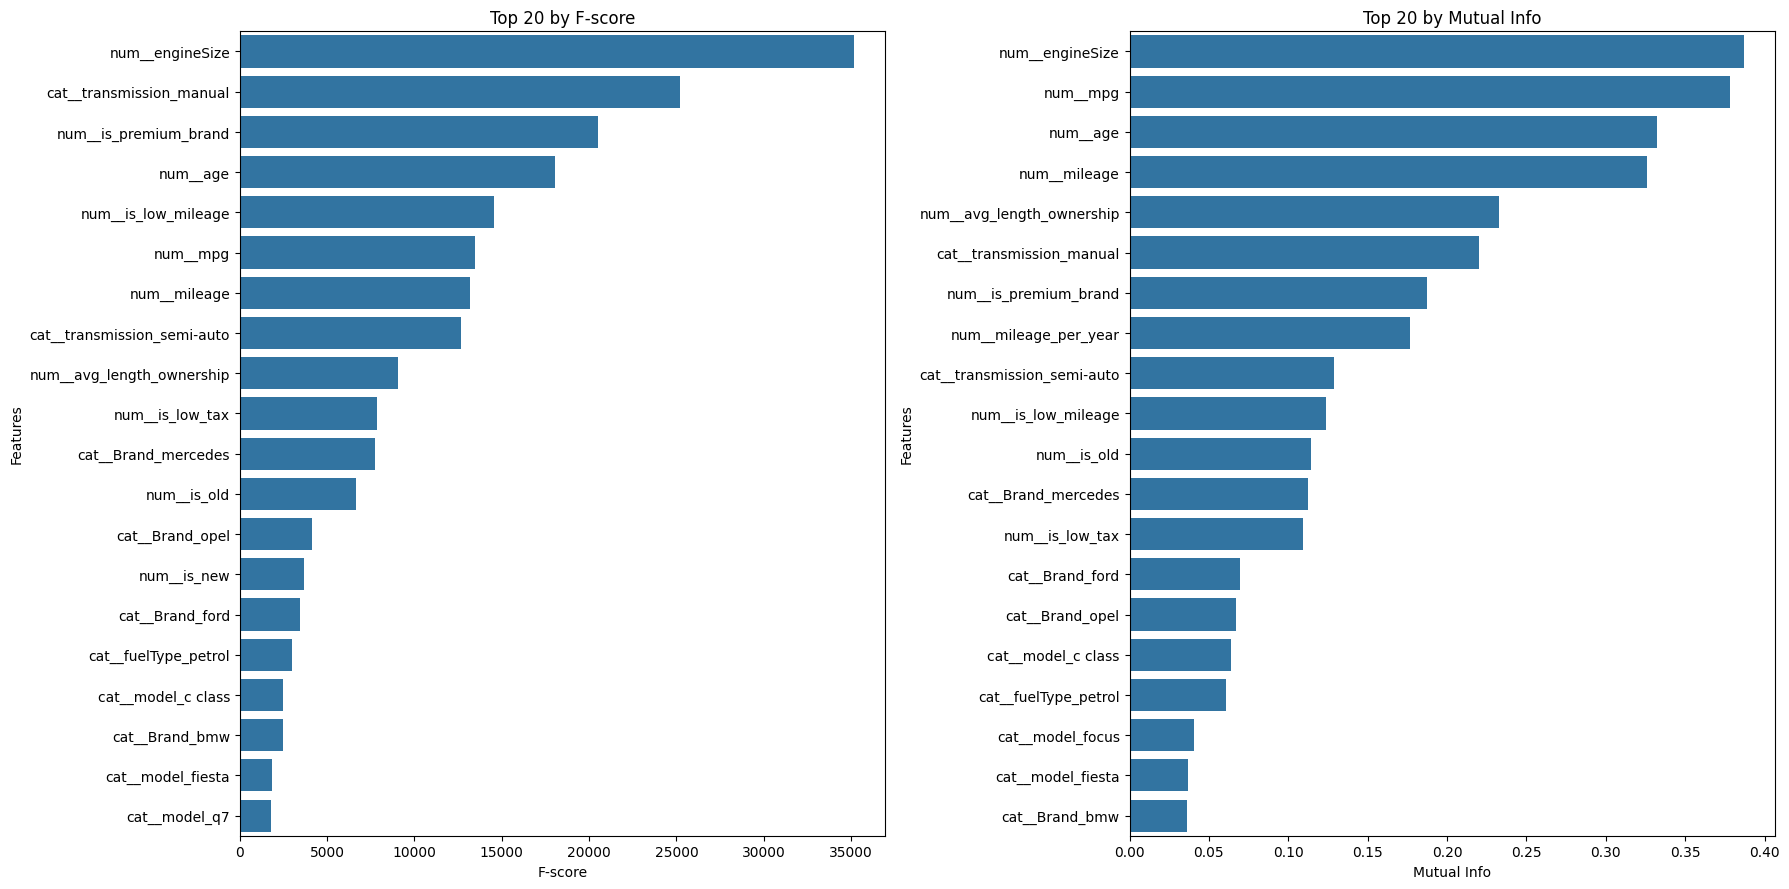

In [114]:
# Linear relationship test
selector_f = SelectKBest(score_func=f_regression, k='all').fit(X_filtered, y_train)

# Non-linear relationship test
selector_mi = SelectKBest(score_func=mutual_info_regression, k='all').fit(X_filtered, y_train)

# Dataframes to hold feature scores for both tests
scores_linear = pd.DataFrame({
    'feature': X_filtered.columns,
    'F_score': selector_f.scores_,
}).sort_values(by="F_score", ascending=False)

scores_non_linear = pd.DataFrame({
    'feature': X_filtered.columns,
    'Mutual_info': selector_mi.scores_
}).sort_values("Mutual_info", ascending=False)

# Plot top features from both tests
top_k = 20
scores_linear_top = scores_linear.head(top_k)
scores_non_linear_top = scores_non_linear.head(top_k)

plt.figure(figsize=(18,9))

plt.subplot(1,2,1)
sns.barplot(x='F_score', y='feature', data= scores_linear_top)
plt.title(f'Top {top_k} by F-score')
plt.xlabel('F-score')
plt.ylabel('Features')

plt.subplot(1,2,2)
sns.barplot(x='Mutual_info', y='feature', data=scores_non_linear_top)
plt.title(f'Top {top_k} by Mutual Info')
plt.xlabel('Mutual Info')
plt.ylabel('Features')

plt.tight_layout()
plt.show()


In [115]:
# Bottom 10 by each metric
bottom_f  = scores_linear.tail(20)[['feature', 'F_score']].reset_index(drop=True)
bottom_mi = scores_non_linear.tail(20)[['feature', 'Mutual_info']].reset_index(drop=True)

# Concatenate side-by-side lists of bottom features for comparison
bottom_both = pd.concat([bottom_f, bottom_mi], axis=1)

print("Bottom 10 features by F-score and Mutual Info:")
display(bottom_both)
# list of features that appear in BOTH bottom 10 lists
common_bottom_features = sorted(set(bottom_f['feature']) & set(bottom_mi['feature']))

print("\n Features in bottom-10 for BOTH F-score and Mutual Info:")
for f in common_bottom_features:
    print(" -", f)



Bottom 10 features by F-score and Mutual Info:


,feature,F_score,feature,Mutual_info
0,cat__model_grandland,0.362150,cat__model_sl class,0.0
1,cat__model_s5,0.306914,cat__model_scirocco,0.0
2,cat__Brand_vw,0.305133,cat__model_rs6,0.0
3,cat__model_golf,0.293477,cat__model_s class,0.0
4,cat__model_m6,0.278343,cat__model_tourneo custom,0.0
5,cat__transmission_unknown,0.226545,cat__model_tourneo connect,0.0
6,cat__model_kadjar,0.189642,cat__model_tigua,0.0
7,cat__model_scala,0.166892,cat__model_tigra,0.0
8,cat__model_i3,0.149557,cat__model_supra,0.0
9,cat__model_caddy life,0.149324,cat__model_sq7,0.0



 Features in bottom-10 for BOTH F-score and Mutual Info:
 - cat__fuelType_electric


RFE will be used to find the optimal number of features by iteratively removing weak features until it finds the most effective subset while keeping it as small as possible. Only features that improve the predictive performance are going to be kept. We will run two approaches to access if there is a big difference between optimal sets and check if there are features that aren't considered optimal in both.

In [116]:
model = RandomForestRegressor(random_state=0)
model.fit(X_filtered, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
model_2 = GradientBoostingRegressor(random_state=0)
model_2.fit(X_filtered, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [118]:
rfe_rf = RFE(estimator=model, step=5)
rfe_rf.fit(X_filtered, y_train)

selected_rf = X_filtered.columns[rfe_rf.support_]

In [119]:
print(f"Optimal number of features for Random Forest: {rfe_rf.n_features_}")
print(f"Features selected: {selected_rf.tolist()}")
print(f"Ranking: {rfe_rf.ranking_}")

Optimal number of features for Random Forest: 112
Features selected: ['num__mileage', 'num__mpg', 'num__engineSize', 'num__paintQuality%', 'num__previousOwners', 'num__age', 'num__mileage_per_year', 'num__is_premium_brand', 'num__avg_length_ownership', 'num__is_old', 'num__is_new', 'num__is_low_mileage', 'num__had_many_owners', 'num__had_few_owners', 'num__is_high_tax', 'num__is_low_tax', 'cat__Brand_bmw', 'cat__Brand_ford', 'cat__Brand_hyundai', 'cat__Brand_mercedes', 'cat__Brand_opel', 'cat__Brand_skoda', 'cat__Brand_toyota', 'cat__Brand_vw', 'cat__model_2 series', 'cat__model_3 series', 'cat__model_4 series', 'cat__model_5 series', 'cat__model_6 series', 'cat__model_7 series', 'cat__model_8 series', 'cat__model_a class', 'cat__model_a1', 'cat__model_a3', 'cat__model_a4', 'cat__model_a5', 'cat__model_a6', 'cat__model_a8', 'cat__model_adam', 'cat__model_amarok', 'cat__model_astra', 'cat__model_aygo', 'cat__model_b class', 'cat__model_c class', 'cat__model_c-hr', 'cat__model_california

In [120]:
rfe_gb = RFE(estimator=model_2, step=5)
rfe_gb.fit(X_filtered, y_train)

selected_gb = X_filtered.columns[rfe_gb.support_]

In [121]:
print(f"Optimal number of features for Gradient Boosting: {rfe_gb.n_features_}")
print(f"Features selected: {selected_gb.tolist()}")
print(f"Ranking: {rfe_gb.ranking_}")

Optimal number of features for Gradient Boosting: 112
Features selected: ['num__mileage', 'num__mpg', 'num__engineSize', 'num__paintQuality%', 'num__previousOwners', 'num__age', 'num__mileage_per_year', 'num__is_premium_brand', 'num__avg_length_ownership', 'num__is_old', 'num__is_new', 'num__is_high_tax', 'num__is_low_tax', 'cat__Brand_bmw', 'cat__Brand_mercedes', 'cat__Brand_opel', 'cat__Brand_toyota', 'cat__Brand_vw', 'cat__model_2 series', 'cat__model_8 series', 'cat__model_a class', 'cat__model_amarok', 'cat__model_aygo', 'cat__model_b class', 'cat__model_c-hr', 'cat__model_california', 'cat__model_caravelle', 'cat__model_citigo', 'cat__model_corsa', 'cat__model_fabia', 'cat__model_focus', 'cat__model_g class', 'cat__model_getz', 'cat__model_gl class', 'cat__model_glb class', 'cat__model_glc class', 'cat__model_gle class', 'cat__model_gls class', 'cat__model_golf', 'cat__model_golf s', 'cat__model_golf sv', 'cat__model_grand c-max', 'cat__model_grand tourneo connect', 'cat__model_g

In [122]:
# Compare set of dropped features in each approach and then join them for printing
all_feats   = set(X_filtered.columns)
rf_selected = set(selected_rf)
gb_selected = set(selected_gb)

rf_dropped = all_feats - rf_selected
gb_dropped = all_feats - gb_selected

features_dropped_by_both = sorted(rf_dropped & gb_dropped)

print("Features dropped by both RFE methods:", features_dropped_by_both)


Features dropped by both RFE methods: ['cat__model_a2', 'cat__model_a7', 'cat__model_accent', 'cat__model_agila', 'cat__model_ampera', 'cat__model_antara', 'cat__model_arteon', 'cat__model_auris', 'cat__model_avensis', 'cat__model_b-max', 'cat__model_beetle', 'cat__model_c 230', 'cat__model_c-max', 'cat__model_caddy', 'cat__model_caddy life', 'cat__model_caddy maxi', 'cat__model_caddy maxi life', 'cat__model_camry', 'cat__model_cascada', 'cat__model_cc', 'cat__model_cla class', 'cat__model_clc class', 'cat__model_clk class', 'cat__model_cls class', 'cat__model_combo life', 'cat__model_corolla', 'cat__model_crossland', 'cat__model_crossland x', 'cat__model_edge', 'cat__model_eos', 'cat__model_escort', 'cat__model_fusion', 'cat__model_galaxy', 'cat__model_grandland', 'cat__model_gt86', 'cat__model_i2', 'cat__model_i20', 'cat__model_i3', 'cat__model_i30', 'cat__model_i40', 'cat__model_i80', 'cat__model_i800', 'cat__model_insignia', 'cat__model_ioniq', 'cat__model_iq', 'cat__model_ix2', 'c

LassoCV will be used as it forces weak coefficients to zero through an L1 regularization penalty. This simplifies linear models, handles multicollinearity well and produces sparse, interpretable solutions

In [123]:
lasso_reg = Lasso()
lasso_reg.fit(X_filtered, y_train)

coef = pd.Series(lasso_reg.coef_, index = X_filtered.columns)
coef.sort_values()

num__age              -36402.119059
num__mileage          -11146.768137
num__mpg               -6119.882133
cat__model_ka+         -5825.596880
cat__model_up          -5316.172722
                           ...     
cat__model_8 series    29231.073552
cat__model_i8          32868.695560
cat__model_x7          33866.143759
cat__model_g class     57060.773186
cat__model_r8          60894.377908
Length: 225, dtype: float64

In [124]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")
print("Features dropped by Lasso regression: {}." .format(coef[coef == 0].index.tolist()))

Lasso picked 149 variables and eliminated the other 76 variables
Features dropped by Lasso regression: ['cat__Brand_ford', 'cat__model_a2', 'cat__model_a7', 'cat__model_accent', 'cat__model_agila', 'cat__model_ampera', 'cat__model_antara', 'cat__model_beetle', 'cat__model_c 230', 'cat__model_caddy', 'cat__model_caddy life', 'cat__model_caddy maxi', 'cat__model_camry', 'cat__model_cascada', 'cat__model_clc class', 'cat__model_clk class', 'cat__model_combo life', 'cat__model_corolla', 'cat__model_crossland', 'cat__model_eos', 'cat__model_escort', 'cat__model_fusion', 'cat__model_getz', 'cat__model_gl class', 'cat__model_glb class', 'cat__model_golf s', 'cat__model_grand tourneo connect', 'cat__model_grandland', 'cat__model_gt86', 'cat__model_gtc', 'cat__model_hilux', 'cat__model_i1', 'cat__model_i2', 'cat__model_i30', 'cat__model_i40', 'cat__model_i80', 'cat__model_ioniq', 'cat__model_iq', 'cat__model_ix2', 'cat__model_ix35', 'cat__model_jetta', 'cat__model_kadjar', 'cat__model_kamiq', '

Tree based Feature importance focuses on reducing impurity across decision trees

In [125]:
# Feature importance from Random Forest dataframe
feature_importance_rf = pd.DataFrame({'Feature': X_filtered.columns, 'Importance': model.feature_importances_})
print(feature_importance_rf.sort_values(by='Importance', ascending=False))

# Identify features with zero importance
zero_imp_rf = feature_importance_rf.loc[
    feature_importance_rf["Importance"] == 0, "Feature"
].tolist()

print("RF features with exactly zero importance:")
print(len(zero_imp_rf), zero_imp_rf)
print(f"Number of features remaining after removing zero-importance features for RF: {X_filtered.shape[1] - len(zero_imp_rf)}")

                      Feature    Importance
217  cat__transmission_manual  2.936250e-01
5                    num__age  2.179968e-01
2             num__engineSize  2.133006e-01
1                    num__mpg  5.969211e-02
0                num__mileage  5.151200e-02
..                        ...           ...
184          cat__model_tigra  9.973926e-09
119            cat__model_ix2  7.404461e-09
54           cat__model_c 230  4.911473e-09
82          cat__model_escort  1.785980e-09
70       cat__model_clc class  9.934134e-10

[225 rows x 2 columns]
RF features with exactly zero importance:
0 []
Number of features remaining after removing zero-importance features for RF: 225


In [126]:
# Gradient Boosting feature importance dataframe
feature_importance_gb = pd.DataFrame({'Feature': X_filtered.columns, 'Importance': model_2.feature_importances_})
print(feature_importance_gb.sort_values(by='Importance', ascending=False))

# Identify features with zero importance
zero_imp_gb = feature_importance_gb.loc[
    feature_importance_gb["Importance"] == 0, "Feature"
].tolist()

print("GB features with exactly zero importance:")
print(len(zero_imp_gb) , zero_imp_gb)
print(f"Number of features remaining after removing zero-importance features for GB: {X_filtered.shape[1] - len(zero_imp_gb)}")

                       Feature  Importance
2              num__engineSize    0.252482
217   cat__transmission_manual    0.182392
5                     num__age    0.167787
0                 num__mileage    0.132020
7        num__is_premium_brand    0.100113
..                         ...         ...
213              cat__model_z3    0.000000
220  cat__transmission_unknown    0.000000
218    cat__transmission_other    0.000000
221     cat__fuelType_electric    0.000000
223        cat__fuelType_other    0.000000

[225 rows x 2 columns]
GB features with exactly zero importance:
161 ['num__is_low_mileage', 'num__had_few_owners', 'cat__Brand_ford', 'cat__Brand_hyundai', 'cat__Brand_skoda', 'cat__model_3 series', 'cat__model_4 series', 'cat__model_5 series', 'cat__model_6 series', 'cat__model_7 series', 'cat__model_a1', 'cat__model_a2', 'cat__model_a3', 'cat__model_a4', 'cat__model_a5', 'cat__model_a6', 'cat__model_a7', 'cat__model_a8', 'cat__model_accent', 'cat__model_adam', 'cat__model_agi

In [127]:
# Combine all feature selection results
all_features = X_filtered.columns

# low-relevance features (bad MI and bad F-score)
to_drop_low = set(features_dropped_by_both)

# High-importance sets
# Random Forest importance
imp_rf = feature_importance_rf.set_index("Feature")["Importance"]
high_imp_rf = set(imp_rf[imp_rf >= imp_rf.median()].index)

# Gradient Boosting importance
imp_gb = feature_importance_gb.set_index("Feature")["Importance"]
high_imp_gb = set(imp_gb[imp_gb >= imp_gb.median()].index)

# RFE selections (already have these)
set_rfe_rf = set(selected_rf)
set_rfe_gb = set(selected_gb)

# Lasso selections
lasso_keep = set(coef[coef != 0].index)

# Voting: each method = 1 vote
votes = {f: 0 for f in all_features}

for f in all_features:
    if f in high_imp_rf:
        votes[f] += 1
    if f in high_imp_gb:
        votes[f] += 1
    if f in set_rfe_rf:
        votes[f] += 1
    if f in set_rfe_gb:
        votes[f] += 1
    if f in lasso_keep:   
        votes[f] += 1

# keep features with at least 2 "yes" votes and not in the hard-drop list
final_selected_features = [
    f for f, v in votes.items()
    if (v >= 2) and (f not in to_drop_low)
]

print(f"Final number of features: {len(final_selected_features)}")


Final number of features: 151


In [198]:
final_selected_features

['num__mileage',
 'num__mpg',
 'num__engineSize',
 'num__paintQuality%',
 'num__previousOwners',
 'num__age',
 'num__mileage_per_year',
 'num__is_premium_brand',
 'num__avg_length_ownership',
 'num__is_old',
 'num__is_new',
 'num__is_low_mileage',
 'num__had_many_owners',
 'num__had_few_owners',
 'num__is_high_tax',
 'num__is_low_tax',
 'cat__Brand_bmw',
 'cat__Brand_ford',
 'cat__Brand_hyundai',
 'cat__Brand_mercedes',
 'cat__Brand_opel',
 'cat__Brand_skoda',
 'cat__Brand_toyota',
 'cat__Brand_vw',
 'cat__model_2 series',
 'cat__model_3 series',
 'cat__model_4 series',
 'cat__model_5 series',
 'cat__model_6 series',
 'cat__model_7 series',
 'cat__model_8 series',
 'cat__model_a class',
 'cat__model_a1',
 'cat__model_a3',
 'cat__model_a4',
 'cat__model_a5',
 'cat__model_a6',
 'cat__model_a8',
 'cat__model_adam',
 'cat__model_amarok',
 'cat__model_astra',
 'cat__model_aygo',
 'cat__model_b class',
 'cat__model_c class',
 'cat__model_c-hr',
 'cat__model_california',
 'cat__model_caravell

In summary:

Filter methods (Initial cleaning)

Starting from the fully encoded dataset (231 features), we first removed:
- Variables with zero variance were removed using VarianceThreshold.
- One variable from each pair of predictors with correlation > 0.8 to reduce multicollinearity.
- Features with consistently low F-score and mutual information with the target were removed, since they contributed little predictive signal.

Embedded importance (tree-based models)

On the cleaned feature space we trained a Random Forest and a Gradient Boosting Regressor. For each model we computed:
- Features with importance above the median importance for each model were flagged as “high-importance” candidates.
- We also fitted a Lasso regression. Because Lasso drives many coefficients exactly to zero, we treated features with non-zero coefficients as additional “important” predictors and used them as another signal in the voting stage.

Wrapper methods (RFE).
- We then ran Recursive Feature Elimination (RFE) with both Random Forest and Gradient Boosting as base estimators on the training set. Each RFE run selected a subset of features that maximised validation performance for that model.

Final feature set (voting scheme)

For each remaining predictor we counted how many methods considered it important:
- high importance in Random Forest
- high importance in Gradient Boosting
- selected by RFE with Random Forest
- selected by RFE with Gradient Boosting
- non-zero coefficient in Lasso regression

We kept features that obtained at least two votes and simultaneously were not in the group of features with very low F-score and mutual information.

Feature Selection Results

In [128]:
# Select final features for train, validation, and test sets
# Apply to all splits
X_train_selected = X_filtered[final_selected_features].copy()
X_val_selected = X_val_filtered[final_selected_features].copy()
X_test_selected = x_test_filtered[final_selected_features].copy()

# Modeling

Models picked:
- Linear Regression: Finds a straight line (or hyperplane) that best fits the data by minimizing the difference between predicted and actual values.
- Ridge Regression: Similar to linear regression, but it adds a small penalty to large coefficients so the model doesn’t rely too heavily on any one feature.
- ElasticNet: Mixes Ridge (L2) and Lasso (L1) penalties — keeps coefficients small like Ridge but can also drop unimportant ones like Lasso.
- Bayesian Ridge: Similar to Ridge, but it treats model parameters as probabilities, giving you uncertainty estimates for predictions.
- Huber Regressor: Acts like linear regression for normal points but ignores large errors from outliers so they don’t distort the model.
- RANSAC: Builds many small models using random subsets of data and picks the one that best fits the majority, ignoring outliers.
- Theil-Sen: Calculates the median slope between all pairs of points — making it very stable when the data has noise or outliers.
- Decision Tree: Splits data step-by-step into smaller groups based on feature values, learning simple rules to make predictions.
- Random Forest: Builds many decision trees on random samples of data and averages their results for better accuracy and stability.
- Extra Trees: Like Random Forest but uses more randomness when splitting data — makes training faster and reduces overfitting.
- Linear SVR: Uses support vectors (key data points) to fit a line within a “margin” that minimizes prediction error — efficient for linear or slightly nonlinear data.
- KNN (K-Nearest Neighbors): Looks at the most similar data points (neighbors) and averages their values to predict the output.
- MLP Regressor (Multi-Layer Perceptron): A simple neural network that learns patterns by passing data through layers of neurons that adjust weights to minimize errors — great for capturing complex, nonlinear relationships.

In [129]:
# Baseline models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=0),
    "Random Forest": RandomForestRegressor(random_state=0),
    "ElasticNet": ElasticNet(random_state=0),
    "Huber": HuberRegressor(),
    "Bayesian Ridge": BayesianRidge(),
    "RANSAC": RANSACRegressor(random_state=0),
    "Theil-Sen": TheilSenRegressor(random_state=0),
    "SVR": LinearSVR(random_state=0),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=0),
    "Extra Tree": ExtraTreeRegressor(random_state=0),
    "Multi-Layer Perceptron": MLPRegressor(random_state=0), 
    "AdaBoost": AdaBoostRegressor(random_state=0),
    "Gradient Boosting": GradientBoostingRegressor(random_state=0),
}

results = []

for name, model in models.items():
    # fit on train
    model.fit(X_train_selected, y_train)

    # predictions
    y_train_pred = model.predict(X_train_selected)
    y_val_pred = model.predict(X_val_selected)

    # train metrics
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    # val metrics
    r2_val = r2_score(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results.append({
        "Model": name,
        "Training MAE": mae_train,
        "Training RMSE": rmse_train,
        "Training R-squared": r2_train,
        "Validation MAE": mae_val,
        "Validation RMSE": rmse_val,
        "Validation R-squared": r2_val

    })


c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


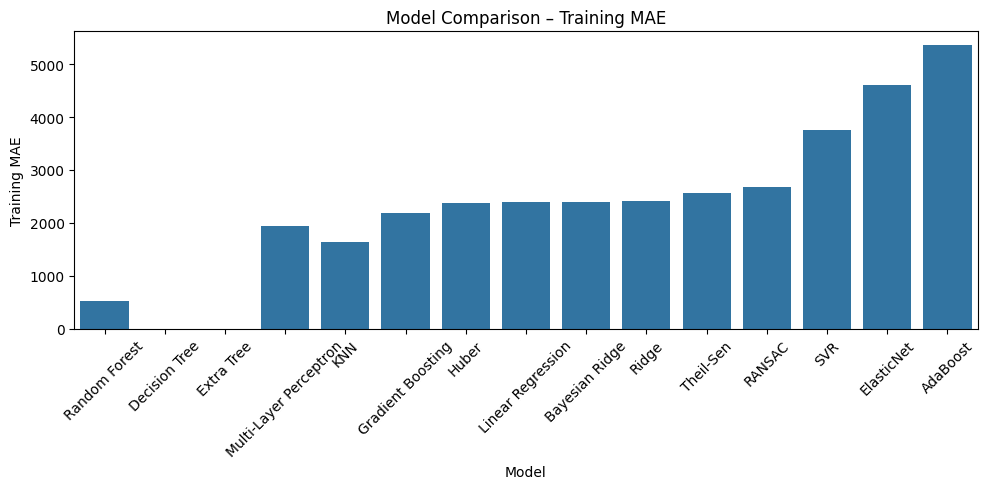

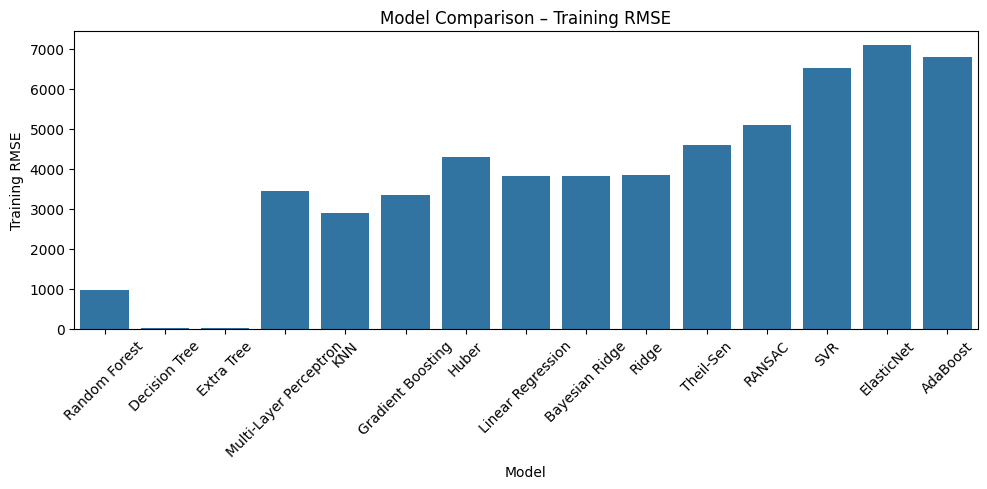

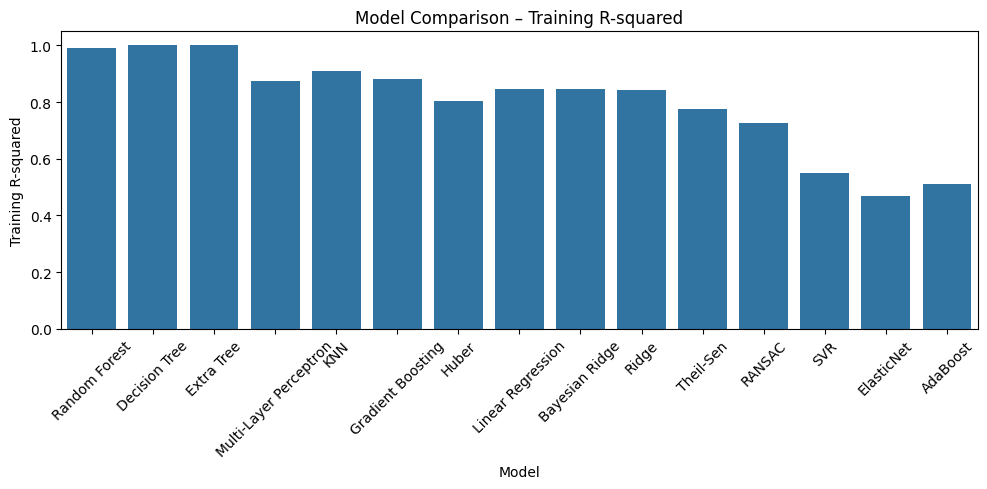

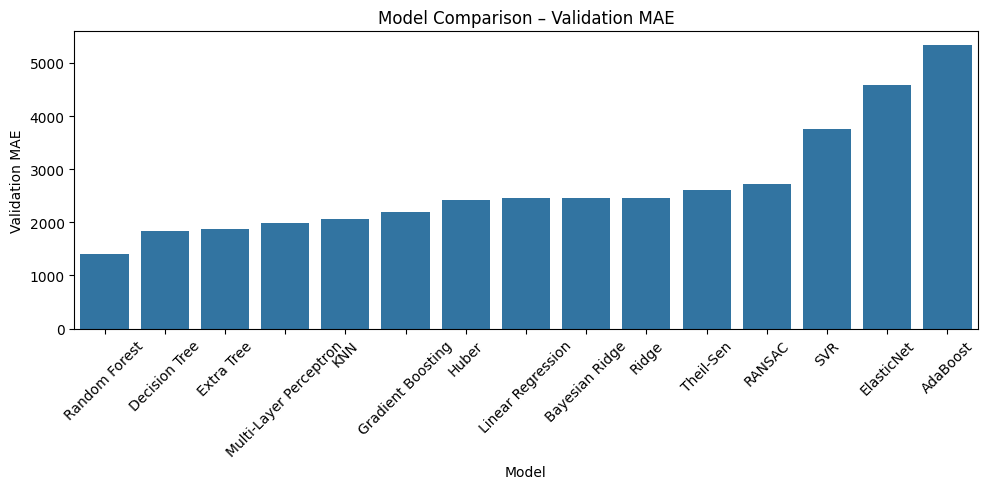

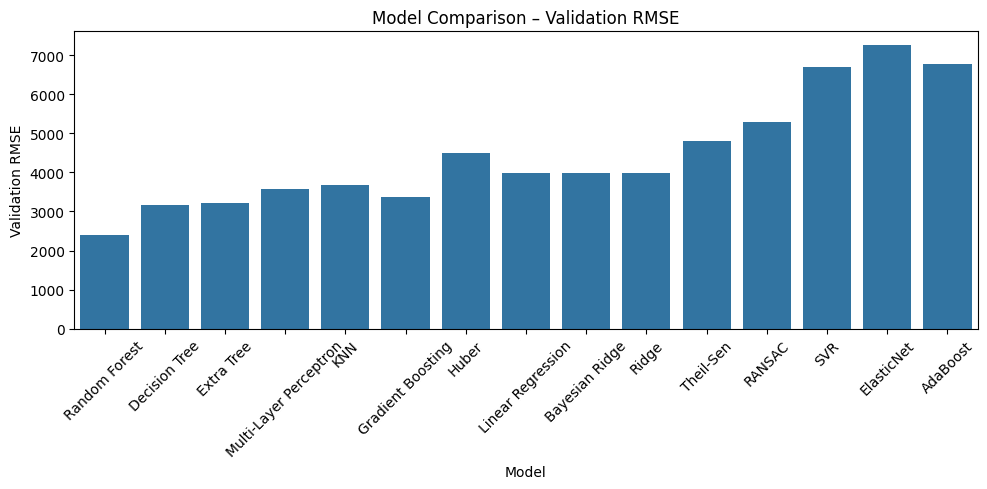

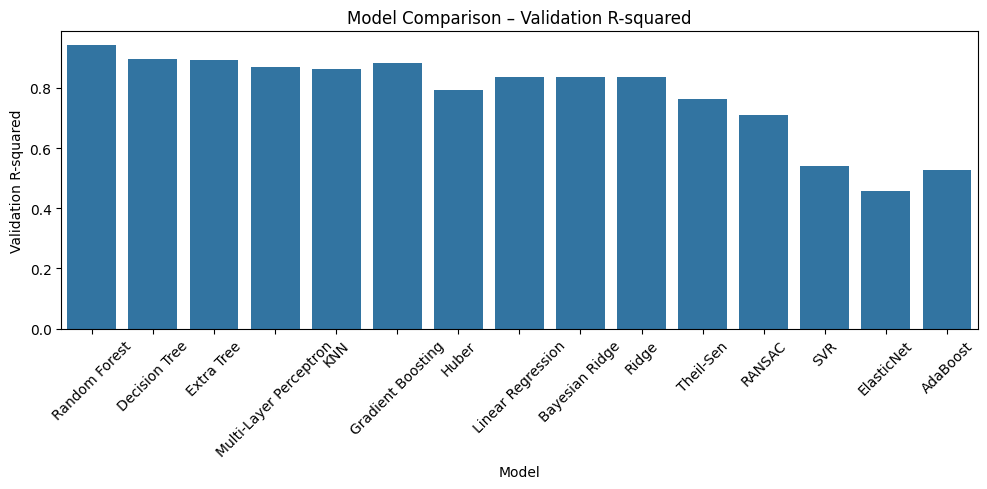

In [130]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# sort by validation MAE
results_df = results_df.sort_values(by="Validation MAE", ascending=True)

metrics = [
    'Training MAE', 'Training RMSE', 'Training R-squared',
    'Validation MAE', 'Validation RMSE', 'Validation R-squared'
]

# plot bar charts for each metric
for metric in metrics:
    plt.figure(figsize=(10,5))
    sns.barplot(x="Model", y=metric, data=results_df)
    plt.title(f"Model Comparison – {metric}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [131]:
results_df

,Model,Training MAE,Training RMSE,Training R-squared,Validation MAE,Validation RMSE,Validation R-squared
2,Random Forest,523.569964,959.896331,0.990218,1397.848532,2392.283214,0.941127
10,Decision Tree,0.062319,4.978651,1.000000,1839.183273,3175.875462,0.896244
11,Extra Tree,0.118646,7.145677,0.999999,1872.356273,3230.112820,0.892670
12,Multi-Layer Perceptron,1947.064263,3450.330205,0.873616,1981.523637,3573.307552,0.868651
9,KNN,1634.553868,2896.234185,0.910949,2061.144537,3670.292882,0.861424
14,Gradient Boosting,2176.645950,3329.328930,0.882325,2200.446966,3378.423832,0.882587
4,Huber,2373.049269,4291.939103,0.804442,2420.779943,4486.441000,0.792942
0,Linear Regression,2398.451575,3825.522947,0.844636,2450.868227,3988.644879,0.836342
5,Bayesian Ridge,2398.900415,3825.566076,0.844632,2451.404195,3989.033453,0.836310
1,Ridge,2403.543047,3828.870276,0.844364,2456.849035,3994.675571,0.835846


### Hyperparameter Tuning

In [ ]:
# make sure both X and y have matching indexes
X_train_selected = X_train_selected.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Parameter grid
param_grid_rf = {
    "n_estimators": [100, 200, 300],  
    "max_depth": [10, 20],        
    "min_samples_split": [2, 5, 10],       
    "min_samples_leaf": [1, 2],           
    "max_features": ["sqrt"],  
}

In [133]:
best_mae = float("inf")
best_params = None
rf_results = []

for params in ParameterGrid(param_grid_rf):

    print("Testing params:", params)

    model_rf = RandomForestRegressor(
        random_state=0,
        n_jobs=-1,
        **params
    )

    # Fit model on training set
    model_rf.fit(X_train_selected, y_train)
    
    # Evaluate on validation set
    val_pred_rf = model_rf.predict(X_val_selected)

    # Calculate validation metrics
    val_mae = mean_absolute_error(y_val, val_pred_rf)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_rf))
    val_r2 = r2_score(y_val, val_pred_rf)
    
    rf_results.append({**params, "val_mae": val_mae, "val_rmse": val_rmse, "val_r2": val_r2})
    
    if val_mae < best_mae:
        best_mae = val_mae
        best_params = params

print("Best RF params:", best_params)
print("Best validation MAE:", best_mae)

rf_results_df = pd.DataFrame(rf_results).sort_values("val_mae")
display(rf_results_df.head())

Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Testing params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimato

,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,val_mae,val_rmse,val_r2
18,20,sqrt,1,2,100,1695.300011,2935.322430,0.911366
20,20,sqrt,1,2,300,1701.175845,2942.148789,0.910954
19,20,sqrt,1,2,200,1701.678911,2944.175101,0.910831
21,20,sqrt,1,5,100,1709.086704,2920.695045,0.912247
22,20,sqrt,1,5,200,1709.892988,2950.693868,0.910436


In [134]:
best_rf = RandomForestRegressor(random_state=0, n_jobs=-1, **best_params)

In [135]:
param_grid_mlp = {
    "hidden_layer_sizes": [ (256, 128, 64), (256, 256),],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-3, 5e-3],
}

In [136]:
best_mae = float("inf")
best_params = None
best_mlp = None

mlp_results = []

for params in ParameterGrid(param_grid_mlp):

    print("Testing params:", params)

    mlp_model = MLPRegressor(
        random_state=0,
        max_iter=500,
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        early_stopping=True,   
        n_iter_no_change=10,
        batch_size=128,
        **params
    )

    # fit on training set
    mlp_model.fit(X_train_selected, y_train)

    # evaluate on validation set
    val_pred_mlp = mlp_model.predict(X_val_selected)

    # Calculate validation metrics
    mae = mean_absolute_error(y_val, val_pred_mlp)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred_mlp))
    r2 = r2_score(y_val, val_pred_mlp)

    mlp_results.append({
        **params,
        "val_mae": mae,
        "val_rmse": rmse,
        "val_r2": r2,
    })

    if mae < best_mae:
        best_mae = mae
        best_params = params

print("Best MLP params:", best_params)
print("Best validation MAE:", best_mae)

mlp_results_df = pd.DataFrame(mlp_results).sort_values("val_mae")
display(mlp_results_df.head())


Testing params: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Testing params: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.005}
Testing params: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 256), 'learning_rate_init': 0.001}
Testing params: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 256), 'learning_rate_init': 0.005}
Testing params: {'alpha': 0.001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Testing params: {'alpha': 0.001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.005}
Testing params: {'alpha': 0.001, 'hidden_layer_sizes': (256, 256), 'learning_rate_init': 0.001}
Testing params: {'alpha': 0.001, 'hidden_layer_sizes': (256, 256), 'learning_rate_init': 0.005}
Testing params: {'alpha': 0.01, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Testing params: {'alpha': 0.01, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.005}
Testing params

,alpha,hidden_layer_sizes,learning_rate_init,val_mae,val_rmse,val_r2
0,0.0001,"(256, 128, 64)",0.001,1551.124081,2565.929771,0.932271
8,0.0100,"(256, 128, 64)",0.001,1554.119252,2564.237073,0.932360
4,0.0010,"(256, 128, 64)",0.001,1562.908181,2574.497698,0.931818
1,0.0001,"(256, 128, 64)",0.005,1569.956813,2591.073168,0.930937
6,0.0010,"(256, 256)",0.001,1570.282132,2611.259122,0.929857


In [137]:
best_mlp = MLPRegressor(random_state=0, max_iter=500, activation="relu", solver="adam", learning_rate="adaptive", early_stopping=True, n_iter_no_change=10, **best_params )

In [138]:
elastic_grid = {
    "alpha": [0.001, 0.01, 0.1, 1.0],   
    "l1_ratio": [0.1, 0.5, 0.7, 0.9],      
}

In [139]:
best_mae = float("inf")
best_params = None
best_elastic = None

elastic_results = []

for params in ParameterGrid(elastic_grid):

    print("Testing params:", params)

    model_elastic = ElasticNet(
        random_state=0,
        fit_intercept=True,
        max_iter=1000,
        tol=1e-3,
        selection="cyclic",
        **params
    )

    # fit on training set
    model_elastic.fit(X_train_selected, y_train)

    # evaluate on validation set
    val_pred_elastic = model_elastic.predict(X_val_selected)

    # Calculate validation metrics
    mae = mean_absolute_error(y_val, val_pred_elastic)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred_elastic))
    r2 = r2_score(y_val, val_pred_elastic)

    elastic_results.append({
        **params,
        "val_mae": mae,
        "val_rmse": rmse,
        "val_r2": r2,
    })

    if mae < best_mae:
        best_mae = mae
        best_params = params

print("Best Elastic Net params:", best_params)
print("Best validation MAE:", best_mae)

elastic_results_df = pd.DataFrame(elastic_results).sort_values("val_mae")
display(elastic_results_df.head())

Testing params: {'alpha': 0.001, 'l1_ratio': 0.1}
Testing params: {'alpha': 0.001, 'l1_ratio': 0.5}
Testing params: {'alpha': 0.001, 'l1_ratio': 0.7}


c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.740e+10, tolerance: 5.723e+09
  model = cd_fast.enet_coordinate_descent(


Testing params: {'alpha': 0.001, 'l1_ratio': 0.9}


c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.037e+11, tolerance: 5.723e+09
  model = cd_fast.enet_coordinate_descent(


Testing params: {'alpha': 0.01, 'l1_ratio': 0.1}
Testing params: {'alpha': 0.01, 'l1_ratio': 0.5}
Testing params: {'alpha': 0.01, 'l1_ratio': 0.7}
Testing params: {'alpha': 0.01, 'l1_ratio': 0.9}
Testing params: {'alpha': 0.1, 'l1_ratio': 0.1}
Testing params: {'alpha': 0.1, 'l1_ratio': 0.5}
Testing params: {'alpha': 0.1, 'l1_ratio': 0.7}
Testing params: {'alpha': 0.1, 'l1_ratio': 0.9}
Testing params: {'alpha': 1.0, 'l1_ratio': 0.1}
Testing params: {'alpha': 1.0, 'l1_ratio': 0.5}
Testing params: {'alpha': 1.0, 'l1_ratio': 0.7}
Testing params: {'alpha': 1.0, 'l1_ratio': 0.9}
Best Elastic Net params: {'alpha': 0.001, 'l1_ratio': 0.9}
Best validation MAE: 2490.2076030246985


,alpha,l1_ratio,val_mae,val_rmse,val_r2
3,0.001,0.9,2490.207603,4052.123488,0.831091
2,0.001,0.7,2544.818996,4175.575149,0.820642
1,0.001,0.5,2580.386800,4259.515324,0.813359
0,0.001,0.1,2629.240548,4368.642936,0.803673
7,0.010,0.9,2638.851058,4389.364313,0.801806


In [140]:
best_elastic = ElasticNet(random_state=0, fit_intercept=True, max_iter=1000, tol=1e-3, selection="cyclic", **best_params)

In [141]:
stacked = StackingRegressor(
    estimators=[('rf', RandomForestRegressor(random_state=0, n_jobs=-1)),
                ('mlp', best_mlp),
                ("elastic", best_elastic)],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

stacked.fit(X_train_selected, y_train)

,estimators,"[('rf', ...), ('mlp', ...), ...]"
,final_estimator,Ridge()
,cv,None
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [142]:
# Evaluate on validation data
y_pred_stacked = stacked.predict(X_val_selected)

# Compute metrics
mae_val_stacked = mean_absolute_error(y_val, y_pred_stacked)
rmse_val_stacked = np.sqrt(mean_squared_error(y_val, y_pred_stacked))
r2_val_stacked = r2_score(y_val, y_pred_stacked)

print(f"Stacked MAE: {mae_val_stacked:.2f}")
print(f"Stacked RMSE: {rmse_val_stacked:.2f}")
print(f"Stacked R²: {r2_val_stacked:.4f}")

Stacked MAE: 1382.68
Stacked RMSE: 2331.18
Stacked R²: 0.9441


Deep Neural Networks

We will test if better performances can be achieved through a custom NN architecture

In [143]:
X_train_dense = X_train_selected.copy()
X_val_dense = X_val_selected.copy()
X_test_dense = X_test_selected.copy()

In [144]:
X_train_nn = pd.DataFrame(X_train_dense, index=X_train_dense.index, columns=X_train_dense.columns)
X_val_nn = pd.DataFrame(X_val_dense, index=X_val_dense.index, columns=X_val_dense.columns)
X_test_nn = pd.DataFrame(X_test_dense, index=X_test_dense.index, columns=X_test_dense.columns)

In [ ]:
# Custom Dataset for regression
class CarPriceDataset(Dataset):
    def __init__(self, X, y=None):
        """
        X: numpy array of features, shape (n_samples, n_features)
        y: numpy array of targets, shape (n_samples,) or None for test data
        """
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        else:
            X = np.asarray(X)
        
        self.X = torch.tensor(X, dtype=torch.float32)

        if y is None:
            self.y = None
        else:
            if isinstance(y, (pd.Series, pd.DataFrame)):
                y = y.to_numpy().ravel()
            else:
                y = np.asarray(y).ravel()

            self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        """
        Return number of samples in the dataset.
        Dataloaders call this to know how many batches exist.
        """
        return self.X.shape[0]

    def __getitem__(self, idx):
        """
        Given an index (or slice), return:
        - (X[idx], y[idx]) for supervised training/validation
        - X[idx] only if we don't have labels (self.y is None)
        This is what the DataLoader uses when it builds each batch.
        """
        if self.y is None:
            # Unlabelled dataset (e.g. test set)
            return self.X[idx]
        # Standard supervised case: return feature vector and target
        return self.X[idx], self.y[idx]


In [146]:
# Create datasets
train_dataset = CarPriceDataset(X_train_nn, y_train)
val_dataset = CarPriceDataset(X_val_nn, y_val)
test_dataset = CarPriceDataset(X_test_nn, None)

In [147]:
# DataLoaders (mini-batches)
batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Define a simple fully-connected neural network
class CarPriceNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        # Define the network architecture. This network has 3 hidden layers with BatchNorm, LeakyReLU activations, and Dropout.
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            # Normalise activations across the batch for faster, more stable training
            nn.BatchNorm1d(512),
            # keeps a small negative output so units can still learn when inputs are below 0
            nn.LeakyReLU(),
            # Randomly drop 10% of units during training to reduce overfitting
            nn.Dropout(0.1),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 1)  # single continuous output
        )
        
    def forward(self, x):
        return self.net(x).squeeze(-1)  # (batch,) instead of (batch,1)

# Instantiate the model
input_dim = X_train_selected.shape[1]
model_pt = CarPriceNN(input_dim)

model_pt.to(device)

print(model_pt)

CarPriceNN(
  (net): Sequential(
    (0): Linear(in_features=151, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_fe

In [149]:
# Loss, optimizer, scheduler
criterion = nn.SmoothL1Loss(beta=1000.0)
optimizer = torch.optim.AdamW(model_pt.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-6)

In [150]:
# Run one epoch (train or eval) and compute metrics
def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    
    all_preds = []
    all_targets = []
    running_loss = 0.0
    
    for X_batch, y_batch in loader:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        if train:
            optimizer.zero_grad()
        
        with torch.set_grad_enabled(train):
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y_batch.detach().cpu().numpy())
    
    # Concatenate all batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)


    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    loss = running_loss / len(loader.dataset)
    
    return loss, mae, rmse, r2


In [151]:
# Full training loop
n_epochs = 500
patience = 30      # early stopping patience on val MAE
best_val_mae = np.inf
best_state_dict = None
epochs_no_improve = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": [],
    "train_rmse": [],
    "val_rmse": [],
    "train_r2": [],
    "val_r2": [],
    "lr": []
}

for epoch in range(1, n_epochs + 1):
    train_loss, train_mae, train_rmse, train_r2 = run_epoch(model_pt, train_loader, train=True)
    val_loss, val_mae, val_rmse, val_r2 = run_epoch(model_pt, val_loader,   train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)
    history["train_r2"].append(train_r2)
    history["val_r2"].append(val_r2)
    current_lr = optimizer.param_groups[0]["lr"]
    history["lr"].append(current_lr)
    
    # Step LR scheduler on validation MAE
    scheduler.step(val_mae)
    
    print(
        f"Epoch {epoch:03d} | "
        f"Train MAE: {train_mae:7.2f} | Val MAE: {val_mae:7.2f} | "
        f"Train RMSE: {train_rmse:7.2f} | Val RMSE: {val_rmse:7.2f} | "
        f"Train R²: {train_r2:6.3f} | Val R²: {val_r2:6.3f} | "
        f"Train Loss: {train_loss:7.2f} | Val Loss: {val_loss:7.2f} | "
        f"LR: {current_lr:.2e}"
    )
    
    # Early stopping based on best validation MAE
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state_dict = copy.deepcopy(model_pt.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping after {epoch} epochs.")
            break

# Load best weights
if best_state_dict is not None:
    model_pt.load_state_dict(best_state_dict)

print("Best validation MAE:", best_val_mae)


Epoch 001 | Train MAE: 16869.66 | Val MAE: 16911.32 | Train RMSE: 19462.32 | Val RMSE: 19575.60 | Train R²: -3.021 | Val R²: -2.942 | Train Loss: 16369.67 | Val Loss: 16411.34 | LR: 1.00e-03
Epoch 002 | Train MAE: 16863.64 | Val MAE: 16903.73 | Train RMSE: 19457.18 | Val RMSE: 19569.24 | Train R²: -3.019 | Val R²: -2.939 | Train Loss: 16363.66 | Val Loss: 16403.75 | LR: 1.00e-03
Epoch 003 | Train MAE: 16854.41 | Val MAE: 16893.21 | Train RMSE: 19449.40 | Val RMSE: 19560.28 | Train R²: -3.016 | Val R²: -2.936 | Train Loss: 16354.43 | Val Loss: 16393.23 | LR: 1.00e-03
Epoch 004 | Train MAE: 16842.64 | Val MAE: 16879.98 | Train RMSE: 19439.38 | Val RMSE: 19549.14 | Train R²: -3.012 | Val R²: -2.931 | Train Loss: 16342.65 | Val Loss: 16380.00 | LR: 1.00e-03
Epoch 005 | Train MAE: 16828.56 | Val MAE: 16864.82 | Train RMSE: 19427.40 | Val RMSE: 19536.27 | Train R²: -3.007 | Val R²: -2.926 | Train Loss: 16328.58 | Val Loss: 16364.84 | LR: 1.00e-03
Epoch 006 | Train MAE: 16812.23 | Val MAE: 16

In [152]:
# Evaluate on validation set 
model_pt.eval()
val_preds_log = []

with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        preds = model_pt(X_batch)
        val_preds_log.append(preds.cpu().numpy())

val_preds_log = np.concatenate(val_preds_log, axis=0)
mae_price = mean_absolute_error(y_val, val_preds_log)
rmse_price = np.sqrt(mean_squared_error(y_val, val_preds_log))
r2_price = r2_score(y_val, val_preds_log)

print(f"Validation MAE: {mae_price:,.2f}")
print(f"Validation RMSE: {rmse_price:,.2f}")
print(f"Validation R²: {r2_price:.4f}")


Validation MAE: 1,385.01
Validation RMSE: 2,405.57
Validation R²: 0.9405


In [153]:
# Predict on test set
model_pt.eval()
test_preds_log = []

with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model_pt(X_batch)
        test_preds_log.append(preds.cpu().numpy())

test_preds_log = np.concatenate(test_preds_log, axis=0)


y_test_pred = test_preds_log


After test all models on the validation set, Stacked and PyTorch NN were our better performing models and are virtually tied. Due to the eveness in performance we will proceed with both for further analysis and testing.

# Evaluation

The evaluation metrics picked were Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R-Squared(R²). MAE was picked due to it's robustness to outliers, delivering a clear measure of the average magnitude of prediction errors. RMSE was picked as it penalizes larger errors more heavily than MAE due to squaring. Given that RMSE is sensitive to outliers, these metrics complement each other by providing a balance view of a model's performance. R² was picked due to the fact that it gives a global view of model quality, showing how well a model explains the variability of the outcome.

MLP, RF and PT NN seem to fit the data well but are struggle with pricier models. Given the rarity of these cases it seems there weren't enough samples for these models to develop a robust prediction. A stricter treatment of outliers is needed (example cap outliers at the 95th percentile instead of the 99th).

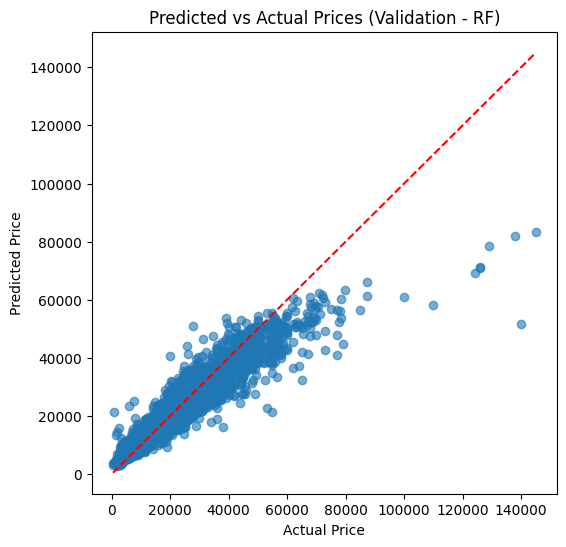

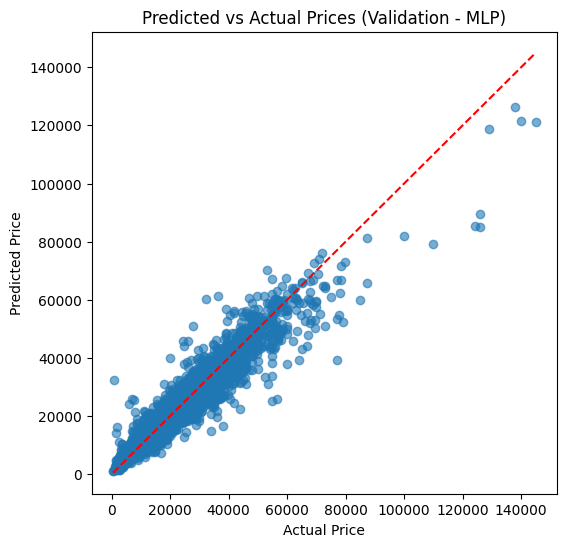

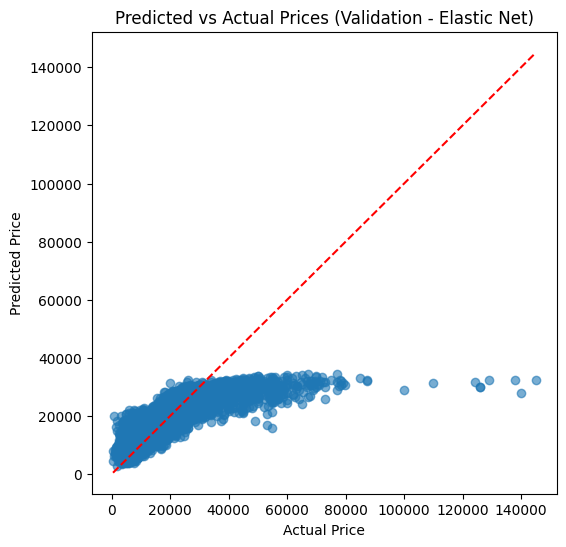

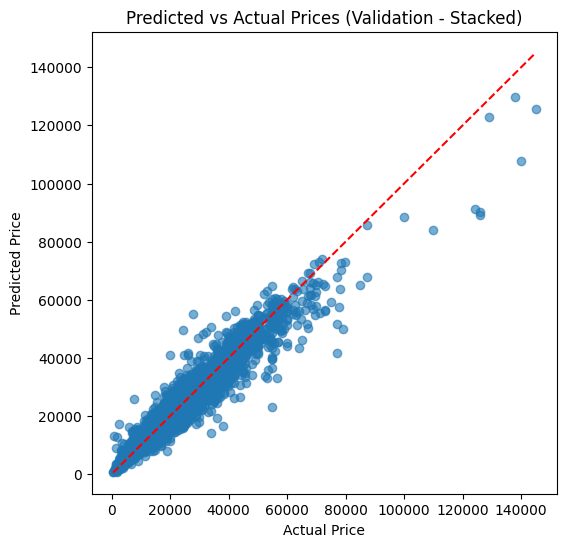

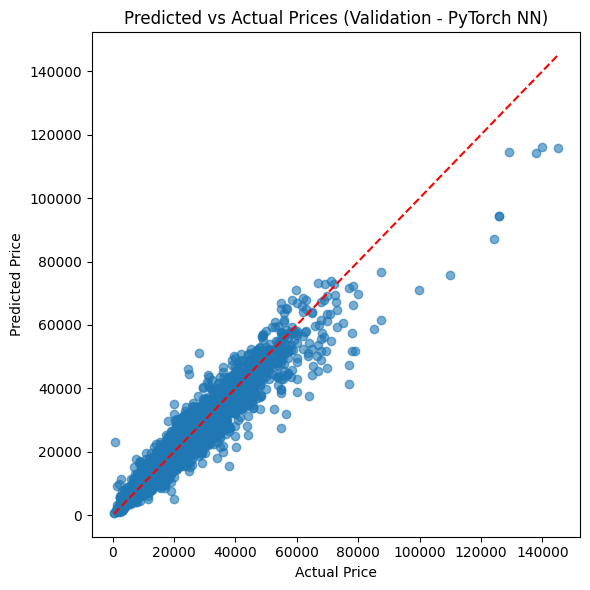

In [154]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, val_pred_rf, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Validation - RF)")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_val, val_pred_mlp, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Validation - MLP)")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_val, val_pred_elastic, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Validation - Elastic Net)")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_stacked, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Validation - Stacked)")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_preds_log, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Validation - PyTorch NN)")
plt.tight_layout()
plt.show()



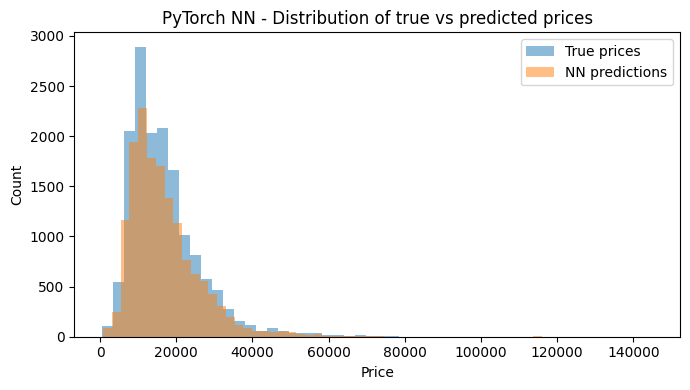

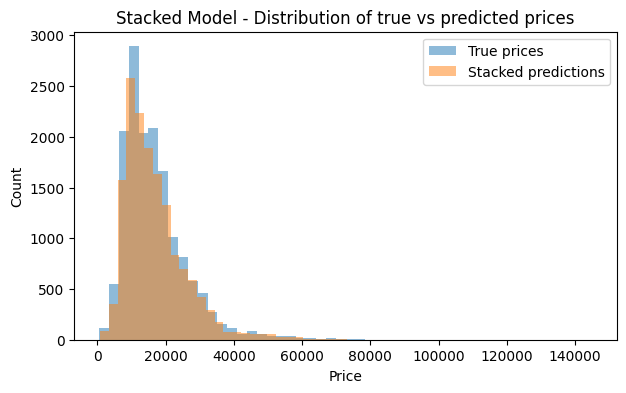

In [162]:
y_true = np.asarray(y_val).ravel()
y_pred_nn = np.asarray(val_preds_log).ravel() 

plt.figure(figsize=(7, 4))
plt.hist(y_true, bins=50, alpha=0.5, label="True prices")
plt.hist(y_pred_nn, bins=50, alpha=0.5, label="NN predictions")
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("PyTorch NN - Distribution of true vs predicted prices")
plt.legend()
plt.tight_layout()
plt.show()

# Stacked predictions distribution
y_pred_stack = np.asarray(y_pred_stacked).ravel()
plt.figure(figsize=(7, 4))
plt.hist(y_true, bins=50, alpha=0.5, label="True prices")
plt.hist(y_pred_stack, bins=50, alpha=0.5, label="Stacked predictions")
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Stacked Model - Distribution of true vs predicted prices")
plt.legend()


In [156]:
def plot_mae_by_category(name, X_val_raw, y_true, y_pred, cat_col, top_n=15, min_count=30):
    """
    X_val_raw: DataFrame with original columns (Brand, fuelType, etc.)
    cat_col  : column name to group by, e.g. 'Brand'
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        cat_col: X_val_raw[cat_col].values
    })
    df["abs_err"] = np.abs(df["y_true"] - df["y_pred"])

    grouped = df.groupby(cat_col).agg(
        mae=("abs_err", "mean"),
        count=("abs_err", "size")
    )

    grouped = grouped[grouped["count"] >= min_count]  # drop tiny groups
    grouped = grouped.sort_values("mae", ascending=False).head(top_n)

    plt.figure(figsize=(8, 5))
    grouped["mae"].sort_values().plot(kind="barh")
    plt.xlabel("MAE")
    plt.title(f"{name} – MAE by {cat_col} (min {min_count} cars, top {top_n})")
    plt.tight_layout()
    plt.show()

    return grouped



When analyzing closer some of the features used in prediction, we once again notice that MAE is higher for some of the conditions that were associated with the car being pricier as displayed in our multivariate analysis (newer cars, brands deemed premium, lower mileage). Both our top models have nearly identical results.

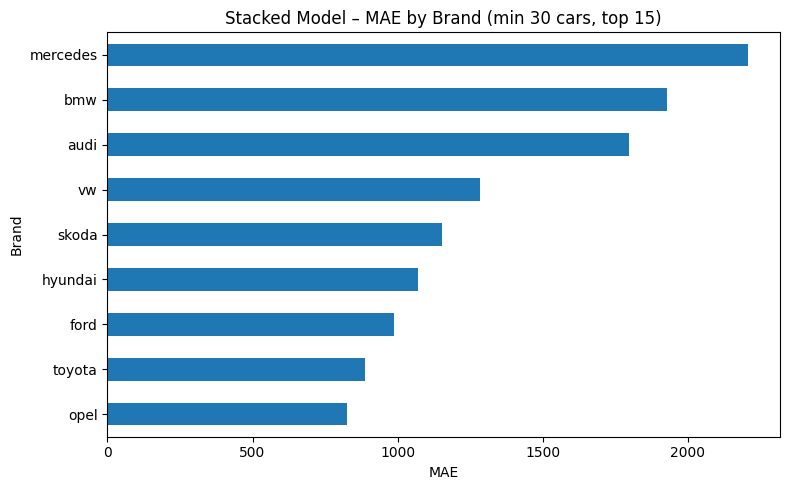

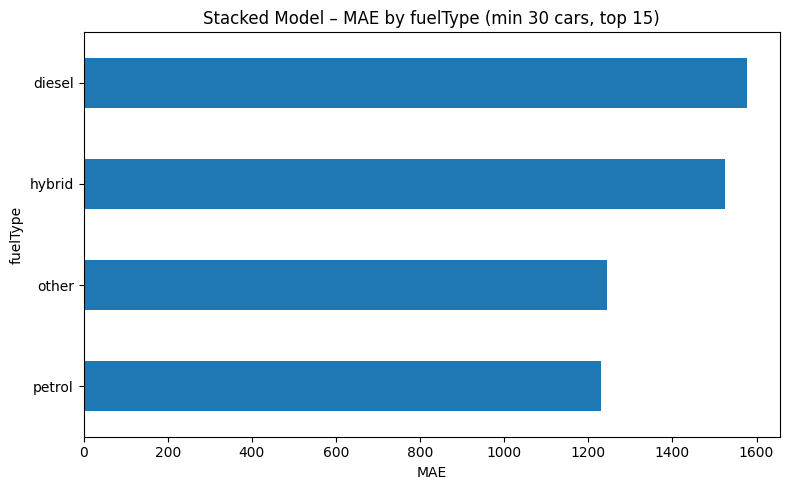

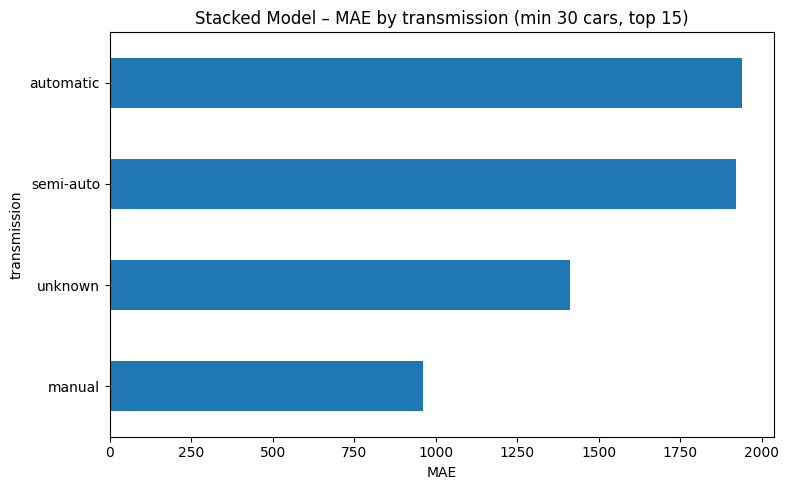

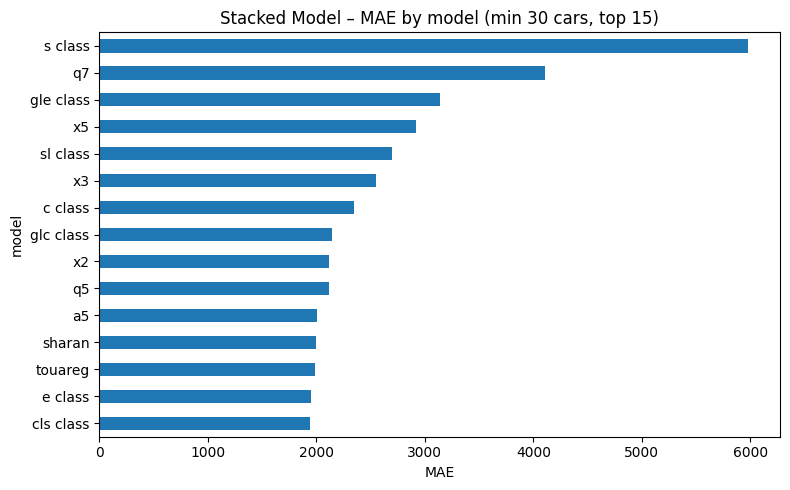

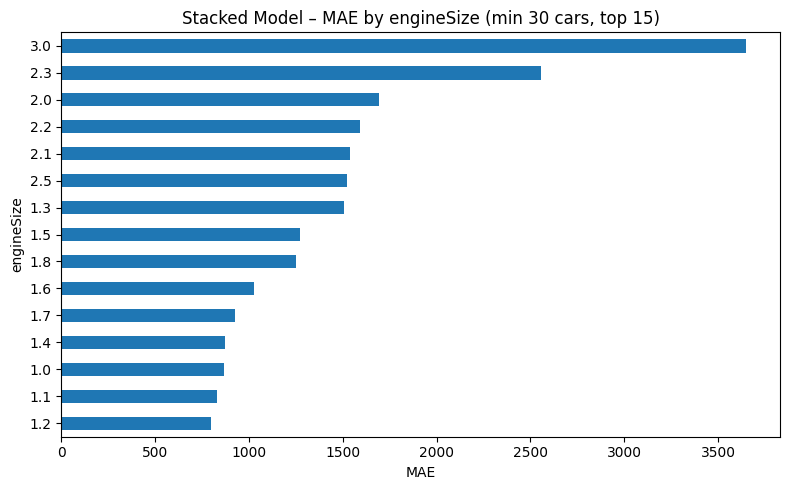

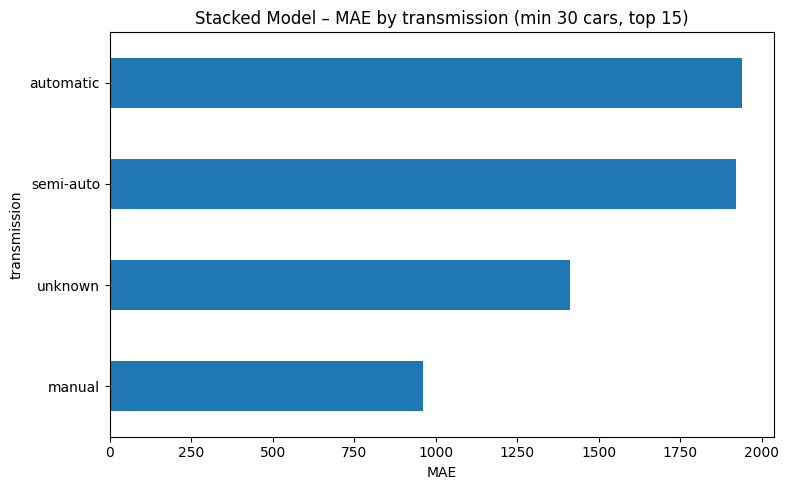

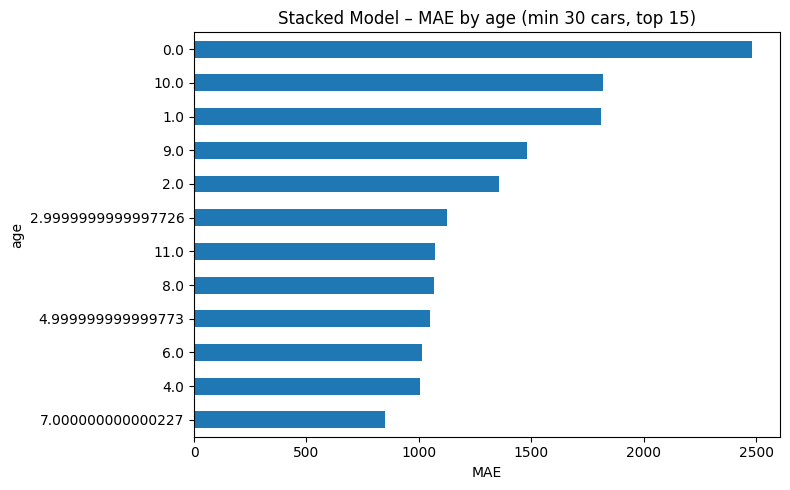

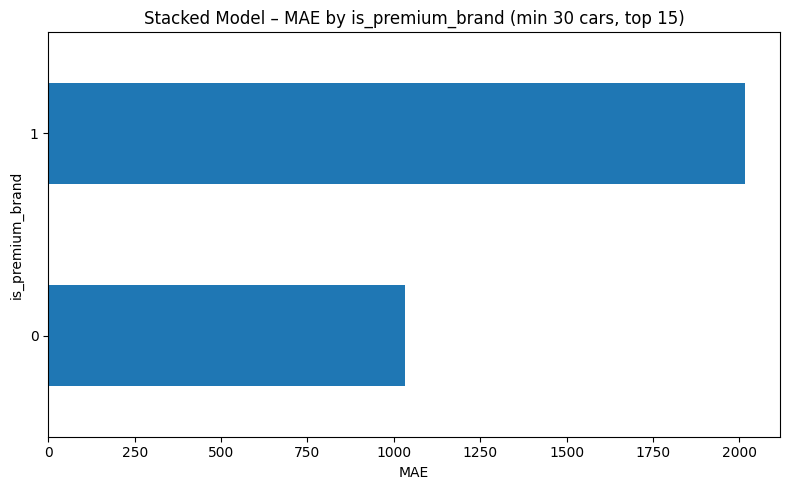

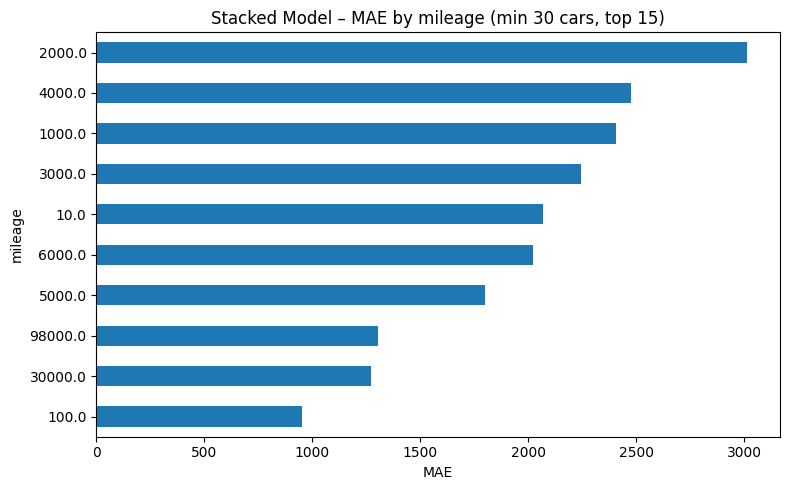

In [ ]:
# Plot MAE by various features for the Stacked model
for col in ["Brand", "fuelType", "transmission", "model", "engineSize", "transmission", "age", "is_premium_brand", "mileage"]:
    plot_mae_by_category(
        name="Stacked Model",
        X_val_raw=X_val,
        y_true=y_val,
        y_pred=y_pred_stacked,
        cat_col=col,
        top_n=15,
        min_count=30
    )

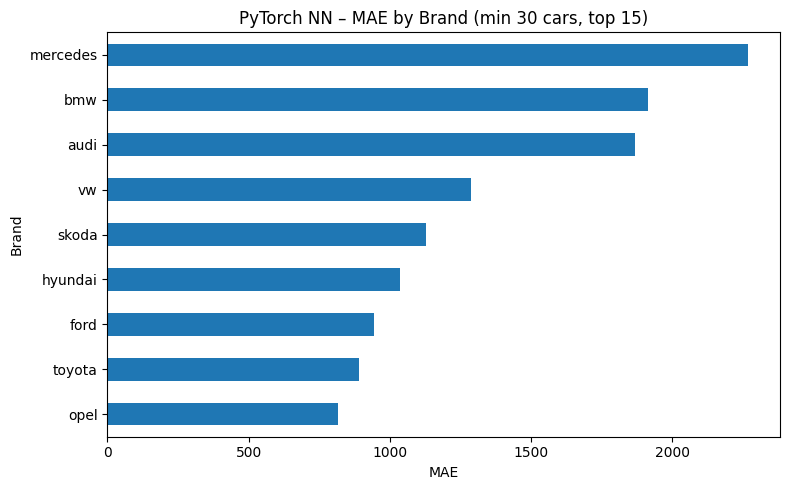

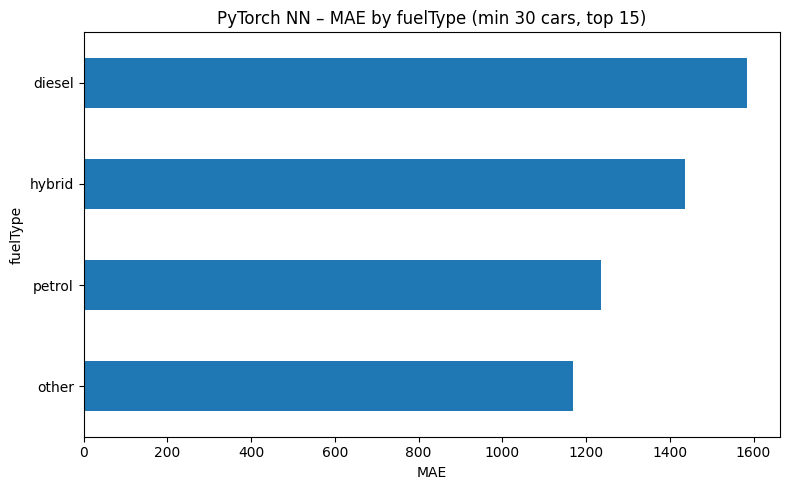

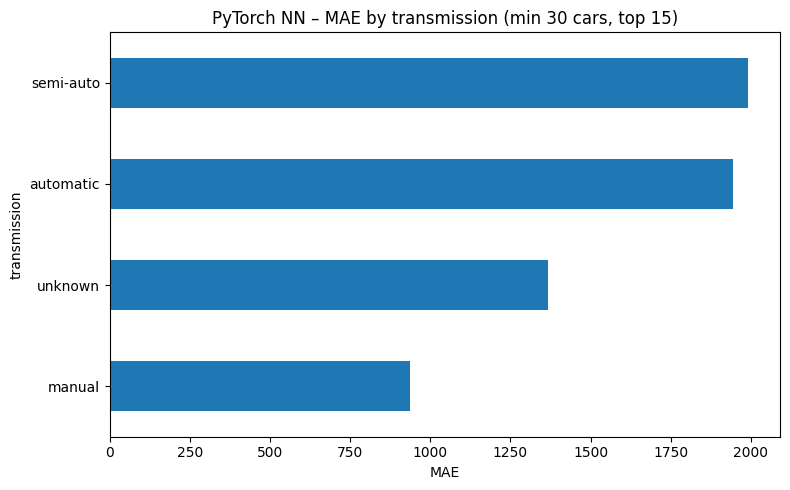

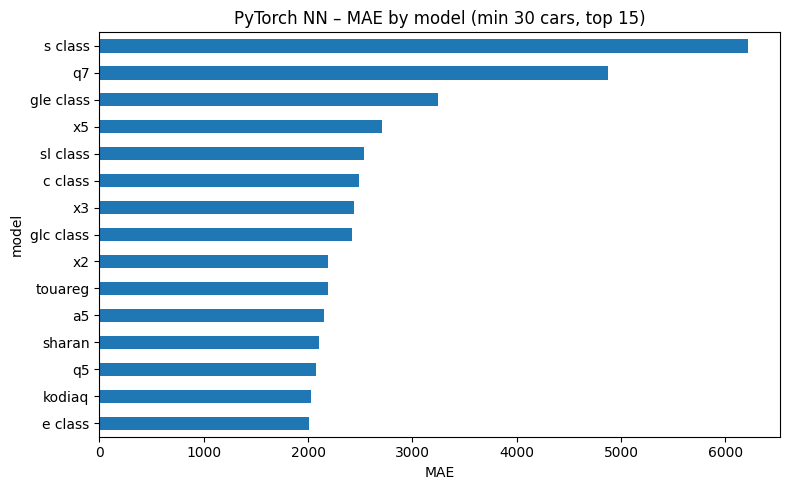

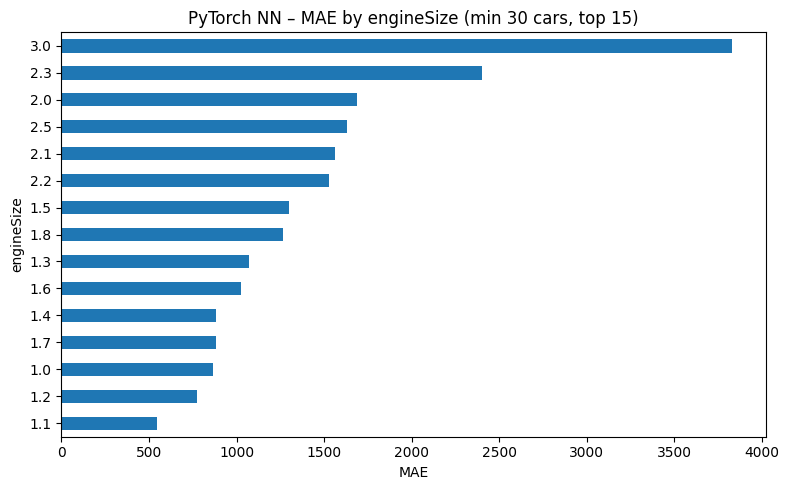

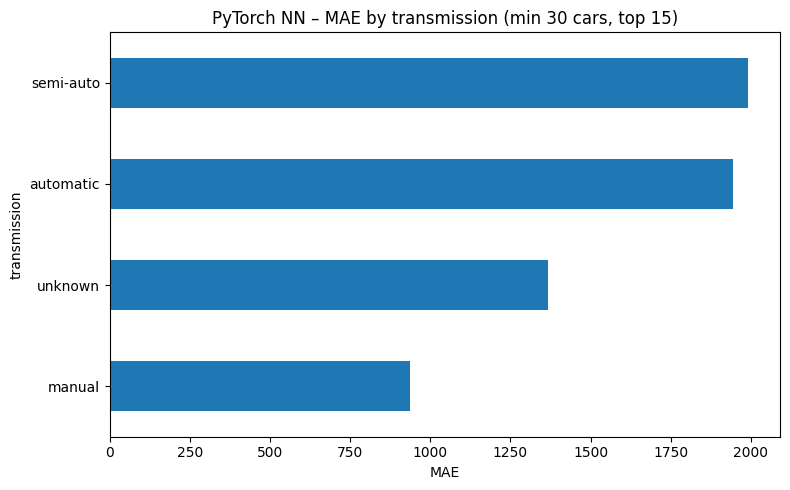

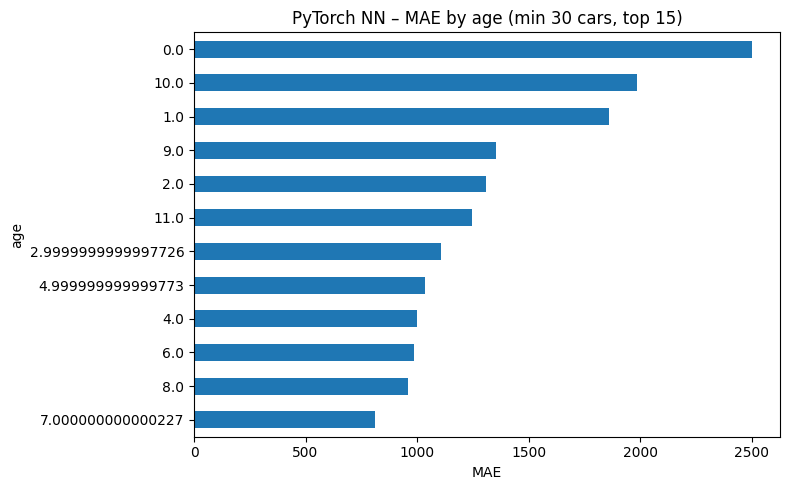

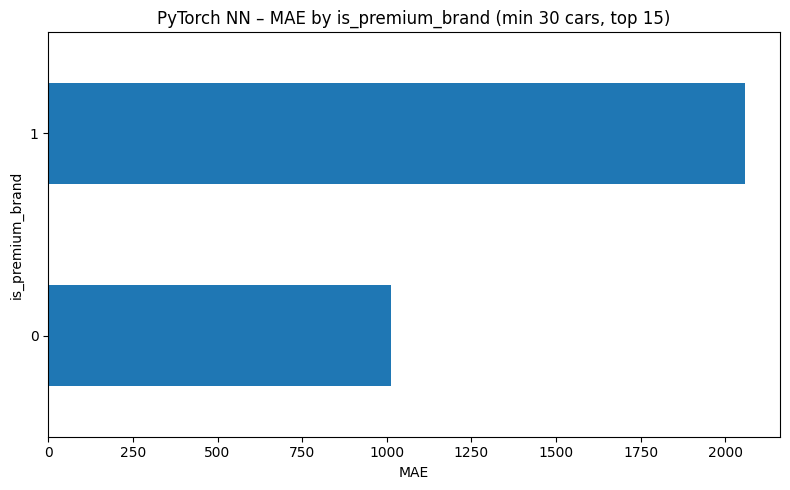

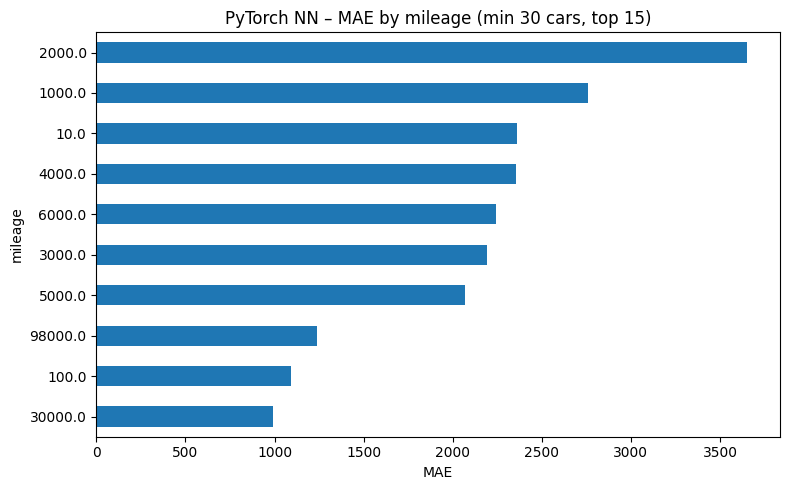

In [ ]:
# Plot MAE by various features for the PyTorch NN model
for col in ["Brand", "fuelType", "transmission", "model", "engineSize", "transmission", "age", "is_premium_brand", "mileage"]:
    _ = plot_mae_by_category(
        name="PyTorch NN",
        X_val_raw=X_val,
        y_true=y_val,
        y_pred=val_preds_log,
        cat_col=col,
        top_n=15,
        min_count=30
    )

In [159]:
def mae_by_price_bin(name, y_true, y_pred, n_bins=10):
    # Bin true prices into quantiles and compute MAE per bin
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["bin"] = pd.qcut(df["y_true"], q=n_bins, duplicates='drop')  # quantile bins

    mae_per_bin = df.groupby("bin").apply(
        lambda d: mean_absolute_error(d["y_true"], d["y_pred"])
    )

    plt.figure(figsize=(10,4))
    mae_per_bin.plot(kind="bar")
    plt.ylabel("MAE")
    plt.xlabel("True price quantile")
    plt.title(f"{name} - MAE by true price quantile")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

To finalize the analysis on pricing we binned the price with every model displaying a clear spike of MAE for the pricier bin

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df.groupby("bin").apply(
C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df.groupby("bin").apply(


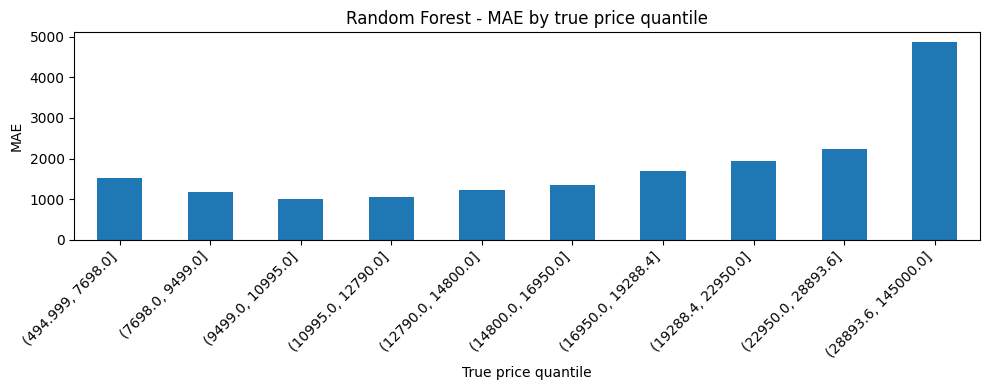

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df.groupby("bin").apply(
C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df.groupby("bin").apply(


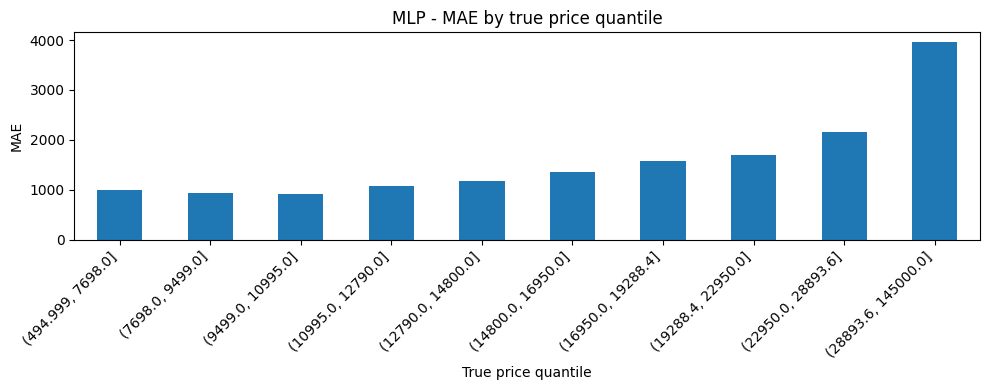

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df.groupby("bin").apply(
C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df.groupby("bin").apply(


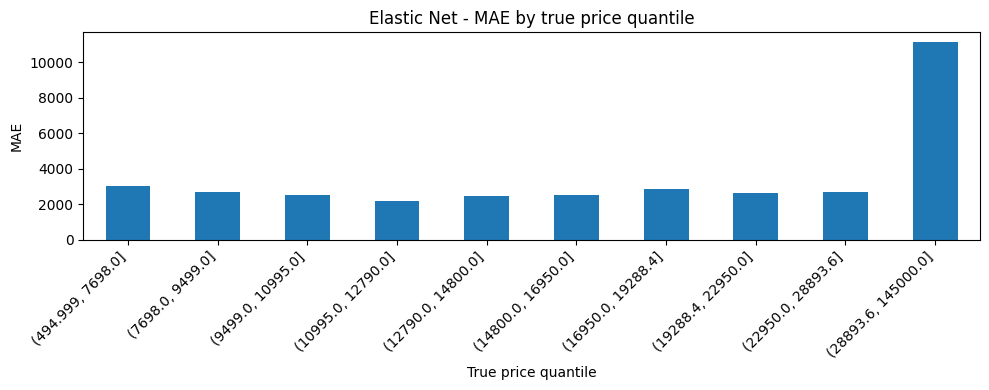

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df.groupby("bin").apply(
C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df.groupby("bin").apply(


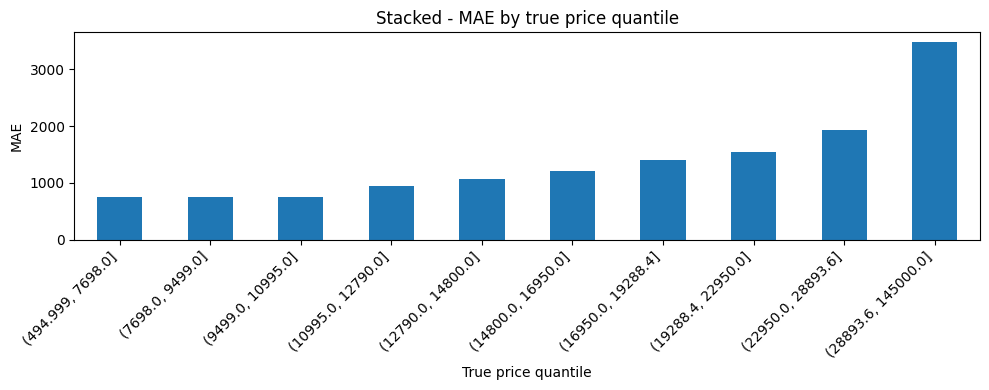

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df.groupby("bin").apply(
C:\Users\elton\AppData\Local\Temp\ipykernel_132964\2672182882.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df.groupby("bin").apply(


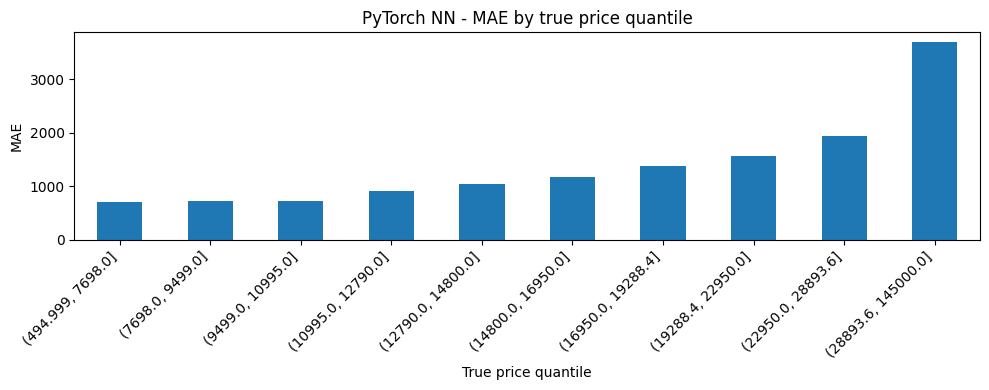

In [160]:
mae_by_price_bin("Random Forest", y_val, val_pred_rf, n_bins=10)
mae_by_price_bin("MLP", y_val, val_pred_mlp, n_bins=10)
mae_by_price_bin("Elastic Net", y_val, val_pred_elastic, n_bins=10)
mae_by_price_bin("Stacked", y_val, y_pred_stacked, n_bins=10)
mae_by_price_bin("PyTorch NN", y_val, val_preds_log, n_bins=10)

When focusing on PT NN's performance, we notice a clear learning trend for the first 100 epochs which than gave to a long stagnation where the model sporadically found a better solution but seemed to get stuck on local optima or hitting its ceiling in predicition capability. Training and validation MAE are almost perfectly aligned over the whole run, which seems to confirm that the network is not overfitting but rather hitting its capacity or an optimization plateau. RMSE and R² show the same behaviour: quick improvement in the early epochs and then saturation, with train and validation curves tracking each other closely

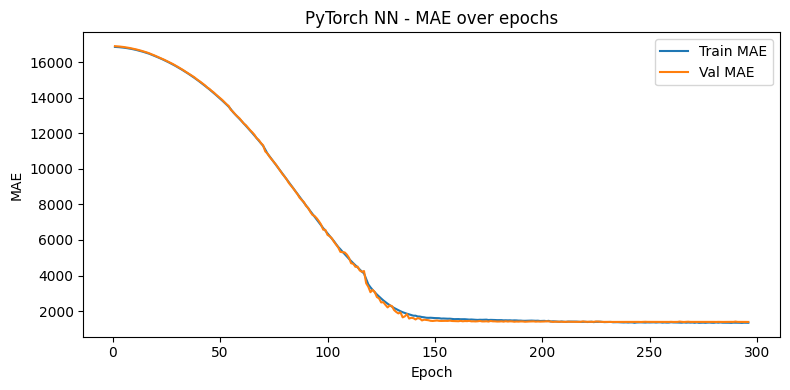

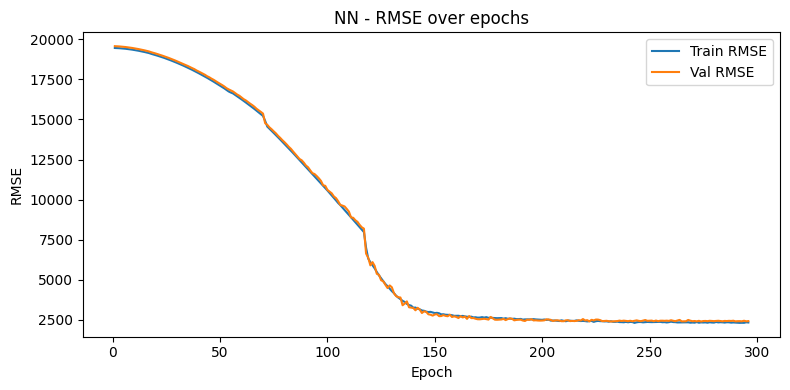

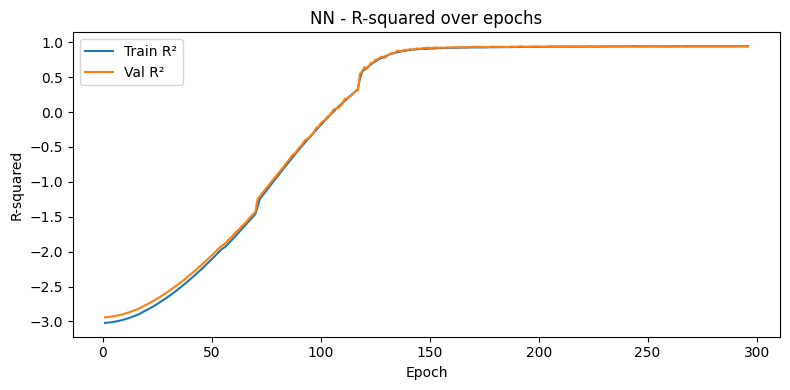

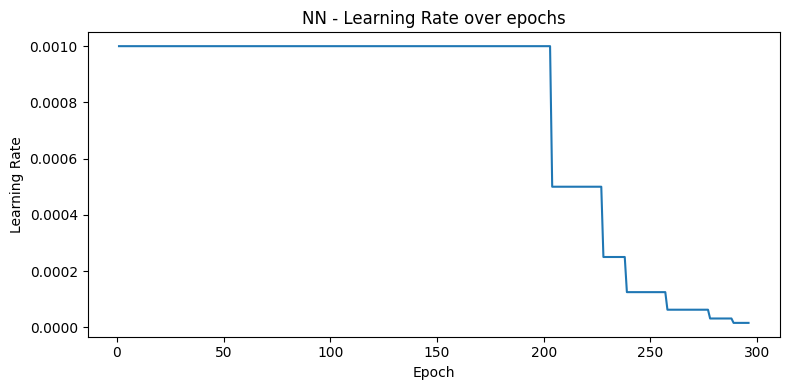

In [166]:
epochs = range(1, len(history["train_mae"]) + 1)

# Plot training and validation MAE over epochs (learning curves) - PyTorch NN
plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_mae"], label="Train MAE")
plt.plot(epochs, history["val_mae"],   label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("PyTorch NN - MAE over epochs")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_rmse"], label="Train RMSE")
plt.plot(epochs, history["val_rmse"],   label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("NN - RMSE over epochs")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_r2"], label="Train R²")
plt.plot(epochs, history["val_r2"],   label="Val R²")
plt.xlabel("Epoch")
plt.ylabel("R-squared")
plt.title("NN - R-squared over epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Plot learning rate schedule
plt.figure(figsize=(8,4))
plt.plot(epochs, history["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("NN - Learning Rate over epochs")
plt.tight_layout()
plt.show()


To understand how the stacked model behaves compared to the best single model (Random Forest), we looked at the per-car difference in absolute error. The stacked ensemble improves predictions for about ~63% of the validation cars, with an reduction of about 423.1£ in MAE per vehicle. The distribution is skewed: most gains are small but positive, while there is a long left tail where stacking occasionally makes larger mistakes. This confirms that stacking is slightly better overall but not uniformly better for every car.

When comparing PT NN and Stacked we confirm the slight advantage of Stacked as it performs better in just above 50% of the cases but by just 2£ in MAE reduction. It is nearly a tie.

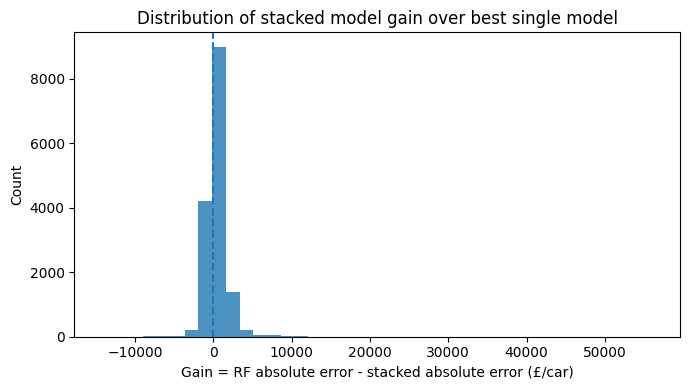

Stacked is better than RF base model on  62.9% of cars
Average gain per car:   423.1 £
Median gain per car:    254.9 £


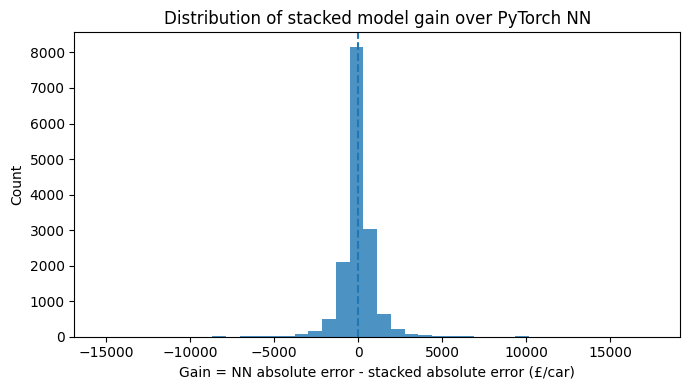

Stacked is better than PyTorch NN on  50.2% of cars
Average gain per car:     2.3 £
Median gain per car:      1.7 £


In [181]:
err_rf = np.abs(y_val - val_pred_rf)
err_stacked = np.abs(y_val - y_pred_stacked)

gain = err_rf - err_stacked

plt.figure(figsize=(7,4))
plt.hist(gain, bins=40, alpha=0.8)
plt.axvline(0, linestyle="--")
plt.xlabel("Gain = RF absolute error - stacked absolute error (£/car)")
plt.ylabel("Count")
plt.title("Distribution of stacked model gain over best single model")
plt.tight_layout()
plt.show()

win_rate = (gain > 0).mean()
avg_gain = gain.mean()
median_gain = np.median(gain)

print(f"Stacked is better than RF base model on {win_rate*100:5.1f}% of cars")
print(f"Average gain per car:{avg_gain:8.1f} £")
print(f"Median gain per car: {median_gain:8.1f} £")


err_pt_nn = np.abs(y_val - val_preds_log)
gain_nn = err_pt_nn - err_stacked

plt.figure(figsize=(7,4))
plt.hist(gain_nn, bins=40, alpha=0.8)
plt.axvline(0, linestyle="--")
plt.xlabel("Gain = NN absolute error - stacked absolute error (£/car)")
plt.ylabel("Count")
plt.title("Distribution of stacked model gain over PyTorch NN")
plt.tight_layout()
plt.show()

win_rate_nn = (gain_nn > 0).mean()
avg_gain_nn = gain_nn.mean()
median_gain_nn = np.median(gain_nn)
print(f"Stacked is better than PyTorch NN on {win_rate_nn*100:5.1f}% of cars")
print(f"Average gain per car:{avg_gain_nn:8.1f} £")
print(f"Median gain per car: {median_gain_nn:8.1f} £")


When looking at price per range, Stacked here shows an interesting advantage as it is more robust in the most difficult cases, which are the most expensive cars. In most cases NN is a better model but by slim margins, the oonly considerable margin is at the top where Stacked is much more robust.

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\4267200556.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df_bins.groupby("bin").apply(
C:\Users\elton\AppData\Local\Temp\ipykernel_132964\4267200556.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df_bins.groupby("bin").apply(


<Figure size 1000x400 with 0 Axes>

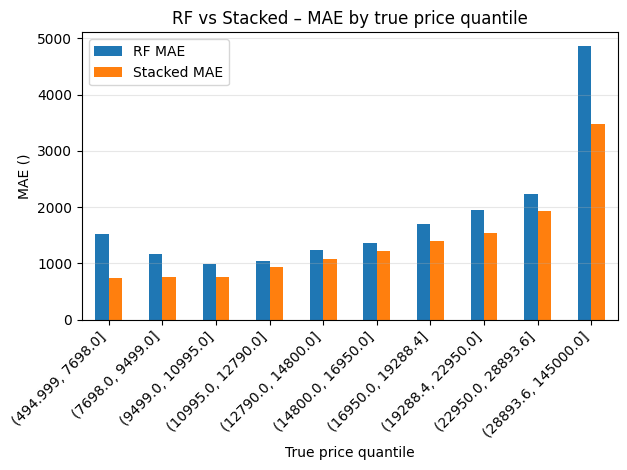

C:\Users\elton\AppData\Local\Temp\ipykernel_132964\4267200556.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df_bins.groupby("bin").apply(


Stacked MAE improvement by price bin (RF MAE - Stacked MAE):
(494.999, 7698.0]:  770.1 €
(7698.0, 9499.0]:  417.6 €
(9499.0, 10995.0]:  234.4 €
(10995.0, 12790.0]:  101.4 €
(12790.0, 14800.0]:  165.3 €
(14800.0, 16950.0]:  144.5 €
(16950.0, 19288.4]:  296.0 €
(19288.4, 22950.0]:  404.9 €
(22950.0, 28893.6]:  308.0 €
(28893.6, 145000.0]: 1386.2 €


C:\Users\elton\AppData\Local\Temp\ipykernel_132964\4267200556.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bin = df_bins.groupby("bin").apply(


<Figure size 1000x400 with 0 Axes>

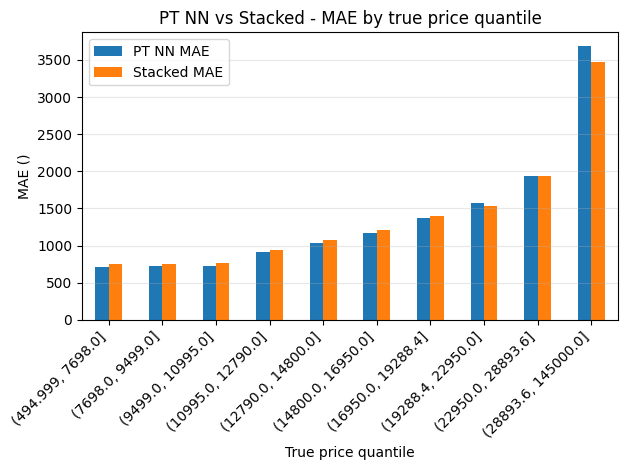

Stacked MAE improvement by price bin (PT NN MAE - Stacked MAE):
(494.999, 7698.0]:  -40.6 €
(7698.0, 9499.0]:  -20.4 €
(9499.0, 10995.0]:  -33.7 €
(10995.0, 12790.0]:  -27.7 €
(12790.0, 14800.0]:  -29.8 €
(14800.0, 16950.0]:  -50.2 €
(16950.0, 19288.4]:  -28.0 €
(19288.4, 22950.0]:   36.4 €
(22950.0, 28893.6]:    3.6 €
(28893.6, 145000.0]:  213.5 €


In [178]:
n_bins = 10 

# Create DataFrame with true prices and predictions
df_bins = pd.DataFrame({
    "y_true":   y_val,
    "rf_pred":  val_pred_rf,
    "stk_pred": y_pred_stacked,
    "pt_nn_pred":  val_preds_log,
})

# Create quantile bins based on true prices
df_bins["bin"] = pd.qcut(df_bins["y_true"], q=n_bins, duplicates="drop")

# Compute MAE per bin for each model
mae_per_bin = df_bins.groupby("bin").apply(
    lambda d: pd.Series({
        "RF MAE": mean_absolute_error(d["y_true"], d["rf_pred"]),
        "Stacked MAE":  mean_absolute_error(d["y_true"], d["stk_pred"]),
    })
)

# Plot: MAE by price bin, RF vs Stacked
plt.figure(figsize=(10, 4))
mae_per_bin[["RF MAE", "Stacked MAE"]].plot(kind="bar")
plt.ylabel("MAE ()")
plt.xlabel("True price quantile")
plt.title("RF vs Stacked – MAE by true price quantile")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Compute and print gain per bin
gain_bin = mae_per_bin["RF MAE"] - mae_per_bin["Stacked MAE"]
print("Stacked MAE improvement by price bin (RF MAE - Stacked MAE):")
for b, g in gain_bin.items():
    print(f"{b}: {g:6.1f} €")


# Compute MAE per bin for each model
mae_per_bin = df_bins.groupby("bin").apply(
    lambda d: pd.Series({
        "PT NN MAE": mean_absolute_error(d["y_true"], d["pt_nn_pred"]),
        "Stacked MAE":  mean_absolute_error(d["y_true"], d["stk_pred"]),
    })
)

# Plot: MAE by price bin, PT NN vs Stacked
plt.figure(figsize=(10, 4))
mae_per_bin[["PT NN MAE", "Stacked MAE"]].plot(kind="bar")
plt.ylabel("MAE ()")
plt.xlabel("True price quantile")
plt.title("PT NN vs Stacked - MAE by true price quantile")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Compute and print gain per bin
gain_bin = mae_per_bin["PT NN MAE"] - mae_per_bin["Stacked MAE"]
print("Stacked MAE improvement by price bin (PT NN MAE - Stacked MAE):")
for b, g in gain_bin.items():
    print(f"{b}: {g:6.1f} €")



# Ablation Study - Final Test
For the ablation study we re-trained the same Stacked and PyTorch NN (same architecture, optimizer, learning-rate schedule, batch size and number of epochs) but using the full set of encoded features, instead of the feature-selected subset used in the main experiments.

The goal is to isolate the effect of the feature–selection process: by keeping everything else fixed and only changing the input feature space, any difference in validation performance can be attributed to the presence/absence of feature selection rather than to the network design or training procedure. 

In [ ]:
# Ablation study: Stacked on all features without feature selection
stacked.fit(X_train_original, y_train)

y_val_pred_ablation = stacked.predict(X_val_original)
mae_val_ablation = mean_absolute_error(y_val, y_val_pred_ablation)
rmse_val_ablation = np.sqrt(mean_squared_error(y_val, y_val_pred_ablation))
r2_val_ablation = r2_score(y_val, y_val_pred_ablation)

print(f"Stacked model MAE with selected features: {mae_val_stacked:.2f}, RMSE: {rmse_val_stacked:.2f}, R-squared: {r2_val_stacked:.4f}")
print(f"Stacked model MAE with all features: {mae_val_ablation:.2f}, RMSE: {rmse_val_ablation:.2f}, R-squared: {r2_val_ablation:.4f}")

Stacked model MAE with selected features: 1382.68, RMSE: 2331.18, R-squared: 0.9441
Stacked model MAE with all features: 1325.21, RMSE: 2247.45, R-squared: 0.9480


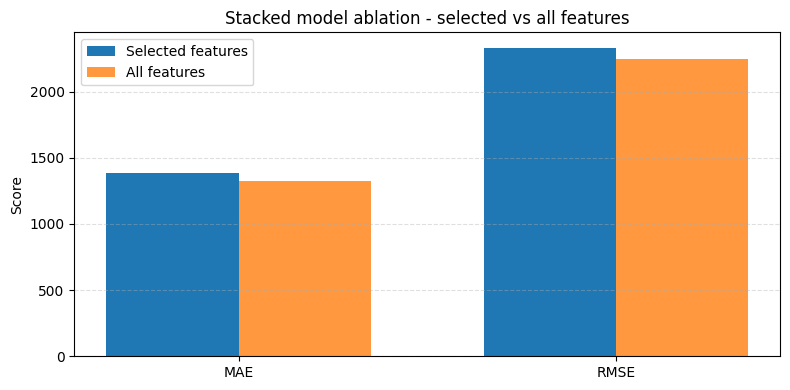

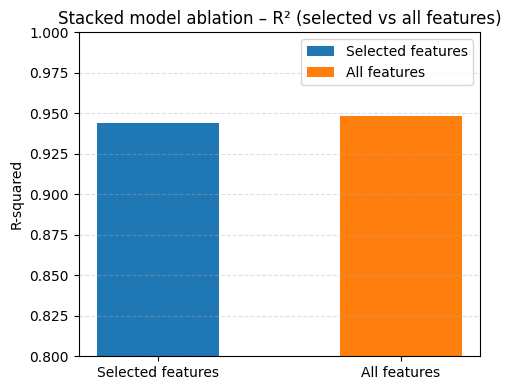

In [193]:
metrics = ["MAE", "RMSE"]

selected_feats = [mae_val_stacked,  rmse_val_stacked]
all_feats = [mae_val_ablation, rmse_val_ablation]

x = np.arange(len(metrics))
width = 0.35

# MAE and RMSE comparison
plt.figure(figsize=(8, 4))
plt.bar(x - width/2, selected_feats, width, label="Selected features")
plt.bar(x + width/2, all_feats, width, label="All features", alpha=0.8)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Stacked model ablation - selected vs all features")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# R-squared comparison
labels = ["Selected features", "All features"]
x = np.arange(len(labels))
width = 0.5

plt.figure(figsize=(5, 4))
plt.bar(x[0], r2_val_stacked, width,
        label="Selected features", color="tab:blue")
plt.bar(x[1], r2_val_ablation, width,
        label="All features",      color="tab:orange")

plt.xticks(x, labels)
plt.ylabel("R-squared")
plt.ylim(0.80, 1.00)
plt.title("Stacked model ablation – R² (selected vs all features)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



In [ ]:
# Ablation: PT NN on all features without feature selection

# Full feature set (no feature-selection)
X_train_all = X_train_original.copy()
X_val_all = X_val_original.copy()
X_test_all = x_test_original.copy()

X_train_nn_all = pd.DataFrame(X_train_all, index=X_train_all.index, columns=X_train_all.columns)
X_val_nn_all = pd.DataFrame(X_val_all,index=X_val_all.index,columns=X_val_all.columns)
X_test_nn_all = pd.DataFrame(X_test_all, index=X_test_all.index, columns=X_test_all.columns)

# Datasets
train_dataset_all = CarPriceDataset(X_train_nn_all, y_train)
val_dataset_all = CarPriceDataset(X_val_nn_all,y_val)
test_dataset_all = CarPriceDataset(X_test_nn_all,  None)

# DataLoaders
train_loader_all = DataLoader(train_dataset_all, batch_size=batch_size, shuffle=True)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
val_loader_all = DataLoader(val_dataset_all,batch_size=batch_size, shuffle=False)
test_loader_all = DataLoader(test_dataset_all, batch_size=batch_size, shuffle=False)

# Instantiate model
input_dim_all = X_train_all.shape[1]
model_pt_all = CarPriceNN(input_dim_all).to(device)
print(model_pt_all)


CarPriceNN(
  (net): Sequential(
    (0): Linear(in_features=231, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_fe

In [184]:
optimizer = torch.optim.AdamW(model_pt_all.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=patience, min_lr=1e-6)

In [185]:
# Full training loop
best_val_mae_all = np.inf
best_state_dict_all = None
epochs_no_improve_all = 0

history_all = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": [],
    "train_rmse": [],
    "val_rmse": [],
    "train_r2": [],
    "val_r2": [],
    "lr": []
}

for epoch in range(1, n_epochs + 1):
    train_loss_all, train_mae_all, train_rmse_all, train_r2_all = run_epoch(model_pt_all, train_loader_all, train=True)
    val_loss_all, val_mae_all, val_rmse_all, val_r2_all = run_epoch(model_pt_all, val_loader_all, train=False)

    # Record history of the metrics for each epoch
    history_all["train_loss"].append(train_loss_all)
    history_all["val_loss"].append(val_loss_all)
    history_all["train_mae"].append(train_mae_all)
    history_all["val_mae"].append(val_mae_all)
    history_all["train_rmse"].append(train_rmse_all)
    history_all["val_rmse"].append(val_rmse_all)
    history_all["train_r2"].append(train_r2_all)
    history_all["val_r2"].append(val_r2_all)
    current_lr_all = optimizer.param_groups[0]["lr"]
    history_all["lr"].append(current_lr_all)

    # Step LR scheduler on validation MAE
    scheduler.step(val_mae_all)

    print(
        f"Epoch {epoch:03d} | "
        f"Train MAE: {train_mae_all:7.2f} | Val MAE: {val_mae_all:7.2f} | "
        f"Train RMSE: {train_rmse_all:7.2f} | Val RMSE: {val_rmse_all:7.2f} | "
        f"Train R²: {train_r2_all:6.3f} | Val R²: {val_r2_all:6.3f} | "
        f"Train Loss: {train_loss_all:7.2f} | Val Loss: {val_loss_all:7.2f} | "
        f"LR: {current_lr_all:.2e}"
    )
    
    # Early stopping based on best validation MAE
    if val_mae_all < best_val_mae_all:
        best_val_mae_all = val_mae_all
        best_state_dict_all = copy.deepcopy(model_pt_all.state_dict())
        epochs_no_improve_all = 0
    else:
        epochs_no_improve_all += 1
        if epochs_no_improve_all >= patience:
            print(f"Early stopping after {epoch} epochs.")
            break

# Load best weights
if best_state_dict_all is not None:
    model_pt_all.load_state_dict(best_state_dict_all)
print("Best validation MAE (all features):", best_val_mae_all)

Epoch 001 | Train MAE: 16869.84 | Val MAE: 16911.59 | Train RMSE: 19462.51 | Val RMSE: 19575.90 | Train R²: -3.021 | Val R²: -2.942 | Train Loss: 16369.85 | Val Loss: 16411.60 | LR: 1.00e-03
Epoch 002 | Train MAE: 16863.84 | Val MAE: 16903.59 | Train RMSE: 19457.43 | Val RMSE: 19569.18 | Train R²: -3.019 | Val R²: -2.939 | Train Loss: 16363.85 | Val Loss: 16403.61 | LR: 1.00e-03
Epoch 003 | Train MAE: 16854.23 | Val MAE: 16892.75 | Train RMSE: 19449.32 | Val RMSE: 19560.11 | Train R²: -3.016 | Val R²: -2.936 | Train Loss: 16354.24 | Val Loss: 16392.77 | LR: 1.00e-03
Epoch 004 | Train MAE: 16842.17 | Val MAE: 16879.40 | Train RMSE: 19439.18 | Val RMSE: 19548.99 | Train R²: -3.012 | Val R²: -2.931 | Train Loss: 16342.19 | Val Loss: 16379.42 | LR: 1.00e-03
Epoch 005 | Train MAE: 16827.82 | Val MAE: 16863.96 | Train RMSE: 19427.18 | Val RMSE: 19536.04 | Train R²: -3.007 | Val R²: -2.926 | Train Loss: 16327.84 | Val Loss: 16363.98 | LR: 1.00e-03
Epoch 006 | Train MAE: 16811.31 | Val MAE: 16

In [186]:
# Evaluate on validation set 
model_pt_all.eval()
val_preds_log_all = []

with torch.no_grad():
    for X_batch, _ in val_loader_all:
        X_batch = X_batch.to(device)
        preds = model_pt_all(X_batch)
        val_preds_log_all.append(preds.cpu().numpy())
    
val_preds_log_all = np.concatenate(val_preds_log_all, axis=0)
mae_price_all = mean_absolute_error(y_val, val_preds_log_all)
rmse_price_all = np.sqrt(mean_squared_error(y_val, val_preds_log_all))
r2_price_all = r2_score(y_val, val_preds_log_all)

print(f"Validation MAE (all features): {mae_price_all:,.2f}")
print(f"Validation RMSE (all features): {rmse_price_all:,.2f}")
print(f"Validation R-squared (all features): {r2_price_all:.4f}")

Validation MAE (all features): 1,377.23
Validation RMSE (all features): 2,406.05
Validation R-squared (all features): 0.9404


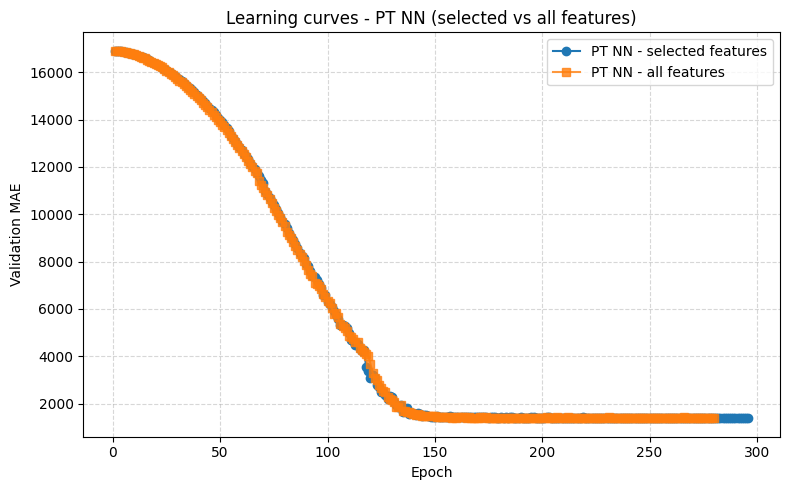

In [188]:
# Epoch indices for each run
epochs_main = np.arange(1, len(history["val_mae"]) + 1)
epochs_all = np.arange(1, len(history_all["val_mae"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_main, history["val_mae"],
         marker="o", linewidth=1.5, label="PT NN - selected features")
plt.plot(epochs_all, history_all["val_mae"],
         marker="s", linewidth=1.5, label="PT NN - all features", alpha=0.8)

plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.title("Learning curves - PT NN (selected vs all features)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [189]:
# Compare with feature-selected model
print(f"Validation MAE (selected features): {mae_price:,.2f}, RMSE (selected features): {np.sqrt(mean_squared_error(y_val, val_preds_log)):,.2f}, R-squared (selected features): {r2_price:.4f}")
print(f"Validation MAE (all features): {mae_price_all:,.2f}, RMSE (all features): {np.sqrt(mean_squared_error(y_val, val_preds_log_all)):,.2f}, R-squared (all features): {r2_price_all:.4f}")

Validation MAE (selected features): 1,385.01, RMSE (selected features): 2,405.57, R-squared (selected features): 0.9405
Validation MAE (all features): 1,377.23, RMSE (all features): 2,406.05, R-squared (all features): 0.9404


After ablation, Stacked got better results by a bigger margin than PT NN. Given a more noticeable difference now and also Stacked's superior robustness in the most difficult scenarios we shall proceed with Stack and the full dataset. Although there was a significant increase in dimensionality compared to the feature selected dataaset that wasn't accompanied by a matching increase in performance, the computational costs are still manageable so that we can still maintain this approach.

# Test Prediction

In [194]:
X_train_full = pd.concat([X_train_original, X_val_original])
y_train_full = pd.concat([y_train, y_val])

In [195]:
# Train final model on full training data
final_model = stacked 
final_model.fit(X_train_full, y_train_full)

,estimators,"[('rf', ...), ('mlp', ...), ...]"
,final_estimator,Ridge()
,cv,None
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [196]:
# Predict test set for submission
y_test_pred = final_model.predict(x_test_original)

# Deployment

In [197]:
# Build submission file
submission = pd.DataFrame({
    "carID": x_test_original.index,
    "price": y_test_pred
})

submission.to_csv("submission.csv", index=False)
print("Submission.csv saved.")

Submission.csv saved.


## Final Notes
1. **Insights**

    - The stacked ensemble (RF + MLP + Elastic Net with LR meta-model) is the best overall model on the validation set.

    - In the ablation study for stacking, using all original features gives better metrics than using only the selected subset: MAE drops from ~1383 to about ~1325. RMSE and R² improve slightly as well.

    - For the PyTorch NN, the version trained on the selected features performs almost as well as the all-feature version, while being cheaper to train.

    - All models show higher errors on the most expensive price bin, confirming that high-priced cars are hardest to predict.

    - The stacked model beats the best single model on ~63% of cars, with an mean absolute error reduction of ~423£ per car.

2. **Notable Relationships**

    - Price and error: MAE by price quantile rises sharply in the top decile for every model.

    - Usage and engine features (age, mileage, mileage per year, engine size, engine efficiency) repeatedly appear as important in tree importances and Lasso.

    - Mileage and price have an inverse relationship (lower mileage equates bigger price). Same with age and price.

3. **Hypotheses**

    - H1 – Feature selection will always help performance. 
    Refuted. Both top models performed better on the complete set including engineered features albeit not by much.

    - H2 – Non-linear models outperform linear ones. 
    Supported. RF, MLP, and the stacked ensemble clearly beat Elastic Net alone.

    - H3 – Stacking improves over any single model. 
    Supported. The ensemble has lower MAE/RMSE and slightly higher R-squared than the best individual base learner.

    - H4 – Expensive cars are hardest to price.
    Supported. MAE by price bin clearly spikes in the most expensive quantile across models.

4. **Actionables**

    - Model choice

        - Use the stacked model with all features as the production model, since it’s the best performer in the ablation study.
        - Keep the selected-feature pipeline as a secondary configuration: useful when training cost or latency is constrained, easier to interpret and explain, but slightly weaker for stacking.

    - Monitoring & future work

        - Track MAE per price bin in production; consider special handling or additional features for the high-price segment where errors are largest.
        - Explore lightweight tuning of the stacked ensemble (small manual grids rather than huge RandomizedSearchCV) due to full hyperparameter search being too slow.

    - Business

        - Communicate that the model is on average ~423 £ more accurate per car than the best single algorithm, and especially valuable on difficult cases where models fail the most.
        - Use the importance of age, mileage, brand, and engine-related variables to enforce those fields in the listing form, and generate simple explanations of the predicted price for users.